In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

#set your path
# s2p_dir = Path("/Users/suthardr/Desktop/plane0/")

# s2p_dir = Path("/Volumes/rkc_ramirezlab/Home/suthardr/Projects/2photon_menace/Astro2P_Pilot#5_2025Oct/PreProcess/jrgeco/10072025/932L/suite2p/plane0/")

#astrocyte 621N
s2p_dir = Path("/Users/suthardr/Desktop/621N_FC/suite2p_red/plane0/")

# #neuron 621N_
# s2p_dir_red = Path("/Users/suthardr/Desktop/621N_FC/suite2p_red/plane0/")

#load ya data
F      = np.load(s2p_dir / "F.npy")    #raw fluorescence (cells, indices)
Fneu   = np.load(s2p_dir / "Fneu.npy")       #neuropil (cells, indices)
iscell = np.load(s2p_dir / "iscell.npy", allow_pickle=True)
ops    = np.load(s2p_dir / "ops.npy", allow_pickle=True).item()

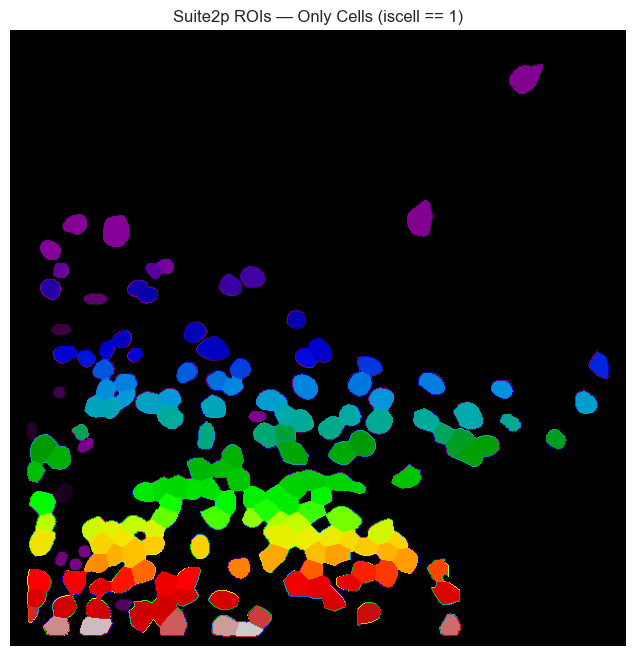

In [2]:
#plot mask
import numpy as np
import matplotlib.pyplot as plt

# Load Suite2p outputs
stat = np.load(s2p_dir / 'stat.npy', allow_pickle=True)

# Create cell mask (iscell is defined as Cell in Suite2p)
cell_mask = iscell[:, 0].astype(bool)

# Initialize blank image
im = np.zeros((ops['Ly'], ops['Lx']))

# Loop through only "cell" ROIs
cell_indices = np.where(cell_mask)[0]
for i, n in enumerate(cell_indices):
    ypix = stat[n]['ypix'][~stat[n]['overlap']]
    xpix = stat[n]['xpix'][~stat[n]['overlap']]
    im[ypix, xpix] = i + 1  # label each ROI
plt.figure(figsize=(8, 8))
plt.imshow(im, cmap='nipy_spectral')
plt.title('Suite2p ROIs — Only Cells (iscell == 1)')
plt.axis('off')
plt.show()

In [3]:
# Create a boolean mask for true cells
cell_mask = iscell[:, 0].astype(bool)

# Filter data
F_cells = F[cell_mask, :]
Fneu_cells = Fneu[cell_mask, :]

print(f"Original ROIs: {F.shape[0]}, Filtered cells: {F_cells.shape[0]}")

Original ROIs: 174, Filtered cells: 166


In [4]:
#correct neuropil
Fcorr = F_cells - 0.7 * Fneu_cells #corrected by neuropil
print(f"Shape of array: {Fcorr.shape}")

Shape of array: (166, 13114)


In [5]:
# --- Build timestamps that reflect alternating acquisition (absolute timebase) ---
n_frames = Fcorr.shape[1]

# Total frame rate before splitting (your case: 20.4 Hz total for R+G)
total_hz = 20.4
frame_period = 1.0 / total_hz          # time between consecutive total frames
per_channel_period = 2.0 * frame_period  # time between consecutive frames *of the same channel*

# If your channel was the **even** frames (e.g., Green first), offset_frames = 0
# If it was the **odd** frames (e.g., Red), offset_frames = 1
offset_frames = 1  # set to 1 if your channel starts on the 1st odd frame

offset_sec = offset_frames * frame_period
time = np.arange(n_frames) * per_channel_period + offset_sec

print(f"Total Hz: {total_hz}, offset: {offset_sec:.6f}s, duration: {time[-1]:.3f} s, n_frames: {n_frames}")


Total Hz: 20.4, offset: 0.049020s, duration: 1285.637 s, n_frames: 13114


In [6]:
from scipy.signal import savgol_filter

baseline = savgol_filter(Fcorr, 501, 3, axis=1)  # long window
dFF = (Fcorr - baseline) / baseline

In [7]:
# #convert to time
n_timepoints = 13114
duration_sec = 1285.637
#
time = np.linspace(0, duration_sec, n_timepoints)
time

array([0.00000000e+00, 9.80429345e-02, 1.96085869e-01, ...,
       1.28544091e+03, 1.28553896e+03, 1.28563700e+03])

In [8]:
from scipy.stats import zscore
import numpy as np

# Z-score across time for each cell (row)
dFF_norm = zscore(dFF, axis=1)

print(dFF.shape, dFF_norm.shape)

(166, 13114) (166, 13114)


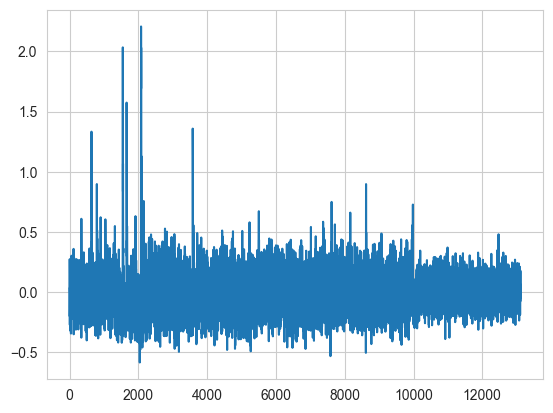

In [10]:
plt.plot(dFF[2:3, :].T)

In [11]:
tone_events = [120, 280, 440, 600, 760]
shock_events =[160, 320, 480, 640, 800]
delay_events = [140, 300, 460, 620, 780]

In [12]:
# events in full-frame indices
shock_frames_neurons = np.array([2179, 4365, 6550, 8735, 10925])
shock_frames_astros = np.array([2185, 4375, 6560, 8740, 10930])

#     #np.array([4379, 8751, 13129,  17494.6]) #15311.8,
# shock_frames = np.array([2179, 8751, 13129,  17494.6])
shock_times = shock_frames_neurons / 10.2  # convert to seconds


In [13]:
shock_times

array([ 213.62745098,  427.94117647,  642.15686275,  856.37254902,
       1071.07843137])

In [14]:
tone_times = shock_times - 40
tone_times

array([ 173.62745098,  387.94117647,  602.15686275,  816.37254902,
       1031.07843137])

In [15]:
delay_times = shock_times - 20
delay_times

array([ 193.62745098,  407.94117647,  622.15686275,  836.37254902,
       1051.07843137])

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def maxsort(arr):
    """Sort rows by the argmax of each row (ties keep numpy's default stability)."""
    return arr[np.argsort(np.argmax(arr, axis=1))]

def run_post_event_heatmap(
        traces,          # (T x N) or (N x T)
        timestamps,      # (T,) seconds, strictly increasing
        events,          # flat list/1D array of event times (seconds)
        save_path_prefix=None,
        window=15,       # seconds AFTER event onset
        vmin=-4, vmax=4
):
    # --- checks ---
    events = np.asarray(events, dtype=float).ravel()
    if events.size == 0:
        raise ValueError("`events` is empty. Provide at least one event time.")
    if timestamps.ndim != 1:
        raise ValueError("`timestamps` must be 1D.")
    if np.any(np.diff(timestamps) <= 0):
        raise ValueError("`timestamps` must be strictly increasing.")
    if traces.ndim != 2:
        raise ValueError("`traces` must be 2D (T x N) or (N x T).")

    # Ensure data is (N_cells x T)
    data_for_eta = traces.T if traces.shape[0] == timestamps.shape[0] else traces
    fs = 1.0 / np.median(np.diff(timestamps))
    n_points = int(window * fs)
    if n_points < 2:
        n_points = 2  # avoid degenerate interpolation
    t_rel = np.linspace(0, window, n_points)

    def event_window(signal, e):
        t_win = e + t_rel
        # only keep windows fully inside recording
        if t_win[-1] > timestamps[-1]:
            return None
        return np.interp(t_win, timestamps, signal)

    # Average ETA for each cell across all valid events
    all_cells = []
    for sig in data_for_eta:
        chunks = []
        for e in events:
            out = event_window(sig, e)
            if out is not None:
                chunks.append(out)
        if len(chunks):
            all_cells.append(np.mean(chunks, axis=0))
    if len(all_cells) == 0:
        raise ValueError("No valid event windows within the recording (try a smaller `window`).")

    eta_mean = np.vstack(all_cells)          # (N_cells x n_points)
    z = stats.zscore(eta_mean, axis=1, nan_policy='omit')
    z = np.nan_to_num(z, nan=0.0)

    z_sorted = maxsort(z)

    # --- Plot ---
    plt.rcParams.update({'font.size': 8, 'font.family': 'Arial'})
    sns.set(style="ticks", font="Arial")
    fig, ax = plt.subplots(figsize=(3, 4.5), dpi=600)

    sns.heatmap(
        z_sorted, ax=ax, cmap='viridis', vmin=vmin, vmax=vmax,
        cbar=True, cbar_kws={'label': 'Z-score'},
        xticklabels=True, yticklabels=False, rasterized=True
    )

    # X-axis in seconds
    T = z_sorted.shape[1]
    xticks = np.linspace(0, T - 1, 5).astype(int)
    xticklabels = np.linspace(0, window, 5).astype(int)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, rotation=0)

    # Y-axis: first & last row
    n_cells = z_sorted.shape[0]
    ax.set_yticks([0, max(n_cells-1, 0)])
    ax.set_yticklabels(['1', str(n_cells)], rotation=0)

    # event onset at 0 s (left edge)
    ax.axvline(0, linestyle='--', color='white', linewidth=1)
    ax.set_xlabel('Time after event (s)', fontsize=10)
    ax.set_ylabel('Astrocyte #', fontsize=10)
    sns.despine(ax=ax, left=True, bottom=True)
    plt.tight_layout()

    out_path = None
    if save_path_prefix:
        out_path = f"{save_path_prefix}_event_heatmap.svg"
        fig.savefig(out_path, dpi=600, bbox_inches='tight')

    return fig, ax, out_path

In [17]:

odd = np.array([2179,6550, 10925])
even = np.array([4365, 8735])
odd_times = odd / 10.2  # convert to seconds
even_times = even / 10.2  # convert to seconds

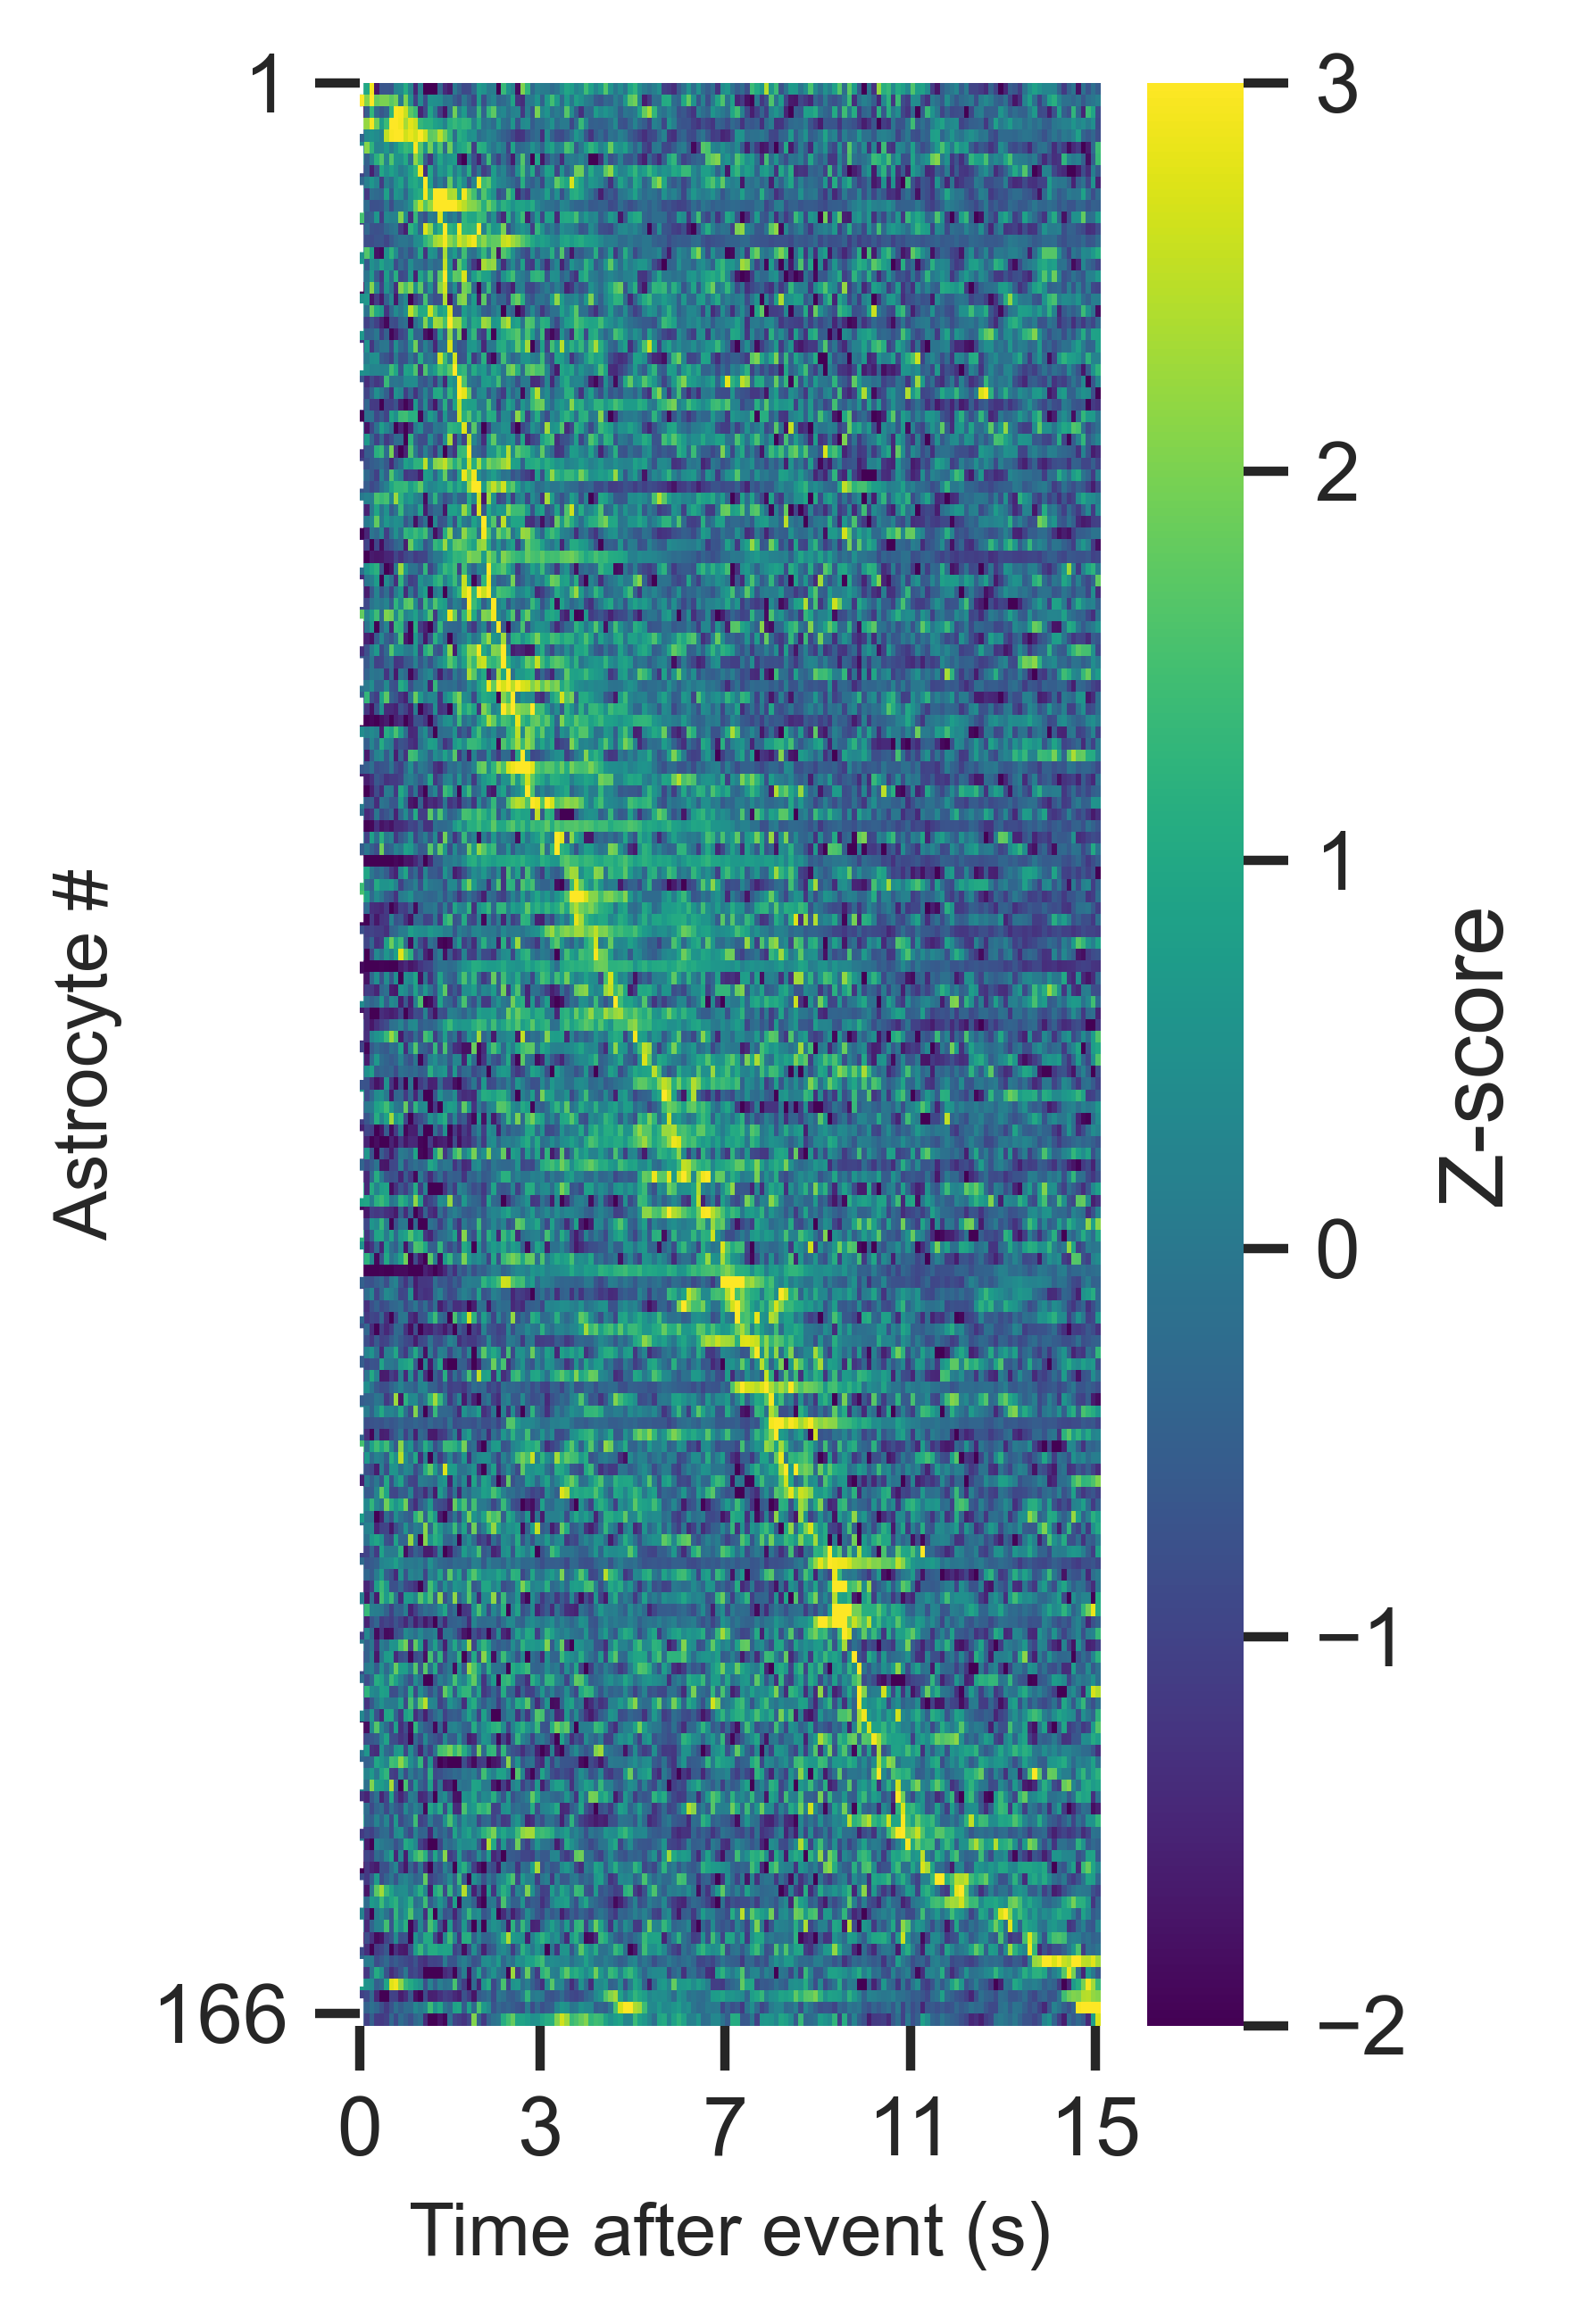

In [18]:

fig_tone,  ax_tone,  _ = run_post_event_heatmap(traces=dFF, timestamps=time, events=even_times,  window=15, vmin=-2, vmax=3)

# fig_delay, ax_delay, _ = run_post_event_heatmap(traces=dFF, timestamps=time, events=delay_times, window=20, vmin=-3, vmax=2, save_path_prefix="/Users/suthardr/Desktop/Sinai/neuron_trace_dFFZ")
# fig_shock, ax_shock, _ = run_post_event_heatmap(traces=dFF, timestamps=time, events=tone_times, window=20, vmin=-3, vmax=2, save_path_prefix="/Users/suthardr/Desktop/Sinai/neuron_tone_dFFZ")


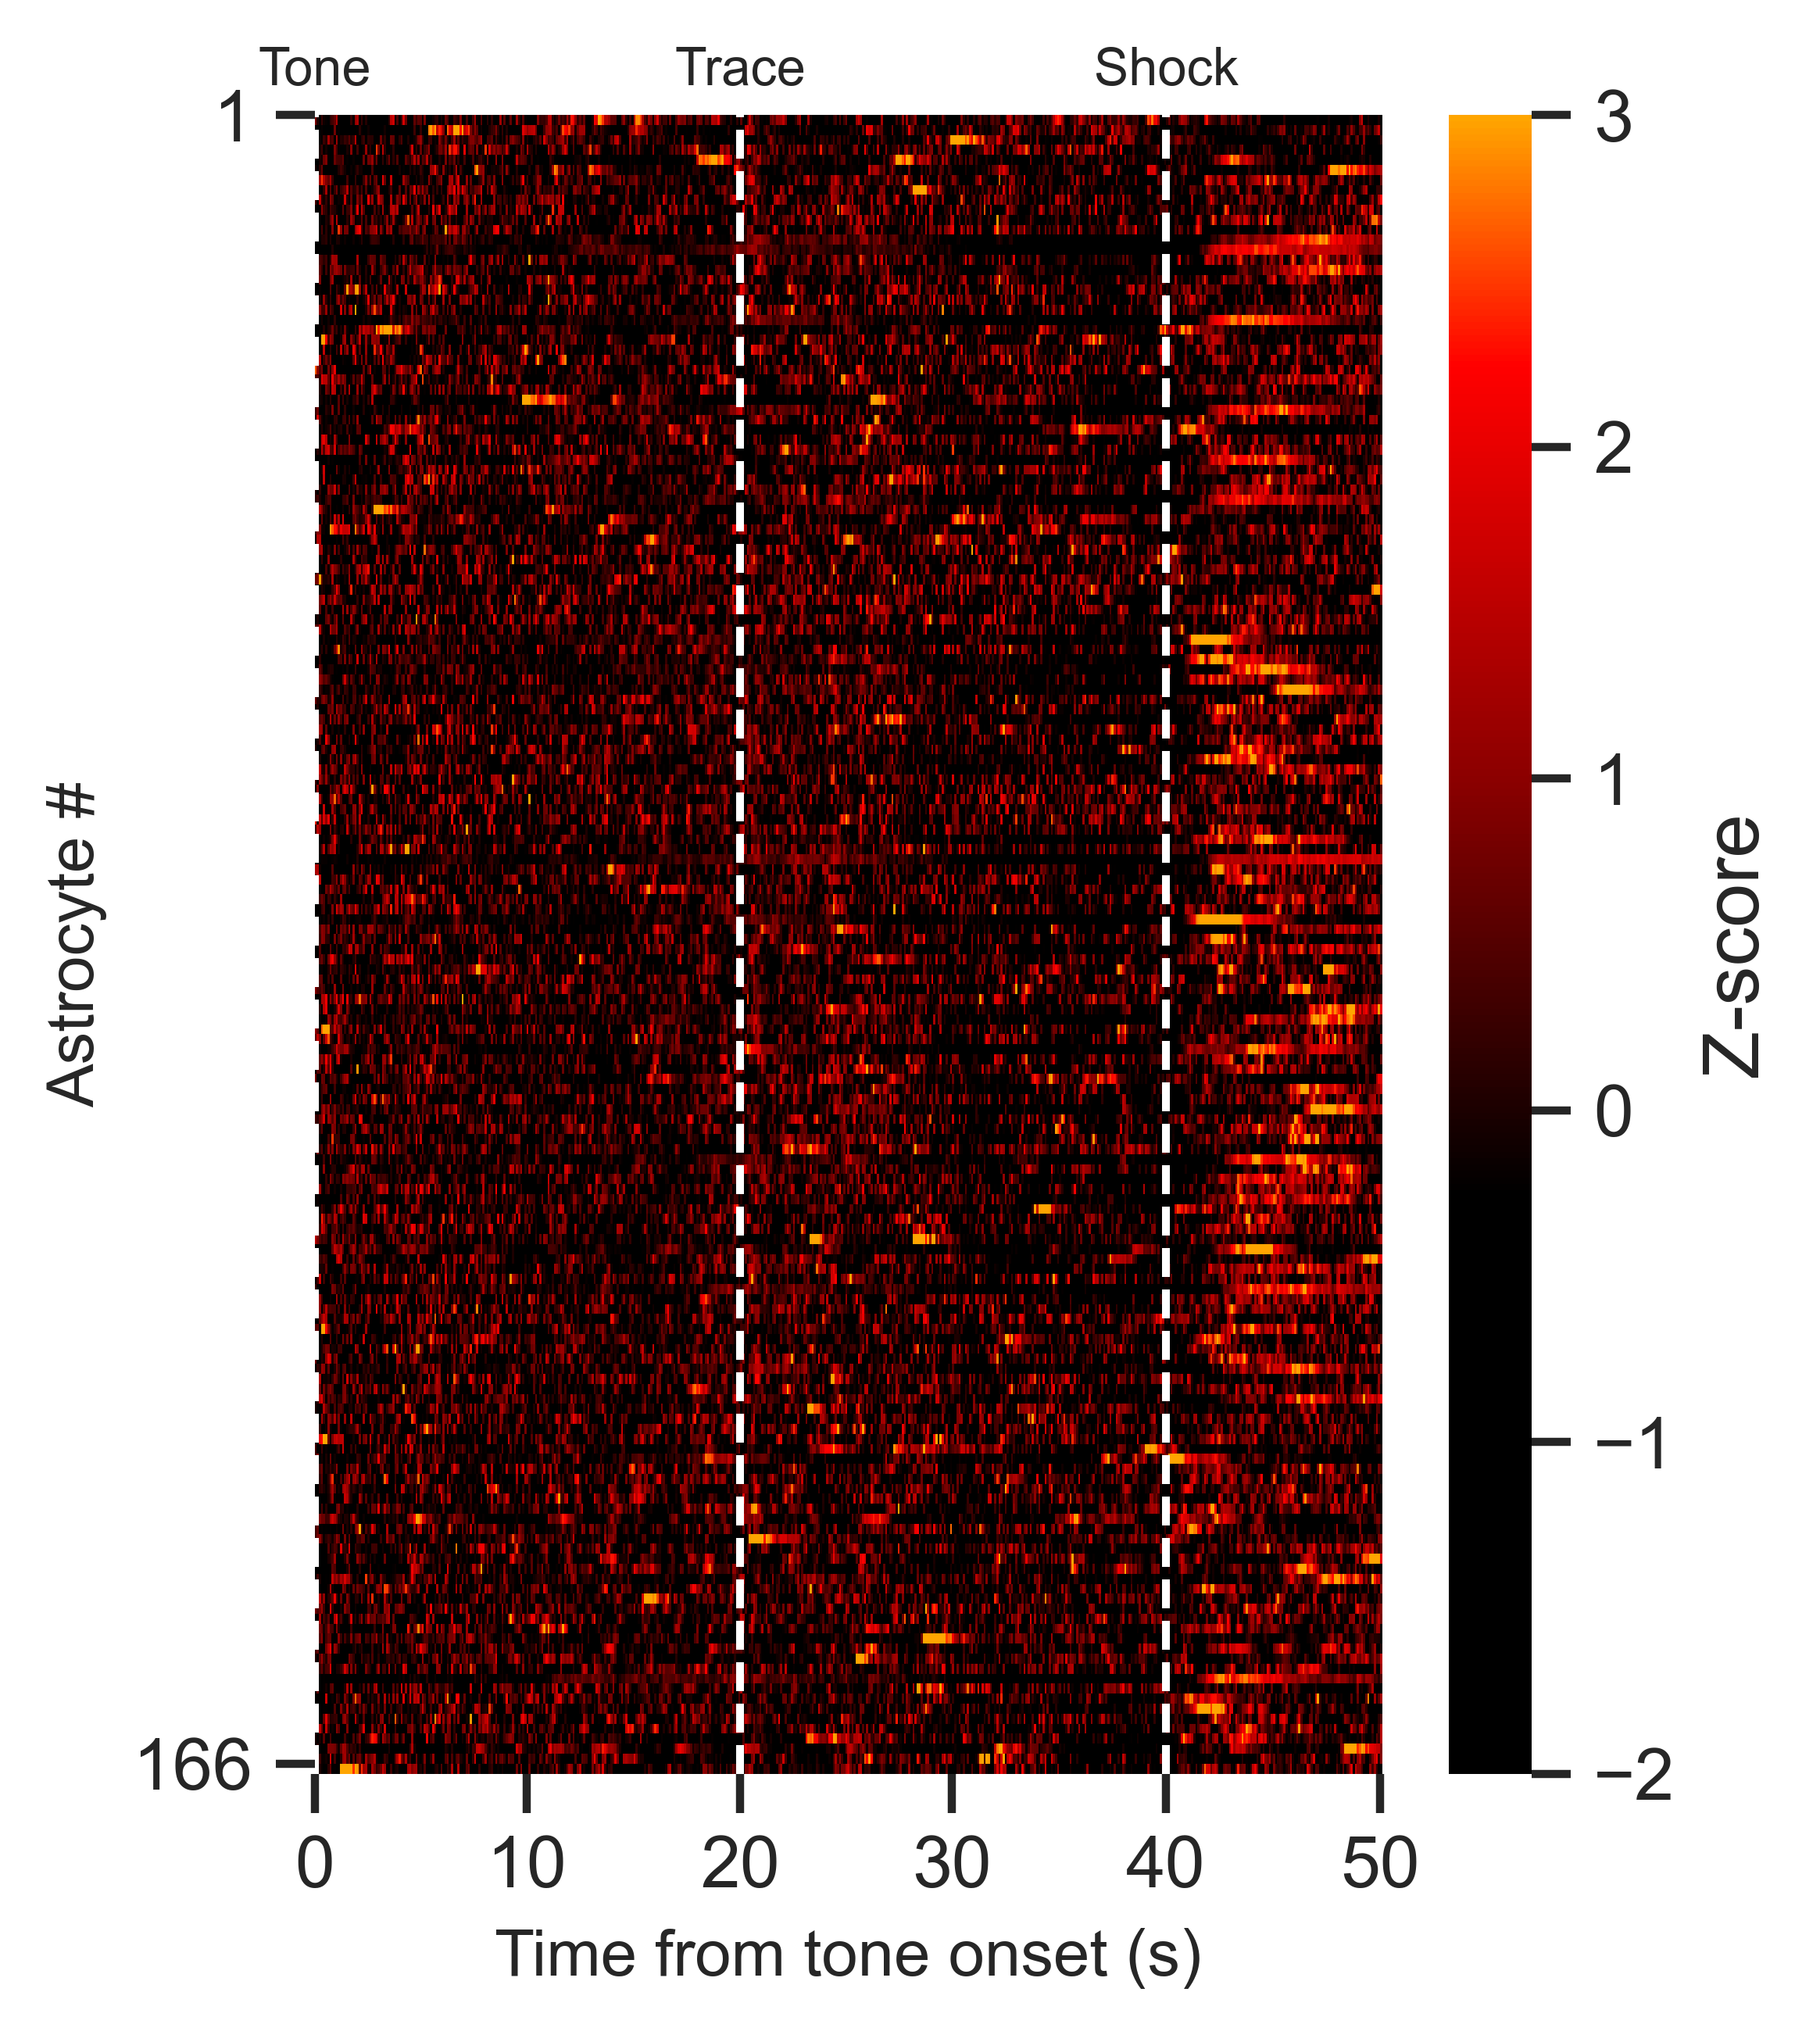

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap

red_black = LinearSegmentedColormap.from_list(
    "red_black",
    [
        (0.00, "black"),
        (0.35, "black"),
        (0.60, "darkred"),
        (0.85, "red"),
        (1.00, "orange")
    ]
)

def maxsort(arr):
    return arr[np.argsort(np.argmax(arr, axis=1))]

def run_trial_period_heatmap(
        traces,             # dFF or dFF_norm; shape (cells x time) or (time x cells)
        timestamps,         # time vector in seconds
        tone_events,         # tone onset times in seconds
        trial_window=55,     # plot tone onset through after shock; e.g. 60 s total
        trace_time=20,       # trace/delay onset relative to tone
        shock_time=40,       # shock onset relative to tone
        save_path=None,
        vmin=-2,
        vmax=3,
        cmap=red_black
):
    tone_events = np.asarray(tone_events, dtype=float).ravel()
    timestamps = np.asarray(timestamps, dtype=float)

    if traces.ndim != 2:
        raise ValueError("traces must be 2D")

    # Ensure traces are cells x time
    data = traces.T if traces.shape[0] == timestamps.shape[0] else traces

    fs = 1.0 / np.median(np.diff(timestamps))
    n_points = int(trial_window * fs)
    t_rel = np.linspace(0, trial_window, n_points)

    all_cells = []

    for sig in data:
        trial_chunks = []

        for tone in tone_events:
            t_win = tone + t_rel

            if t_win[0] < timestamps[0] or t_win[-1] > timestamps[-1]:
                continue

            chunk = np.interp(t_win, timestamps, sig)
            trial_chunks.append(chunk)

        if len(trial_chunks) > 0:
            all_cells.append(np.mean(trial_chunks, axis=0))

    if len(all_cells) == 0:
        raise ValueError("No valid full trial windows found. Try shortening trial_window.")

    eta_mean = np.vstack(all_cells)

    # Z-score each cell across the averaged trial window
    z = stats.zscore(eta_mean, axis=1, nan_policy="omit")
    z = np.nan_to_num(z, nan=0.0)

    # z_sorted = maxsort(z)
    z_sorted = z
    plt.rcParams.update({"font.size": 8, "font.family": "Arial"})
    sns.set(style="ticks", font="Arial")

    fig, ax = plt.subplots(figsize=(4, 4.5), dpi=600)

    sns.heatmap(
        z_sorted,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        cbar=True,
        cbar_kws={"label": "Z-score"},
        xticklabels=False,
        yticklabels=False,
        rasterized=True
    )

    # Convert seconds to heatmap x positions
    def sec_to_x(sec):
        return int((sec / trial_window) * (z_sorted.shape[1] - 1))

    tone_x = sec_to_x(0)
    trace_x = sec_to_x(trace_time)
    shock_x = sec_to_x(shock_time)

    ax.axvline(tone_x, linestyle="--", color="white", linewidth=1.2)
    ax.axvline(trace_x, linestyle="--", color="white", linewidth=1.2)
    ax.axvline(shock_x, linestyle="--", color="white", linewidth=1.2)

    # Label key behavioral epochs
    ax.text(tone_x, -2, "Tone", ha="center", va="bottom", fontsize=8)
    ax.text(trace_x, -2, "Trace", ha="center", va="bottom", fontsize=8)
    ax.text(shock_x, -2, "Shock", ha="center", va="bottom", fontsize=8)

    # X ticks in seconds from tone onset
    xtick_secs = np.arange(0, trial_window + 1, 10)
    xtick_pos = [sec_to_x(s) for s in xtick_secs]

    ax.set_xticks(xtick_pos)
    ax.set_xticklabels(xtick_secs, rotation=0)

    n_cells = z_sorted.shape[0]
    ax.set_yticks([0, max(n_cells - 1, 0)])
    ax.set_yticklabels(["1", str(n_cells)], rotation=0)

    ax.set_xlabel("Time from tone onset (s)", fontsize=10)
    ax.set_ylabel("Astrocyte #", fontsize=10)

    sns.despine(ax=ax, left=True, bottom=True)
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=600, bbox_inches="tight")

    return fig, ax, z_sorted

fig_trial, ax_trial, trial_heatmap = run_trial_period_heatmap(
    traces=dFF,
    timestamps=time,
    tone_events=tone_times,
    trial_window=50,
    trace_time=20,
    shock_time=40,
    vmin=-2,
    vmax=3,
    save_path="average_trial_period_heatmap.svg"
)

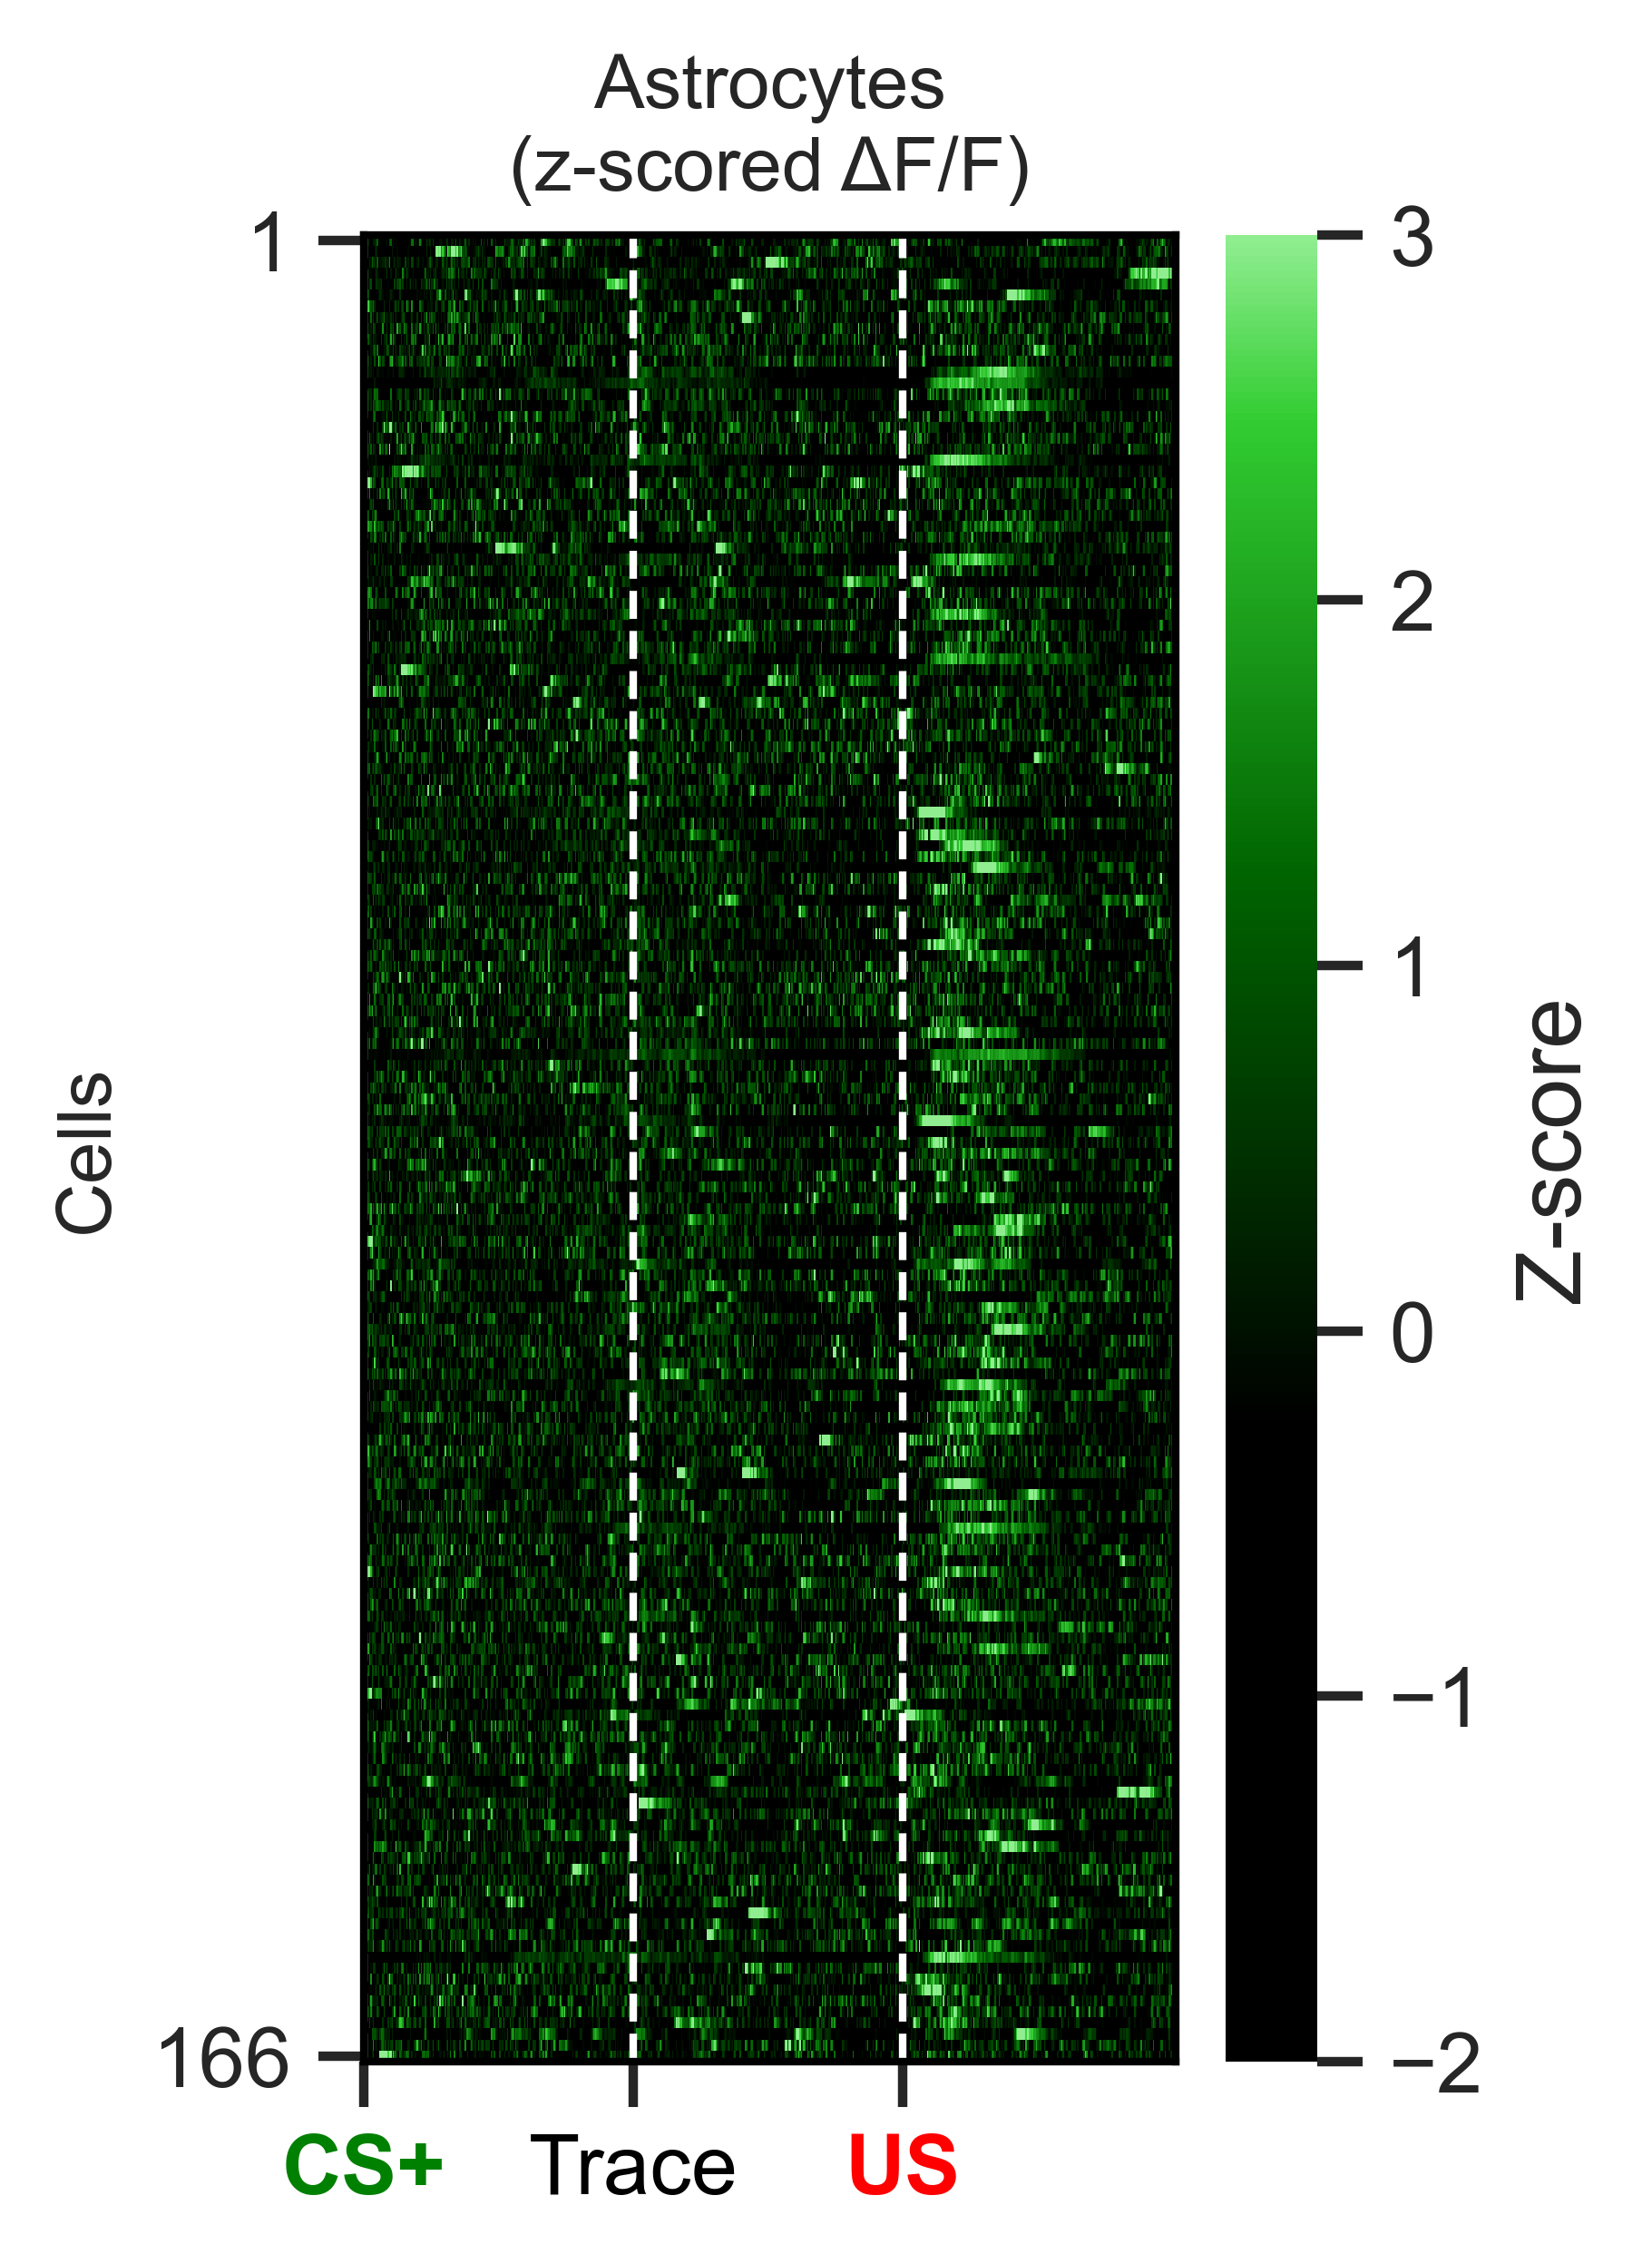

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap


def run_trial_period_heatmap_and_quantification(
        traces,  # dFF or dFF_norm; shape = cells x time OR time x cells
        timestamps,  # time vector in seconds
        tone_events,  # tone onset times in seconds
        trial_window=60,  # total window from tone onset
        trace_time=20,  # trace onset relative to tone
        shock_time=40,  # shock onset relative to tone
        save_path=None,
        vmin=-2,
        vmax=3,
        cmap=None,
        sort_cells=False
):
    tone_events = np.asarray(tone_events, dtype=float).ravel()
    timestamps = np.asarray(timestamps, dtype=float)

    if traces.ndim != 2:
        raise ValueError("traces must be 2D")

    if timestamps.ndim != 1:
        raise ValueError("timestamps must be 1D")

    if np.any(np.diff(timestamps) <= 0):
        raise ValueError("timestamps must be strictly increasing")

    # Ensure data are cells x time
    data = traces.T if traces.shape[0] == timestamps.shape[0] else traces

    fs = 1.0 / np.median(np.diff(timestamps))
    n_points = int(trial_window * fs)
    t_rel = np.linspace(0, trial_window, n_points)

    all_cells = []

    for sig in data:
        trial_chunks = []

        for tone in tone_events:
            t_win = tone + t_rel

            # Only use complete trial windows
            if t_win[0] < timestamps[0] or t_win[-1] > timestamps[-1]:
                continue

            chunk = np.interp(t_win, timestamps, sig)
            trial_chunks.append(chunk)

        if len(trial_chunks) > 0:
            all_cells.append(np.mean(trial_chunks, axis=0))

    if len(all_cells) == 0:
        raise ValueError("No valid full trial windows found. Try shortening trial_window.")

    # Average trial-period response for each cell
    eta_mean = np.vstack(all_cells)

    # Z-score each cell across its averaged trial window
    z = stats.zscore(eta_mean, axis=1, nan_policy="omit")
    z = np.nan_to_num(z, nan=0.0)

    # Optional sorting by time of peak response
    if sort_cells:
        sort_idx = np.argsort(np.argmax(z, axis=1))
        z_plot = z[sort_idx]
    else:
        sort_idx = np.arange(z.shape[0])
        z_plot = z

    # Helper: convert seconds to heatmap index
    def sec_to_idx(sec):
        return int((sec / trial_window) * (z.shape[1] - 1))

    tone_start = sec_to_idx(0)
    tone_end = sec_to_idx(trace_time)

    trace_start = sec_to_idx(trace_time)
    trace_end = sec_to_idx(shock_time)

    shock_start = sec_to_idx(shock_time)
    shock_end = sec_to_idx(trial_window)

    # Epoch-level quantification from unsorted z
    tone_mean = np.mean(z[:, tone_start:tone_end], axis=1)
    trace_mean = np.mean(z[:, trace_start:trace_end], axis=1)
    shock_mean = np.mean(z[:, shock_start:shock_end], axis=1)
    shock_max = np.max(z[:, shock_start:shock_end], axis=1)

    epoch_responses = {
        "tone_mean": tone_mean,
        "trace_mean": trace_mean,
        "shock_mean": shock_mean,
        "shock_max": shock_max,
        "z": z,
        "z_plot": z_plot,
        "eta_mean": eta_mean,
        "sort_idx": sort_idx
    }

    # Colormap: black-to-green, similar to the reference panel
    if cmap is None:
        cmap = LinearSegmentedColormap.from_list(
            "black_green",
            [
                (0.00, "black"),
                (0.35, "black"),
                (0.65, "darkgreen"),
                (0.90, "limegreen"),
                (1.00, "lightgreen")
            ]
        )

    plt.rcParams.update({
        "font.family": "Arial",
        "font.size": 8,
        "axes.linewidth": 1
    })

    fig, ax = plt.subplots(figsize=(3.0, 4.2), dpi=600)

    sns.heatmap(
        z_plot,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        cbar=True,
        cbar_kws={"label": "Z-score"},
        xticklabels=False,
        yticklabels=False,
        rasterized=True
    )

    # Event positions
    tone_x = sec_to_idx(0)
    trace_x = sec_to_idx(trace_time)
    shock_x = sec_to_idx(shock_time)

    # Event lines
    ax.axvline(tone_x, linestyle="--", color="white", linewidth=1.0)
    ax.axvline(trace_x, linestyle="--", color="white", linewidth=1.0)
    ax.axvline(shock_x, linestyle="--", color="white", linewidth=1.0)

    # Event labels on x-axis
    ax.set_xticks([tone_x, trace_x, shock_x])
    ax.set_xticklabels(["CS+", "Trace", "US"], rotation=0)

    xticklabels = ax.get_xticklabels()
    xticklabels[0].set_color("green")
    xticklabels[0].set_fontweight("bold")
    xticklabels[1].set_color("black")
    xticklabels[2].set_color("red")
    xticklabels[2].set_fontweight("bold")

    # Y-axis cell numbering
    n_cells = z_plot.shape[0]
    ax.set_yticks([0.5, n_cells - 0.5])
    ax.set_yticklabels(["1", str(n_cells)], rotation=0)

    ax.set_xlabel("")
    ax.set_ylabel("Cells", fontsize=10)
    ax.set_title("Astrocytes\n(z-scored ΔF/F)", fontsize=10, pad=6)

    # Keep border visible
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_color("black")

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=600, bbox_inches="tight")

    return fig, ax, epoch_responses

fig_trial, ax_trial, epoch_responses = run_trial_period_heatmap_and_quantification(
    traces=dFF,
    timestamps=time,
    tone_events=tone_times,
    trial_window=60,
    trace_time=20,
    shock_time=40,
    vmin=-2,
    vmax=3,
    sort_cells=False,
    save_path="average_trial_period_heatmap.svg"
)



In [39]:
tone_mean = epoch_responses["tone_mean"]
trace_mean = epoch_responses["trace_mean"]
shock_mean = epoch_responses["shock_mean"]
shock_max = epoch_responses["shock_max"]
z = epoch_responses["z"]

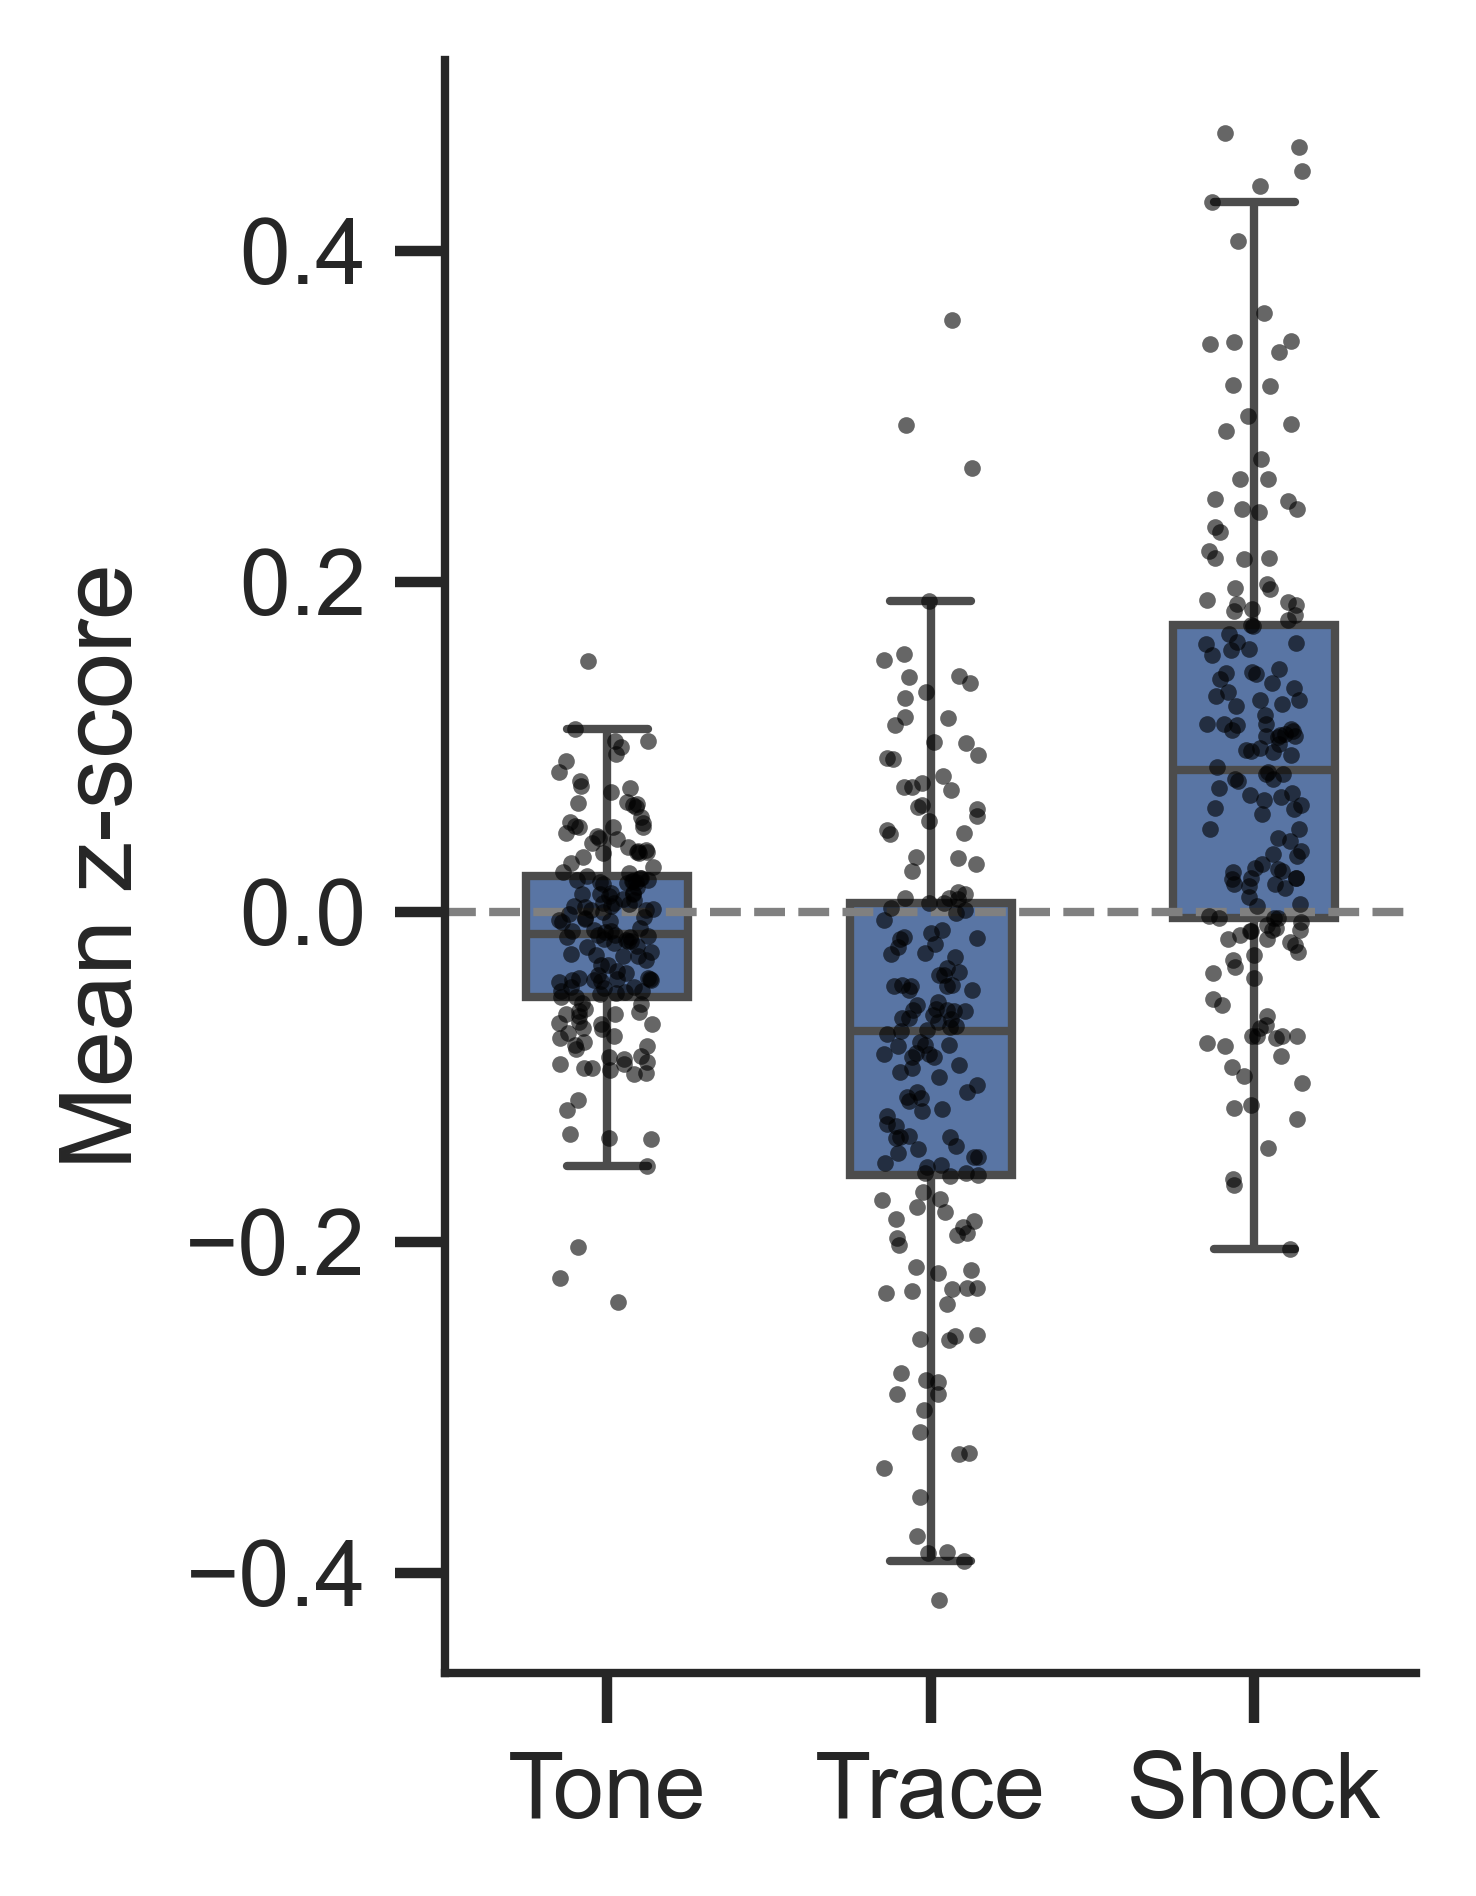

In [40]:
import pandas as pd

epoch_df = pd.DataFrame({
    "Tone": tone_mean,
    "Trace": trace_mean,
    "Shock": shock_mean
})

epoch_long = epoch_df.melt(
    var_name="Epoch",
    value_name="Mean z-score"
)

plt.figure(figsize=(2.5, 3.2), dpi=600)

sns.boxplot(
    data=epoch_long,
    x="Epoch",
    y="Mean z-score",
    width=0.5,
    showfliers=False
)

sns.stripplot(
    data=epoch_long,
    x="Epoch",
    y="Mean z-score",
    color="black",
    size=2,
    alpha=0.6,
    jitter=0.15
)

plt.axhline(0, linestyle="--", color="gray", linewidth=1)
plt.ylabel("Mean z-score")
plt.xlabel("")
sns.despine()
plt.tight_layout()
plt.savefig("epoch_mean_zscore_quantification.svg", dpi=600, bbox_inches="tight")
plt.show()

In [485]:
import numpy as np
import scipy.interpolate
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Core ETA (event-triggered average) ----------
def compute_event_triggered_etas(
    traces,                # (T x N) or (N x T)
    timestamps,            # (T,) strictly increasing (seconds)
    events,                # list of event times [e1, e2, ...] OR per-cell list of lists
    window_pre=5.0,        # seconds BEFORE event
    window_post=10.0,      # seconds AFTER event
    interp_kind="linear",  # 'linear', 'cubic', etc.
    baseline_window=(-5.0, -3.0)  # seconds relative to event (within [-window_pre, window_post])
):
    # Ensure (N x T)
    if traces.ndim != 2:
        raise ValueError("`traces` must be 2D (T x N) or (N x T).")
    T, N_guess = traces.shape
    if traces.shape[0] == timestamps.shape[0]:     # (T x N)
        data = traces.T                            # -> (N x T)
    elif traces.shape[1] == timestamps.shape[0]:   # (N x T)
        data = traces                              # already (N x T)
    else:
        raise ValueError("`traces` first or second dimension must match len(timestamps).")

    if timestamps.ndim != 1 or np.any(np.diff(timestamps) <= 0):
        raise ValueError("`timestamps` must be a strictly increasing 1D array.")

    # Events: allow a single list for all cells or per-cell lists
    n_cells = data.shape[0]
    if isinstance(events, (list, np.ndarray)) and len(events) > 0 and not isinstance(events[0], (list, np.ndarray)):
        # same events for every cell
        per_cell_events = [np.asarray(events, dtype=float)] * n_cells
    else:
        # assume list of lists (one per cell)
        if len(events) != n_cells:
            raise ValueError("If you pass per-cell events, length must match number of cells.")
        per_cell_events = [np.asarray(ev, dtype=float) for ev in events]

    # Time axis for ETA
    t_rel = np.linspace(-window_pre, window_post, int(round((window_pre + window_post) / np.median(np.diff(timestamps)))))

    # Interpolator builder (per cell)
    def interp_fn(sig):
        return scipy.interpolate.interp1d(
            timestamps, sig, kind=interp_kind, bounds_error=False, fill_value="extrapolate"
        )

    etas_per_cell = []
    for i, sig in enumerate(data):
        f = interp_fn(sig)
        etas_this_cell = []
        for e in per_cell_events[i]:
            t_win = e + t_rel
            # Keep only windows fully inside the recording (optional but safer)
            if t_win[0] < timestamps[0] or t_win[-1] > timestamps[-1]:
                continue
            etas_this_cell.append(f(t_win))
        if len(etas_this_cell):
            per_event = np.vstack(etas_this_cell)  # (#events x #timepoints)
            etas_per_cell.append(per_event.mean(axis=0))  # average across events for this cell

    if len(etas_per_cell) == 0:
        raise ValueError("No valid event windows inside the recording. Try adjusting window_pre/window_post.")

    etas_per_cell = np.vstack(etas_per_cell)  # (Nc_valid x T_rel)

    # Baseline correction using baseline_window (relative to event)
    # Find indices inside t_rel that match the baseline window
    b0, b1 = baseline_window
    if b0 < -window_pre or b1 > window_post:
        raise ValueError("baseline_window must lie within [-window_pre, window_post].")
    bi = np.where((t_rel >= b0) & (t_rel <= b1))[0]
    if bi.size == 0:
        raise ValueError("baseline_window chosen too narrow; contains no samples.")
    baselines = etas_per_cell[:, bi].mean(axis=1, keepdims=True)
    etas_per_cell = etas_per_cell - baselines

    return t_rel, etas_per_cell  # per-cell, baseline-corrected ETAs


# ---------- Confidence intervals ----------
def t_confidence_interval(across_cells, alpha=0.05):
    """
    across_cells: (Nc x T)
    Returns low, high arrays shape (T,)
    """
    m = np.nanmean(across_cells, axis=0)
    s = stats.sem(across_cells, axis=0, nan_policy='omit')
    nc = across_cells.shape[0]
    if nc < 2:
        # degenerate; no CI
        return m, m
    tcrit = stats.t.ppf(1 - alpha/2.0, df=nc - 1)
    low = m - tcrit * s
    high = m + tcrit * s
    return low, high

def bootstrap_confidence_interval(across_cells, alpha=0.05, n_boot=1000, rng=None):
    """
    across_cells: (Nc x T)
    Nonparametric bootstrap over cells.
    """
    rng = np.random.default_rng(None if rng is None else rng)
    Nc, T = across_cells.shape
    if Nc < 2:
        m = np.nanmean(across_cells, axis=0)
        return m, m
    boots = np.empty((n_boot, T), dtype=float)
    for b in range(n_boot):
        idx = rng.integers(0, Nc, Nc)
        boots[b] = np.nanmean(across_cells[idx], axis=0)
    low = np.percentile(boots, 100*alpha/2.0, axis=0)
    high = np.percentile(boots, 100*(1 - alpha/2.0), axis=0)
    return low, high


# ---------- Significance detection (run-length above/below 0) ----------
def contiguous_sig_runs(ci_low, ci_high, min_duration_s, t_rel):
    """
    Mark segments where the CI excludes 0 for at least min_duration_s.
    Returns list of (start_index, end_index) inclusive indices.
    """
    dt = np.median(np.diff(t_rel))
    min_len = max(1, int(np.round(min_duration_s / dt)))

    # CI excludes zero if both bounds > 0 OR both < 0
    sig_mask = (ci_low > 0) | (ci_high < 0)

    runs = []
    start = None
    for i, v in enumerate(sig_mask):
        if v and start is None:
            start = i
        elif not v and start is not None:
            if i - start >= min_len:
                runs.append((start, i - 1))
            start = None
    if start is not None and (len(sig_mask) - start) >= min_len:
        runs.append((start, len(sig_mask) - 1))
    return runs


# ---------- High-level wrapper (no onep dependency) ----------
def eta_all(
    dFF, timestamps, events,
    window_pre=5.0, window_post=10.0,
    ci="tci", alpha=0.05, n_boot=1000,
    baseline_window=(-5.0, -3.0),
    sig_duration=10.0  # seconds
):
    """
    Computes per-cell baseline-corrected ETAs, group mean, CI, and significant segments.

    Parameters mirror your original, but with dFF/timestamps/events like your earlier code.
    """
    t_rel, across_eta_per_cell = compute_event_triggered_etas(
        dFF, timestamps, events,
        window_pre=window_pre, window_post=window_post,
        baseline_window=baseline_window
    )

    mean_trace = np.nanmean(across_eta_per_cell, axis=0)

    if ci == "tci":
        lo, hi = t_confidence_interval(across_eta_per_cell, alpha=alpha)
    elif ci == "bci":
        lo, hi = bootstrap_confidence_interval(across_eta_per_cell, alpha=alpha, n_boot=n_boot)
    else:
        raise ValueError("ci must be 'tci' or 'bci'")

    sig_runs = contiguous_sig_runs(lo, hi, min_duration_s=sig_duration, t_rel=t_rel)
    return t_rel, mean_trace, (lo, hi), sig_runs, across_eta_per_cell


# ---------- Plotting helper ----------
def plot_eta_all(
    dFF, timestamps, events,
    title="", save_path=None,
    window_pre=5.0, window_post=10.0,
    ci="tci", alpha=0.05, n_boot=1000,
    baseline_window=(-5.0, -3.0),
    sig_duration=10.0,
    line_kwargs=None, fill_kwargs=None
):
    """
    Plot ETA mean ± CI with significance bars, compatible with your previous API.
    """
    if line_kwargs is None:
        line_kwargs = dict(color="#B39BC8", linewidth=1.5)
    if fill_kwargs is None:
        fill_kwargs = dict(alpha=0.25)

    t_rel, mean_trace, (lo, hi), sig_runs, across_eta_per_cell = eta_all(
        dFF, timestamps, events,
        window_pre=window_pre, window_post=window_post,
        ci=ci, alpha=alpha, n_boot=n_boot,
        baseline_window=baseline_window, sig_duration=sig_duration
    )

    plt.rcParams.update({'font.size': 8})
    sns.set(style="ticks", font="Arial")

    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)
    ax.plot(t_rel, mean_trace, **line_kwargs)
    ax.fill_between(t_rel, lo, hi, **fill_kwargs)

    # Event at t=0
    ax.axvline(x=0, color='black', linestyle='--')
    ax.text(0, ax.get_ylim()[1] * 1.02, 'Event Onset', ha='center', va='bottom', fontsize=8, fontname='Arial')

    ax.set_ylabel(r"ΔF/F", fontsize=10, fontname='Arial', labelpad=15)
    ax.set_xlabel('Time (s)', fontsize=10, fontname='Arial')
    ax.set_title(title, fontsize=10, pad=10, fontname='Arial')
    ax.tick_params(labelsize=8)
    sns.despine(ax=ax)
    plt.tight_layout(pad=3)

    # Significance bars along the top
    y_marker = ax.get_ylim()[1] * 0.97
    for s, e in sig_runs:
        ax.hlines(y=y_marker, xmin=t_rel[s], xmax=t_rel[e], linewidth=1, color='black')

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')

    return fig, ax, (t_rel, mean_trace, (lo, hi), sig_runs, across_eta_per_cell)


(166, 153)


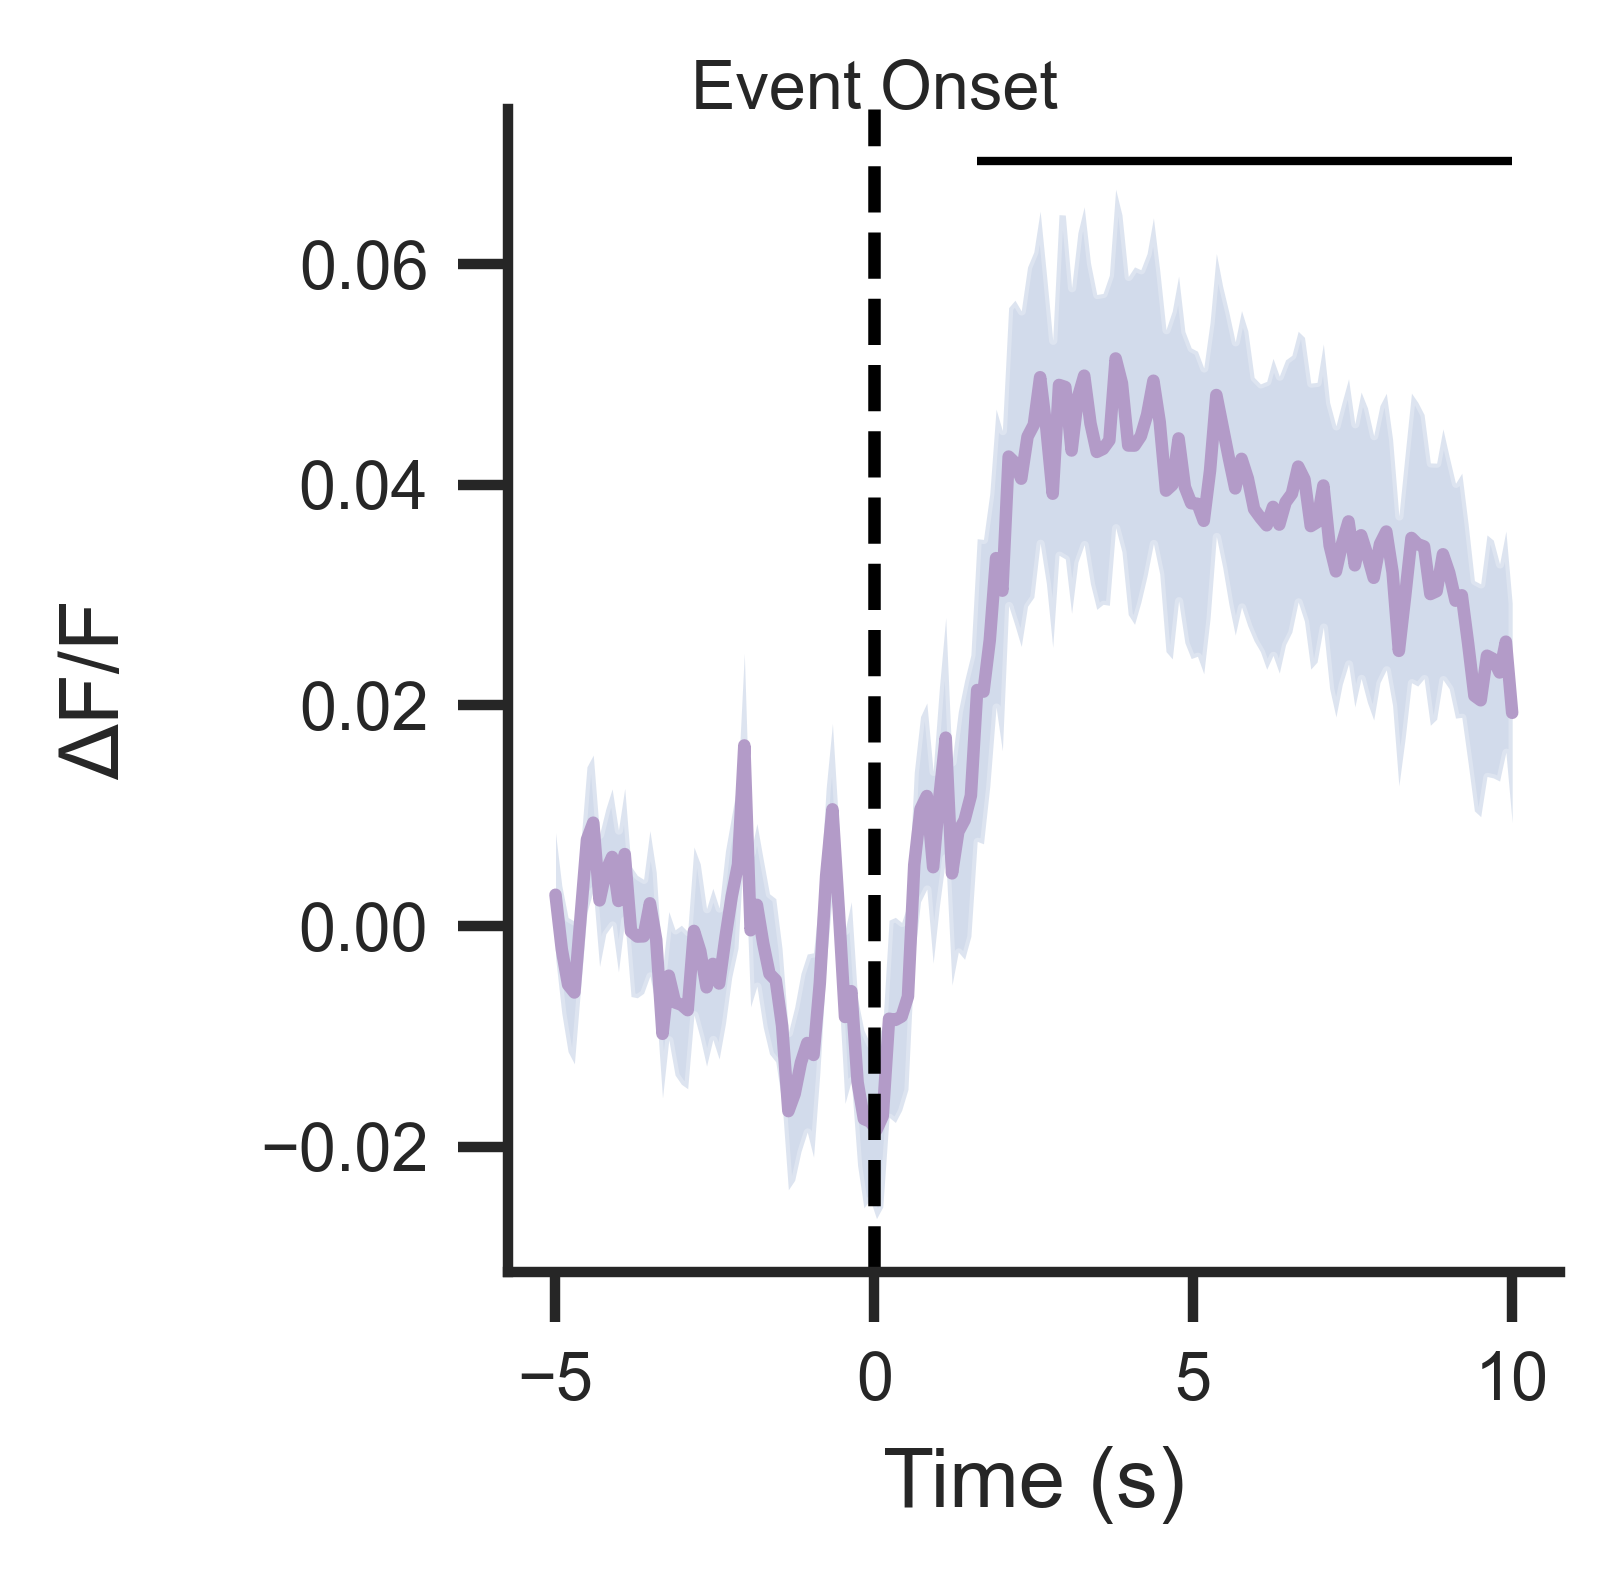

In [490]:
# Call the function and unpack all returned outputs
fig, ax, (t_rel, mean_trace, ci_bounds, sig_runs, across_eta_per_cell) = plot_eta_all(
    dFF,
    time,
    events=shock_times,
    window_pre=5.0,
    window_post=10.0,
    ci='tci',
    sig_duration=1.0,
    save_path="/Users/suthardr/Desktop/Sinai/neuron_avg_shock_10s.svg"
)

# Now you can access the per-cell data directly
print(across_eta_per_cell.shape)



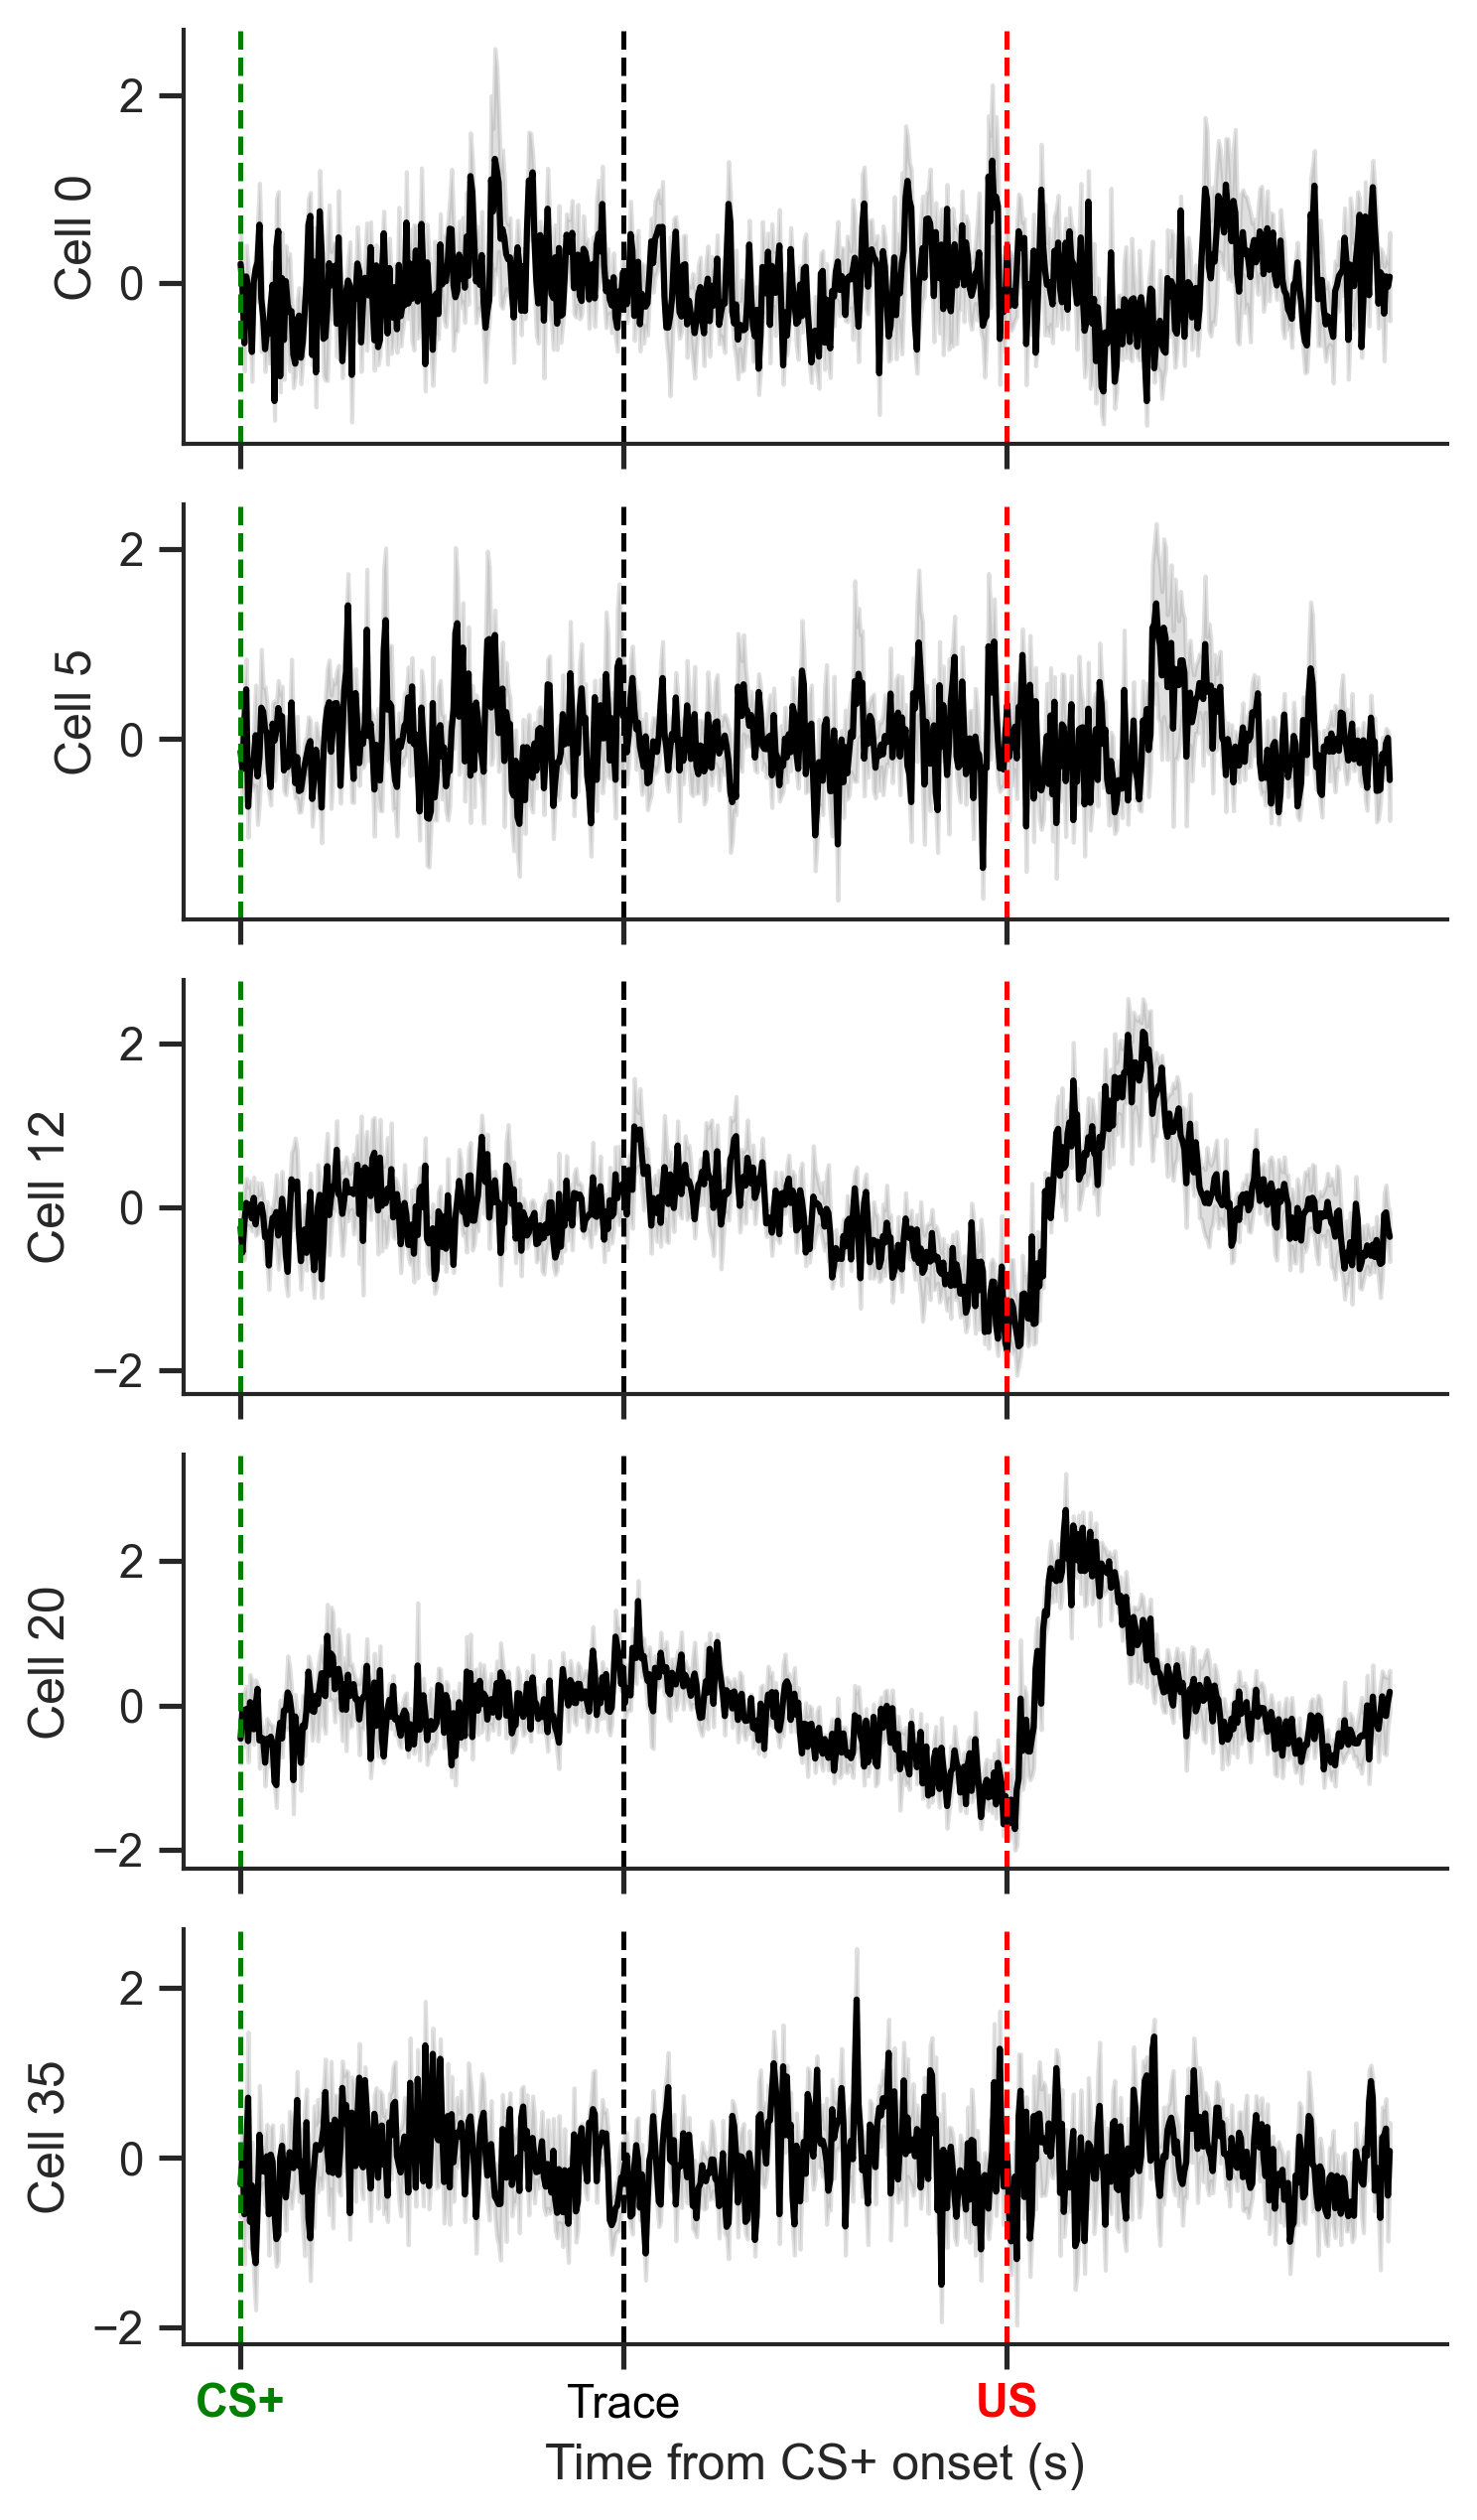

In [41]:
import numpy as np
import matplotlib.pyplot as plt


def plot_average_trial_traces_for_cells(
        traces,
        timestamps,
        tone_events,
        cell_ids,
        trial_window=60,
        trace_time=20,
        shock_time=40,
        zscore_each_cell=True,
        save_path=None
):
    tone_events = np.asarray(tone_events, dtype=float).ravel()
    timestamps = np.asarray(timestamps, dtype=float)
    cell_ids = np.asarray(cell_ids, dtype=int)

    # Ensure data are cells x time
    data = traces.T if traces.shape[0] == timestamps.shape[0] else traces

    fs = 1.0 / np.median(np.diff(timestamps))
    n_points = int(trial_window * fs)
    t_rel = np.linspace(0, trial_window, n_points)

    avg_traces = []
    sem_traces = []

    for cell in cell_ids:
        sig = data[cell]
        trial_chunks = []

        for tone in tone_events:
            t_win = tone + t_rel

            if t_win[0] < timestamps[0] or t_win[-1] > timestamps[-1]:
                continue

            chunk = np.interp(t_win, timestamps, sig)
            trial_chunks.append(chunk)

        if len(trial_chunks) == 0:
            avg_traces.append(np.full_like(t_rel, np.nan))
            sem_traces.append(np.full_like(t_rel, np.nan))
            continue

        trial_chunks = np.vstack(trial_chunks)

        if zscore_each_cell:
            trial_mean = np.mean(trial_chunks, axis=1, keepdims=True)
            trial_std = np.std(trial_chunks, axis=1, keepdims=True)
            trial_std[trial_std == 0] = 1
            trial_chunks = (trial_chunks - trial_mean) / trial_std

        avg_traces.append(np.mean(trial_chunks, axis=0))
        sem_traces.append(np.std(trial_chunks, axis=0) / np.sqrt(trial_chunks.shape[0]))

    avg_traces = np.vstack(avg_traces)
    sem_traces = np.vstack(sem_traces)

    fig, axes = plt.subplots(
        len(cell_ids), 1,
        figsize=(5, 1.7 * len(cell_ids)),
        dpi=300,
        sharex=True
    )

    if len(cell_ids) == 1:
        axes = [axes]

    for ax, cell, mean_trace, sem_trace in zip(axes, cell_ids, avg_traces, sem_traces):
        ax.plot(t_rel, mean_trace, linewidth=1.5, color="black")
        ax.fill_between(
            t_rel,
            mean_trace - sem_trace,
            mean_trace + sem_trace,
            alpha=0.25,
            color="gray"
        )

        # Explicit trial structure
        ax.axvline(0, linestyle="--", linewidth=1.2, color="green")
        ax.axvline(trace_time, linestyle="--", linewidth=1.2, color="black")
        ax.axvline(shock_time, linestyle="--", linewidth=1.2, color="red")

        ax.set_ylabel(f"Cell {cell}")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[-1].set_xlabel("Time from CS+ onset (s)")

    # Use trial-event labels as x ticks
    axes[-1].set_xticks([0, trace_time, shock_time])
    axes[-1].set_xticklabels(["CS+", "Trace", "US"])

    xticklabels = axes[-1].get_xticklabels()
    xticklabels[0].set_color("green")
    xticklabels[0].set_fontweight("bold")
    xticklabels[1].set_color("black")
    xticklabels[2].set_color("red")
    xticklabels[2].set_fontweight("bold")

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, axes, t_rel, avg_traces, sem_traces

fig, axes, t_rel, avg_traces, sem_traces = plot_average_trial_traces_for_cells(
    traces=dFF,
    timestamps=time,
    tone_events=tone_times,
    cell_ids=[0, 5, 12, 20, 35],
    trial_window=60,
    trace_time=20,
    shock_time=40,
    zscore_each_cell=True,
    save_path="example_cells_CS_trace_US_average_trial_traces.svg"
)

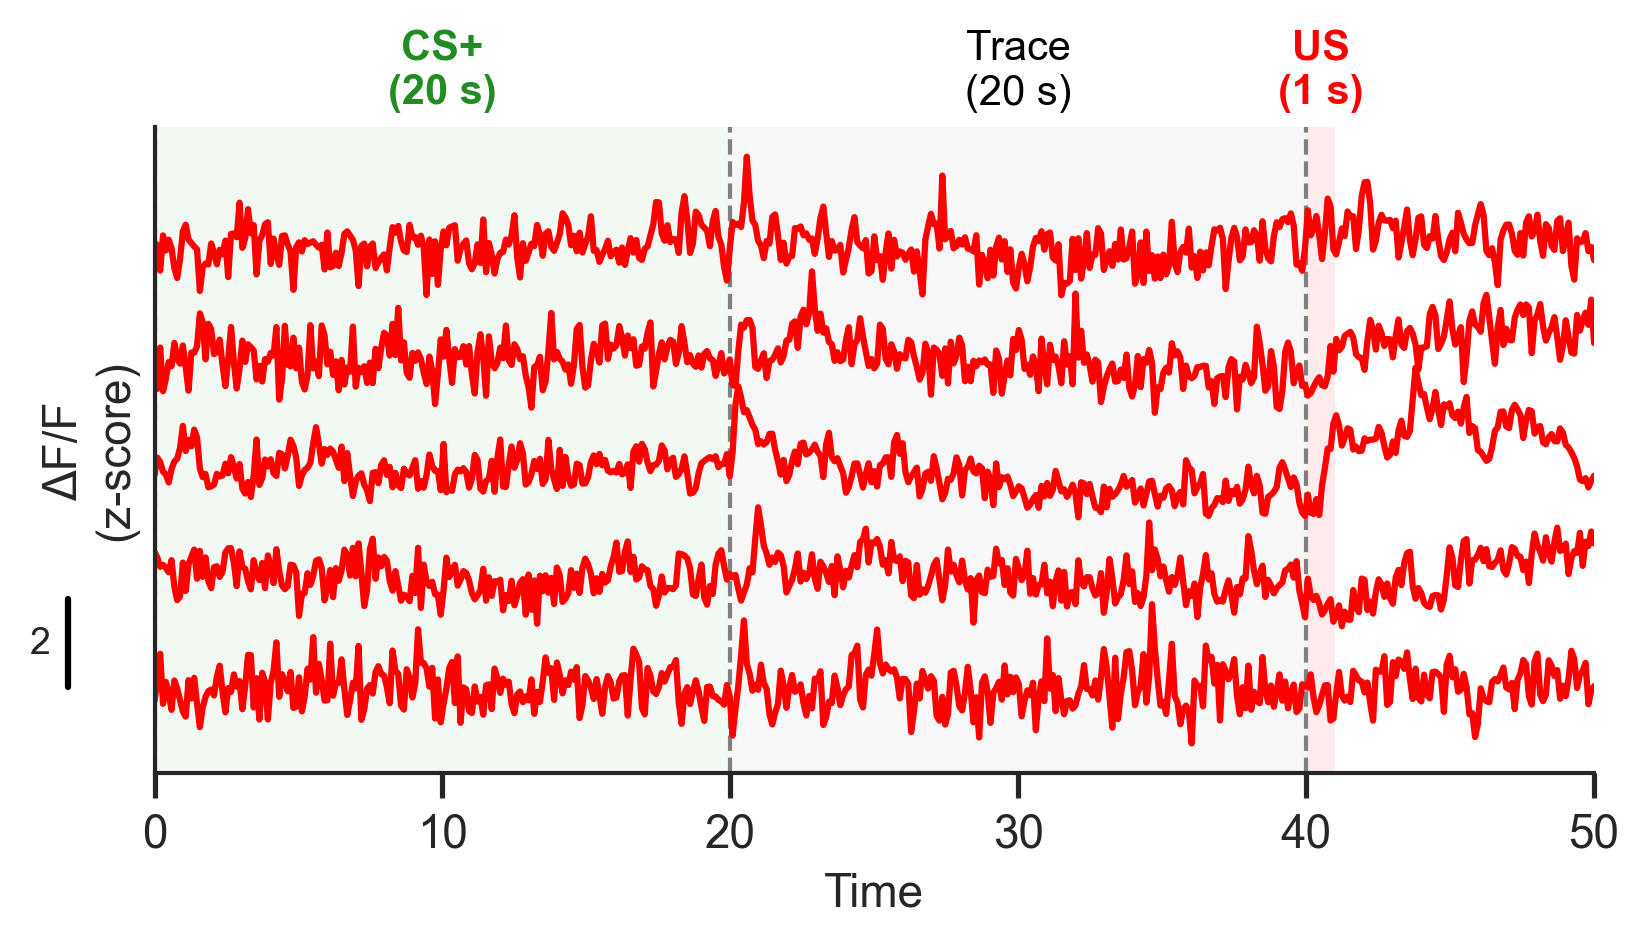

In [48]:
import numpy as np
import matplotlib.pyplot as plt


def plot_stacked_average_trial_responses(
        traces,  # cells x time OR time x cells
        timestamps,  # 1D time vector in seconds
        tone_events,  # CS+ onset times in seconds
        cell_ids,  # list of cells to plot
        trial_window=50,  # total trial window from CS+ onset
        trace_time=20,  # Trace starts 20 s after CS+
        shock_time=40,  # US starts 40 s after CS+
        us_duration=1,  # US duration (for label/shading only)
        zscore_each_cell=True,
        colors=None,  # list of colors for each cell, or None
        linewidth=1.5,
        offset_scale=2.5,  # vertical spacing between cells
        show_sem=False,
        save_path=None
):
    tone_events = np.asarray(tone_events, dtype=float).ravel()
    timestamps = np.asarray(timestamps, dtype=float)
    cell_ids = np.asarray(cell_ids, dtype=int)

    if traces.ndim != 2:
        raise ValueError("traces must be 2D")

    # ensure cells x time
    data = traces.T if traces.shape[0] == timestamps.shape[0] else traces

    fs = 1.0 / np.median(np.diff(timestamps))
    n_points = int(trial_window * fs)
    t_rel = np.linspace(0, trial_window, n_points)

    avg_traces = []
    sem_traces = []

    for cell in cell_ids:
        sig = data[cell]
        trial_chunks = []

        for tone in tone_events:
            t_win = tone + t_rel

            # only keep full trial windows
            if t_win[0] < timestamps[0] or t_win[-1] > timestamps[-1]:
                continue

            chunk = np.interp(t_win, timestamps, sig)
            trial_chunks.append(chunk)

        if len(trial_chunks) == 0:
            avg_traces.append(np.full_like(t_rel, np.nan))
            sem_traces.append(np.full_like(t_rel, np.nan))
            continue

        trial_chunks = np.vstack(trial_chunks)

        if zscore_each_cell:
            # z-score each trial independently
            m = np.mean(trial_chunks, axis=1, keepdims=True)
            s = np.std(trial_chunks, axis=1, keepdims=True)
            s[s == 0] = 1
            trial_chunks = (trial_chunks - m) / s

        avg_traces.append(np.mean(trial_chunks, axis=0))
        sem_traces.append(np.std(trial_chunks, axis=0) / np.sqrt(trial_chunks.shape[0]))

    avg_traces = np.vstack(avg_traces)
    sem_traces = np.vstack(sem_traces)

    # default colors
    if colors is None:
        colors = ["forestgreen"] * len(cell_ids)

    fig, ax = plt.subplots(figsize=(5.5, 3.2), dpi=300)

    # epoch guides
    ax.axvspan(0, trace_time, color="green", alpha=0.05, lw=0)
    ax.axvspan(trace_time, shock_time, color="gray", alpha=0.06, lw=0)
    ax.axvspan(shock_time, shock_time + us_duration, color="red", alpha=0.08, lw=0)

    # dashed boundaries
    ax.axvline(0, color="gray", linestyle="--", linewidth=1)
    ax.axvline(trace_time, color="gray", linestyle="--", linewidth=1)
    ax.axvline(shock_time, color="gray", linestyle="--", linewidth=1)

    # plot stacked traces
    offsets = np.arange(len(cell_ids))[::-1] * offset_scale

    for i, (cell, mean_trace, sem_trace, color, offset) in enumerate(
            zip(cell_ids, avg_traces, sem_traces, colors, offsets)
    ):
        ax.plot(t_rel, mean_trace + offset, color=color, lw=linewidth)

        if show_sem:
            ax.fill_between(
                t_rel,
                mean_trace - sem_trace + offset,
                mean_trace + sem_trace + offset,
                color=color,
                alpha=0.18,
                linewidth=0
            )

    # formatting
    ax.set_xlim(0, trial_window)
    ax.set_yticks([])
    ax.set_xlabel("Time", fontsize=11)
    ax.set_ylabel("ΔF/F\n(z-score)", fontsize=11)

    # remove top/right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # event labels above plot
    y_top = offsets[0] + np.nanmax(avg_traces[0]) + 1.0

    ax.text(trace_time / 2, y_top, "CS+\n(20 s)",
            color="forestgreen", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

    ax.text((trace_time + shock_time) / 2, y_top, "Trace\n(20 s)",
            color="black", ha="center", va="bottom",
            fontsize=10)

    ax.text(shock_time + us_duration / 2, y_top, "US\n(1 s)",
            color="red", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

    # optional simple scale bar
    x_bar = -3
    y0 = offsets[-1]
    ax.plot([x_bar, x_bar], [y0, y0 + 2], color="black", lw=1.5, clip_on=False)
    ax.text(x_bar - 0.6, y0 + 1, "2", ha="right", va="center", fontsize=9)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax, t_rel, avg_traces, sem_traces

def get_top_us_cells(traces, timestamps, tone_events, trial_window=50, trace_time=20, tone_time = 0, shock_time=40, n_cells=5):
    tone_events = np.asarray(tone_events, dtype=float).ravel()
    timestamps = np.asarray(timestamps, dtype=float)

    data = traces.T if traces.shape[0] == timestamps.shape[0] else traces

    fs = 1.0 / np.median(np.diff(timestamps))
    n_points = int(trial_window * fs)
    t_rel = np.linspace(0, trial_window, n_points)

    all_cells = []
    for sig in data:
        trial_chunks = []
        for tone in tone_events:
            t_win = tone + t_rel
            if t_win[0] < timestamps[0] or t_win[-1] > timestamps[-1]:
                continue
            chunk = np.interp(t_win, timestamps, sig)
            trial_chunks.append(chunk)

        if len(trial_chunks) == 0:
            all_cells.append(np.full(n_points, np.nan))
        else:
            trial_chunks = np.vstack(trial_chunks)
            m = np.mean(trial_chunks, axis=1, keepdims=True)
            s = np.std(trial_chunks, axis=1, keepdims=True)
            s[s == 0] = 1
            trial_chunks = (trial_chunks - m) / s
            all_cells.append(np.mean(trial_chunks, axis=0))

    avg_trials = np.vstack(all_cells)

    def sec_to_idx(sec):
        return int((sec / trial_window) * (avg_trials.shape[1] - 1))

    us_start = sec_to_idx(trace_time)
    us_end = sec_to_idx(min(trace_time + 3, trial_window))  # 3 s post-US window

    us_score = np.nanmax(avg_trials[:, us_start:us_end], axis=1)
    top_cells = np.argsort(us_score)[::-1][:n_cells]

    return top_cells, us_score

top_cells, us_score = get_top_us_cells(
    traces=dFF,
    timestamps=time,
    tone_events=tone_times,
    trial_window=50,
    trace_time=20,
    shock_time=40,
    n_cells=5
)

fig, ax, t_rel, avg_traces, sem_traces = plot_stacked_average_trial_responses(
    traces=dFF,
    timestamps=time,
    tone_events=tone_times,
    cell_ids=top_cells,
    trial_window=50,
    trace_time=20,
    shock_time=40,
    us_duration=1,
    zscore_each_cell=True,
    colors=["red", "red", "red", "red", "red"]
)

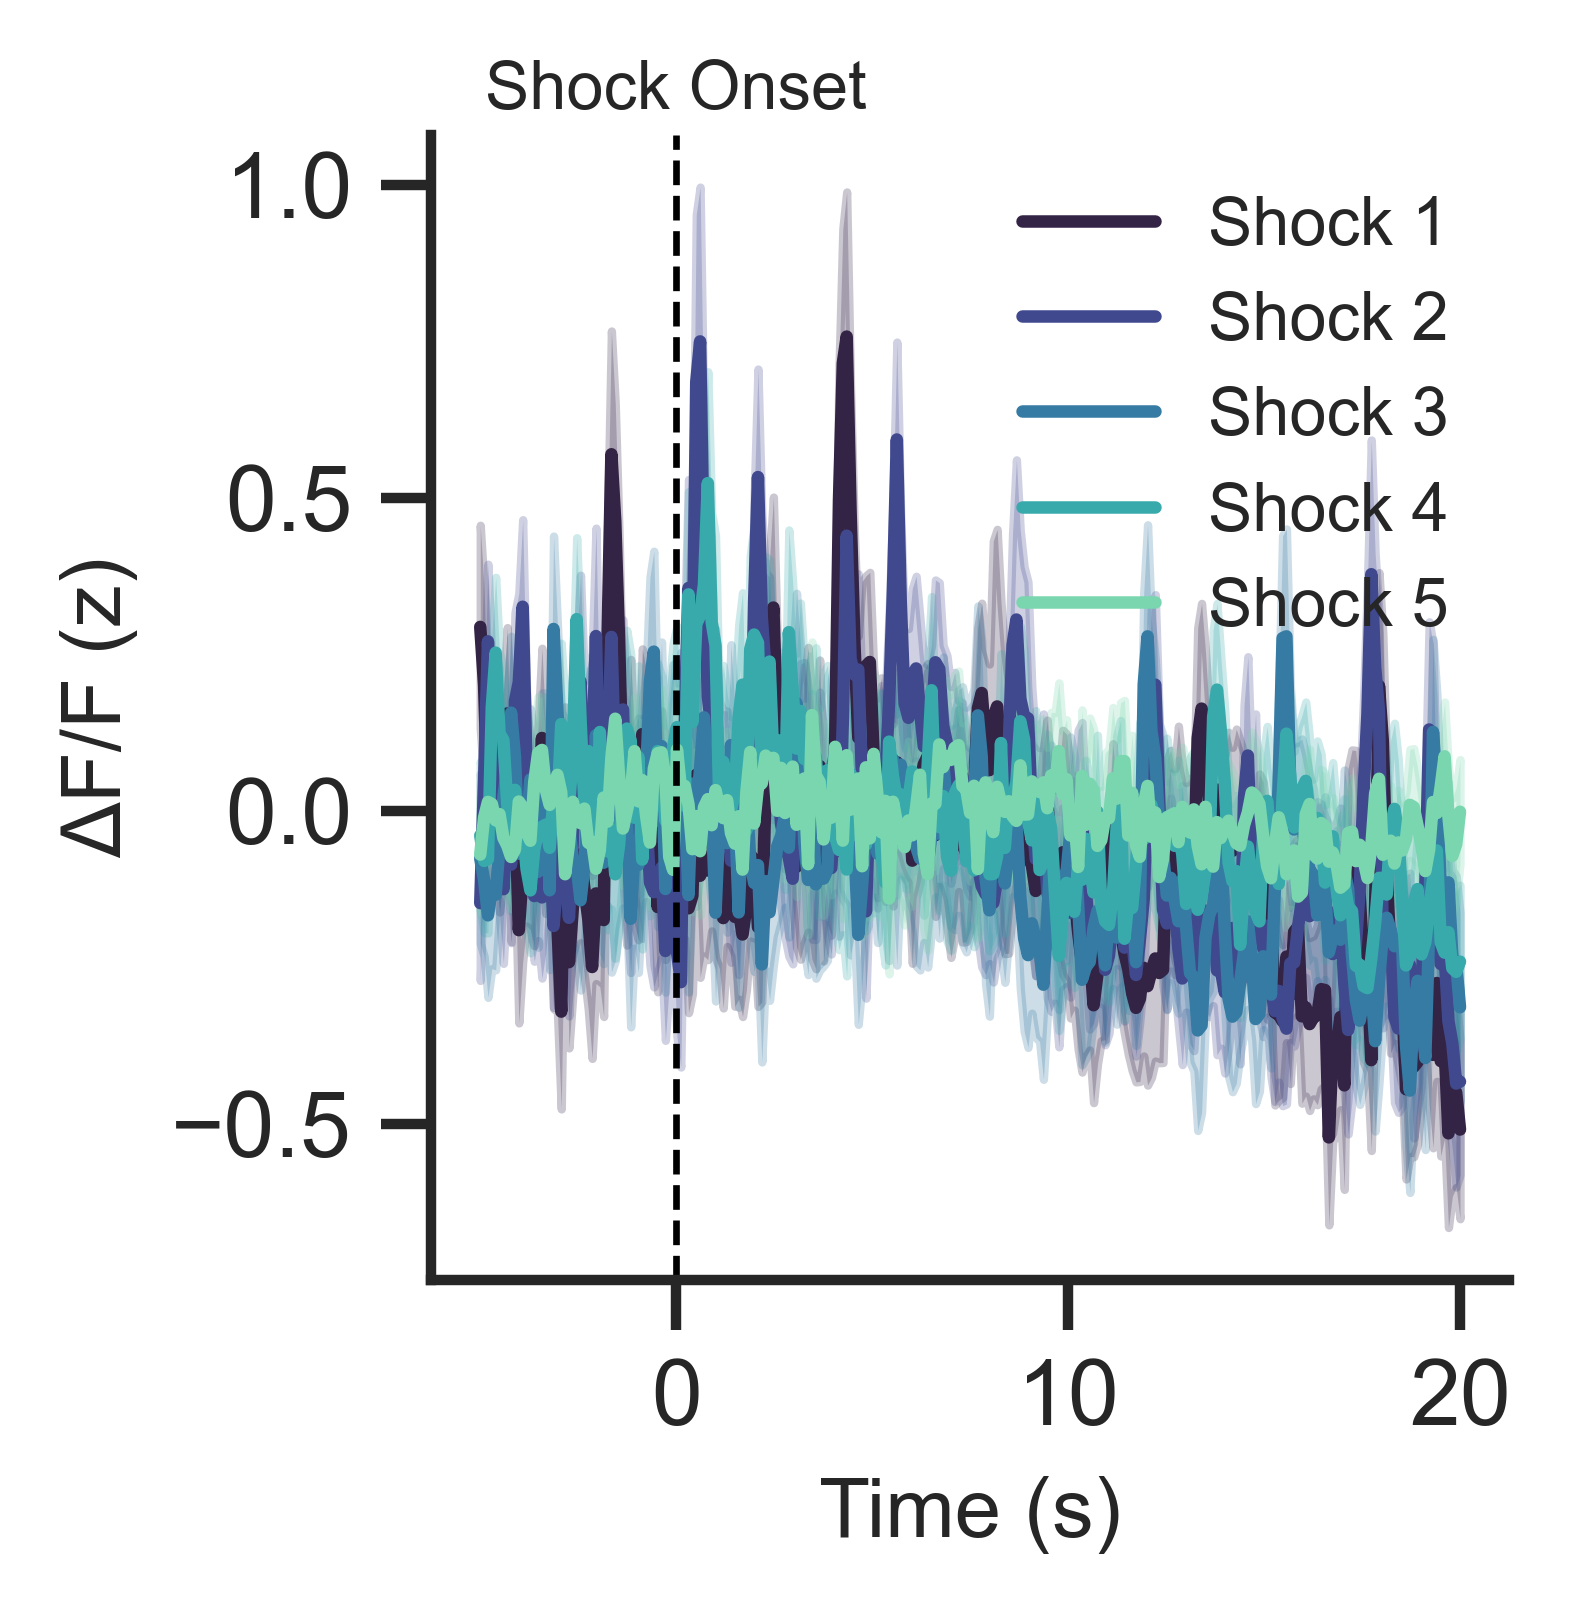

In [500]:

# shock_event_sets = [
#     [214.656863],
#     [428.970588],
#     [643.578431],
#      [857.578431]
# ]

shock_event_sets = [[ 213.62745098],  [427.94117647],  [642.15686275],  [856.37254902],
       [1071.07843137]]

#tone_event_sets = [[173.62745098],  [387.94117647],  [602.15686275],  [816.37254902],
       #[1031.07843137]]

tone_event_sets = [[193.62745098],  [407.94117647],  [622.15686275],  [836.37254902],
       [1051.07843137]]

# Define colors for each block
colors = sns.color_palette("mako", n_colors=len(tone_event_sets))

# Create one figure for all
plt.rcParams.update({'font.size': 8})
sns.set(style="ticks", font="Arial")
fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)

# Loop through each set
for i, (tone_times, color) in enumerate(zip(tone_event_sets, colors), start=1):
    t_rel, mean_trace, (lo, hi), sig_runs, _ = eta_all(
        dFF_norm, time, tone_times,
        window_pre=5.0, window_post=20.0,
        ci='tci', sig_duration=2.0
    )

    # Plot mean ± CI
    ax.plot(t_rel, mean_trace, color=color, lw=1.5, label=f'Shock {i}')
    ax.fill_between(t_rel, lo, hi, color=color, alpha=0.25)

# --- Formatting ---
ax.axvline(0, color='black', linestyle='--', lw=0.8)
ax.text(0, ax.get_ylim()[1]*1.02, 'Shock Onset', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Time (s)', fontsize=10)
ax.set_ylabel(r'ΔF/F (z)', fontsize=10)
ax.legend(frameon=False, fontsize=8)
sns.despine(ax=ax)
plt.tight_layout(pad=3)
fig.savefig("/Users/suthardr/Desktop/Sinai/neuron_delay_each_dFFZ_20s.svg")
plt.show()


In [501]:
import numpy as np
import scipy.stats as stats

def compute_per_event_windows(
    traces, timestamps, events, window_pre=5.0, window_post=10.0, interp_kind="linear"
):
    """
    Return per-cell, per-event windows (baseline NOT removed yet):
    list of arrays: per_cell_events[i] -> shape (#events_i x T_rel)
    also returns t_rel (shared across cells).
    """
    # Ensure (N x T)
    if traces.shape[0] == timestamps.shape[0]:   # (T x N)
        data = traces.T
    elif traces.shape[1] == timestamps.shape[0]: # (N x T)
        data = traces
    else:
        raise ValueError("One dimension of `traces` must match len(timestamps).")

    # events as per-cell lists or shared list
    n_cells = data.shape[0]
    if isinstance(events, (list, np.ndarray)) and len(events) > 0 and not isinstance(events[0], (list, np.ndarray)):
        per_cell_events = [np.asarray(events, float)] * n_cells
    else:
        if len(events) != n_cells:
            raise ValueError("Per-cell events provided but length != #cells.")
        per_cell_events = [np.asarray(ev, float) for ev in events]

    dt = np.median(np.diff(timestamps))
    n_points = int(round((window_pre + window_post) / dt))
    t_rel = np.linspace(-window_pre, window_post, n_points)

    from scipy.interpolate import interp1d
    per_cell_windows = []
    for sig, evs in zip(data, per_cell_events):
        f = interp1d(timestamps, sig, kind=interp_kind, bounds_error=False, fill_value="extrapolate")
        cell_chunks = []
        for e in evs:
            t_win = e + t_rel
            if t_win[0] < timestamps[0] or t_win[-1] > timestamps[-1]:
                continue
            cell_chunks.append(f(t_win))
        per_cell_windows.append(np.vstack(cell_chunks) if len(cell_chunks) else np.empty((0, n_points)))
    return t_rel, per_cell_windows


def filter_responsive_cells(
    dFF, timestamps, events,
    method="z",                 # "z" or "ttest"
    window_pre=5.0, window_post=10.0,
    baseline_window=(-5.0, -3.0),
    response_window=(0.0, 5.0),
    z_threshold=2.0,           # for method="z"
    p_threshold=0.05,          # for method="ttest" (before FDR)
    fdr_q=0.05,                # FDR target
    min_duration_s=0.0         # optional: require response above threshold for >= this duration (z method)
):
    """
    Returns:
      responsive_idx: np.array of selected cell indices
      metrics: dict with per-cell metrics (peak_z, p_value, etc.)
    """
    t_rel, per_cell_windows = compute_per_event_windows(
        dFF, timestamps, events, window_pre=window_pre, window_post=window_post
    )
    # indices for baseline/response windows
    bi = np.where((t_rel >= baseline_window[0]) & (t_rel <= baseline_window[1]))[0]
    ri = np.where((t_rel >= response_window[0]) & (t_rel <= response_window[1]))[0]
    if bi.size == 0 or ri.size == 0:
        raise ValueError("Baseline/response windows must contain samples.")

    # Compute per-cell Z across events (baseline-correct each event)
    peak_z_list = []
    dur_pass_list = []
    pvals = []

    for chunks in per_cell_windows:
        if chunks.size == 0:
            peak_z_list.append(np.nan)
            dur_pass_list.append(False)
            pvals.append(1.0)
            continue

        # baseline-correct each event by its own baseline mean
        base = chunks[:, bi].mean(axis=1, keepdims=True)
        chunks_bc = chunks - base

        # --- z method: compute per-cell mean response and z-score across timepoints (per event mean first)
        # Average across events to get ETA for this cell
        eta = chunks_bc.mean(axis=0)

        # Z-score eta within the cell (relative to its own mean/std across ALL t_rel)
        # or use baseline std only (often better). We'll use baseline std:
        mu_b = eta[bi].mean()
        sd_b = eta[bi].std(ddof=1) if bi.size > 1 else np.nan
        if not np.isfinite(sd_b) or sd_b == 0:
            z_eta = np.zeros_like(eta)
        else:
            z_eta = (eta - mu_b) / sd_b

        # Peak z & optional duration criterion within response window
        z_resp = z_eta[ri]
        peak_z = np.nanmax(z_resp) if z_resp.size else np.nan
        peak_z_list.append(peak_z)

        if min_duration_s > 0 and np.isfinite(peak_z):
            dt = np.median(np.diff(t_rel))
            min_len = max(1, int(round(min_duration_s / dt)))
            above = z_resp >= z_threshold
            # run-length check
            run_ok = False
            run = 0
            for v in above:
                run = run + 1 if v else 0
                if run >= min_len:
                    run_ok = True
                    break
            dur_pass_list.append(run_ok)
        else:
            dur_pass_list.append(True)

        # --- t-test method: pool samples from baseline vs response across events (per event, per time sample)
        # Flatten across events and time bins in each window
        base_samples = chunks_bc[:, bi].reshape(-1)
        resp_samples = chunks_bc[:, ri].reshape(-1)
        if base_samples.size > 1 and resp_samples.size > 1:
            tt = stats.ttest_ind(resp_samples, base_samples, equal_var=False)
            pvals.append(tt.pvalue if np.isfinite(tt.pvalue) else 1.0)
        else:
            pvals.append(1.0)

    peak_z_arr = np.asarray(peak_z_list)
    pvals = np.asarray(pvals)

    # FDR correction for t-test
    def fdr_bh(p, q):
        p = np.asarray(p)
        m = np.sum(~np.isnan(p))
        order = np.argsort(p)
        ranks = np.empty_like(order)
        ranks[order] = np.arange(1, len(p)+1)
        thresh = q * ranks / m
        passed = p <= thresh
        # ensure monotonicity
        if not np.any(passed):
            return np.zeros_like(p, dtype=bool)
        kmax = np.max(np.where(passed))
        return p <= thresh[kmax]

    metrics = {"peak_z": peak_z_arr, "p_value": pvals}

    if method == "z":
        pass_mask = (peak_z_arr >= z_threshold) & np.asarray(dur_pass_list)
    elif method == "ttest":
        # FDR on pvals
        ok = np.isfinite(pvals)
        fdr_mask = np.zeros_like(pvals, dtype=bool)
        if ok.any():
            fdr_mask[ok] = fdr_bh(pvals[ok], fdr_q)
        pass_mask = fdr_mask & np.isfinite(pvals)
    else:
        raise ValueError("method must be 'z' or 'ttest'")

    responsive_idx = np.where(pass_mask)[0]
    return responsive_idx, metrics, (t_rel, per_cell_windows)


In [502]:

# Filter using z-threshold (peak z ≥ 2 in 0–5 s; require ≥0.5 s above threshold)
idx_z, metrics_z, _ = filter_responsive_cells(
    dFF, time, shock_times,
    method="z",
    window_pre=5.0, window_post=15.0,
    baseline_window=(-5, -3),
    response_window=(0, 10),
    z_threshold=2.0,
    min_duration_s=0.5
)

# Or filter using t-test + FDR (q=0.05)
idx_t, metrics_t, _ = filter_responsive_cells(
    dFF, time, shock_times,
    method="ttest",
    window_pre=5.0, window_post=15.0,
    baseline_window=(-5, -3),
    response_window=(0, 10),
    p_threshold=0.05,
    fdr_q=0.05
)

print("Responsive (z):", idx_z)
print("Responsive (ttest FDR):", idx_t)


Responsive (z): [ 12  13  20  29  52  57  74  76  80  83 104 108 111 145 156]
Responsive (ttest FDR): [  0   1   2  12  13  16  20  26  29  38  45  47  52  57  61  74  76  80
  93  98 104 115 117 141 142 145 153 158]


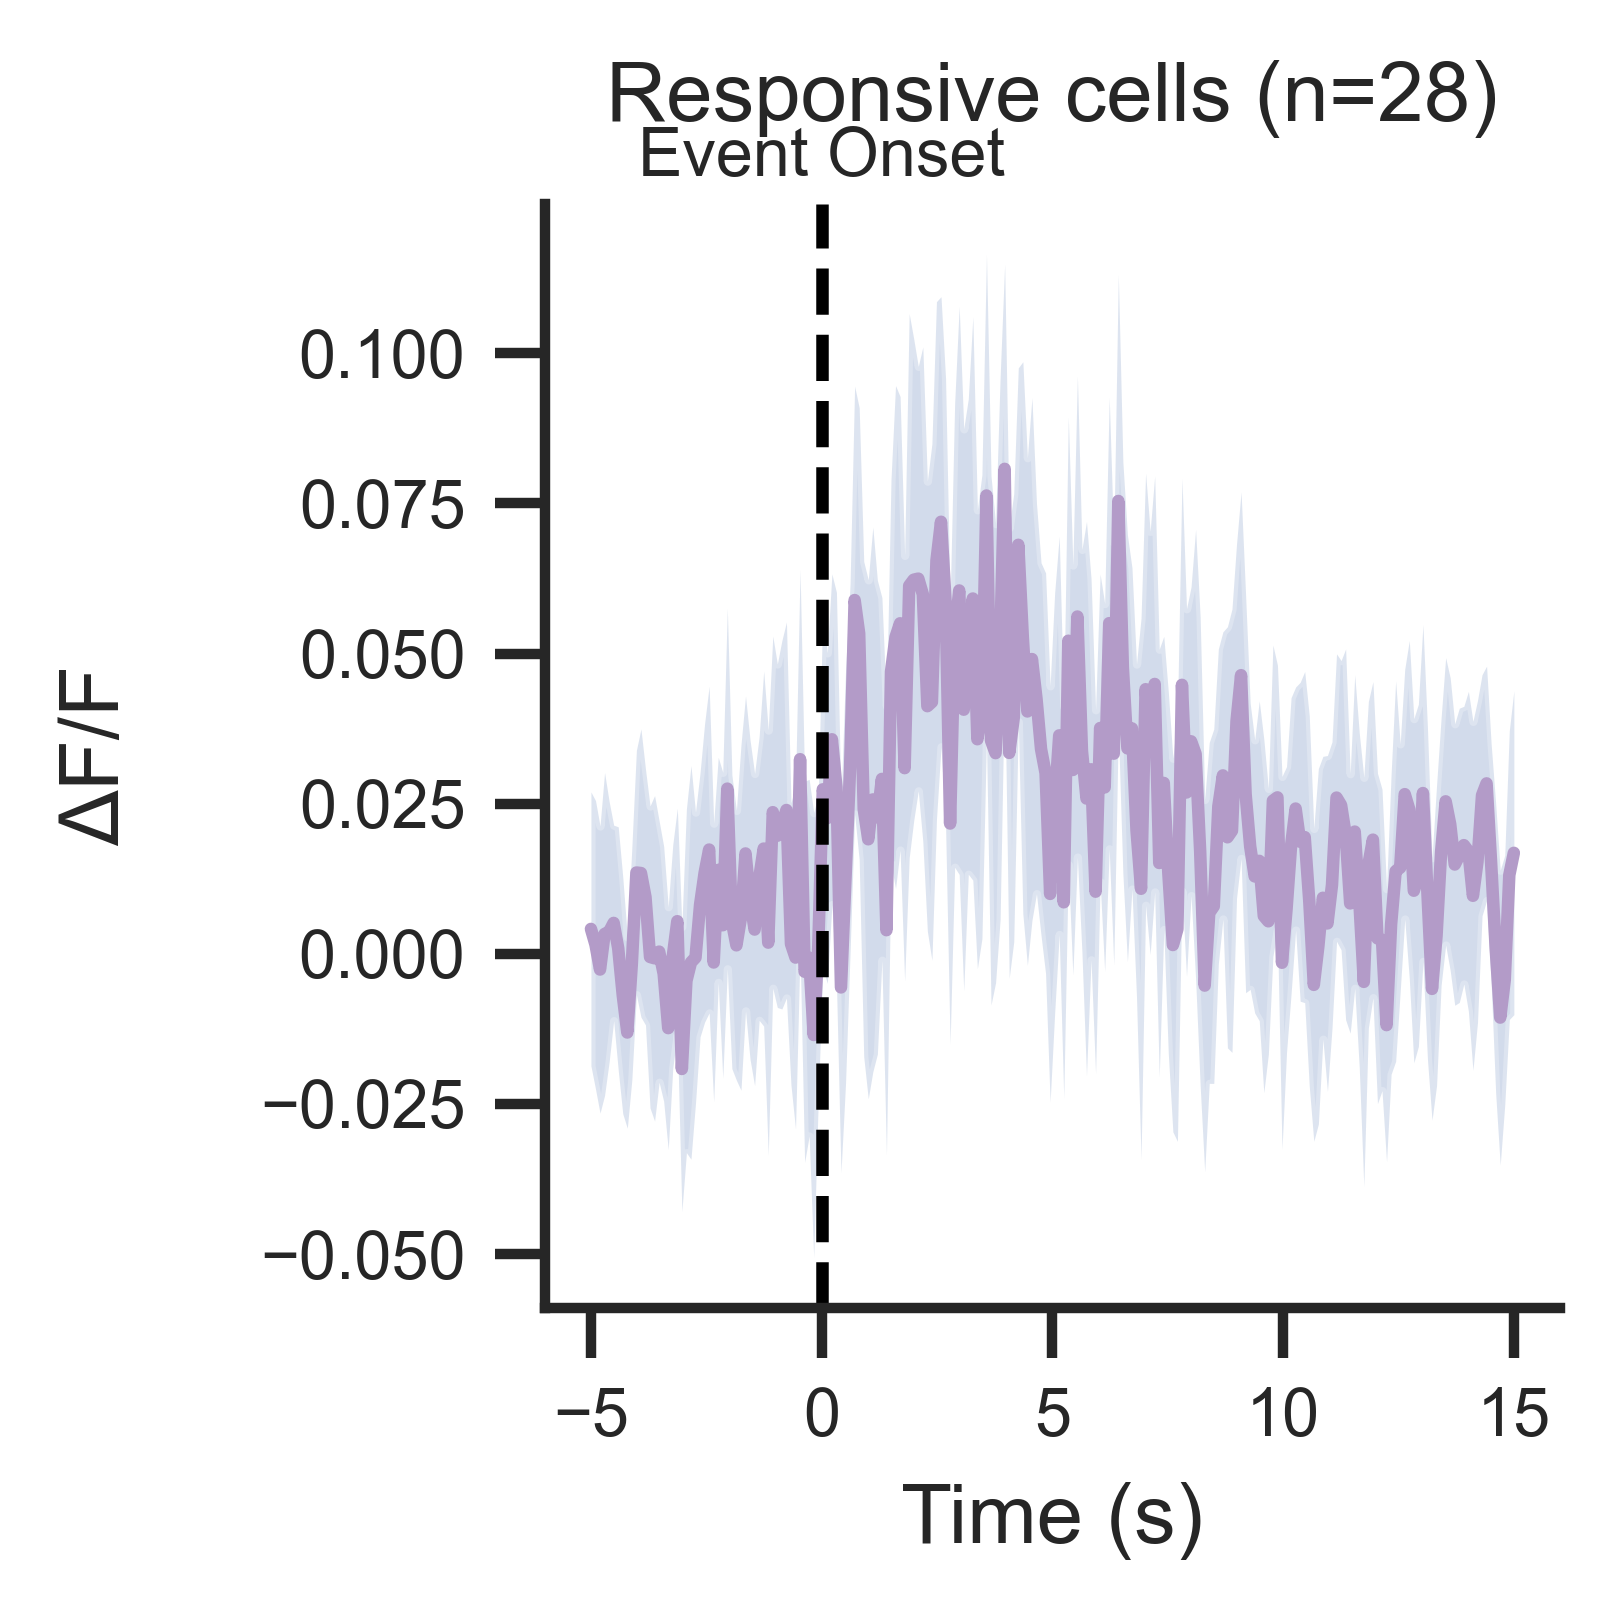

In [505]:
# Example: plot ETA of only z-responsive cells for these events
subset = dFF[:, idx_t] if dFF.shape[0] == len(time) else dFF[idx_t, :]
fig, ax, _ = plot_eta_all(
    subset, time, shock_times,
    window_pre=5.0, window_post=15.0,
    ci='tci', sig_duration=10.0,
    title=f"Responsive cells (n={len(idx_t)})"
)


2025-11-05 14:05:43,052 [INFO] normalizing data across axis=1
2025-11-05 14:05:43,068 [INFO] projecting out mean along axis=0
2025-11-05 14:05:43,081 [INFO] data normalized, 0.03sec
2025-11-05 14:05:43,082 [INFO] sorting activity: 166 valid samples by 13114 timepoints
2025-11-05 14:05:47,200 [INFO] n_PCs = 166 computed, 4.15sec
2025-11-05 14:05:47,449 [INFO] 78 clusters computed, time 4.40sec


/Users/suthardr/Documents/GitHub/CalciumKit/venv/lib/python3.9/site-packages/rastermap/cluster.py:138: UserWarning: found fewer than half the n_clusters that the user specified, rerunning with random initialization
  warnings.warn(
/Users/suthardr/Documents/GitHub/CalciumKit/venv/lib/python3.9/site-packages/rastermap/cluster.py:148: UserWarning: found fewer clusters than user specified, try reducing n_clusters and/or reduce n_splits and/or increase n_PCs
  warnings.warn(


2025-11-05 14:05:51,935 [INFO] clusters sorted, time 8.88sec
2025-11-05 14:05:51,981 [INFO] clusters upsampled, time 8.93sec
2025-11-05 14:05:52,001 [INFO] rastermap complete, time 8.95sec


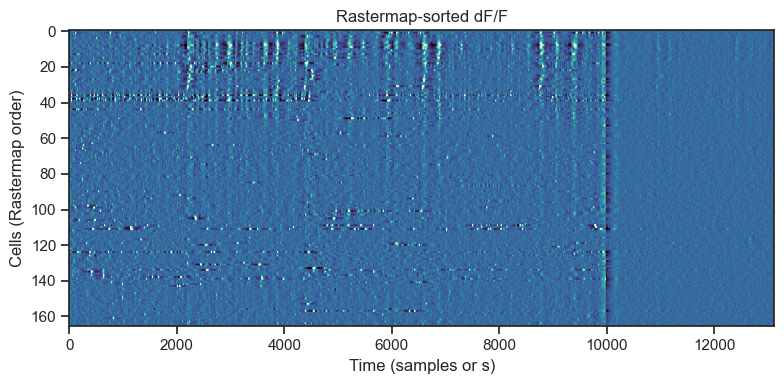

In [506]:
import numpy as np
import inspect
from rastermap import Rastermap
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

def make_rastermap(**prefs):
    """
    Create a Rastermap model compatible with multiple versions.
    You can override defaults via **prefs.
    """
    # Discover accepted parameters on this install
    sig = inspect.signature(Rastermap)
    have = set(sig.parameters.keys())

    # Three known families of signatures (choose first that fits)
    if {"n_clusters", "n_PCs", "locality", "time_lag_window"}.issubset(have):
        kwargs = dict(n_clusters=100, n_PCs=200, locality=0.2,
                      time_lag_window=0, grid_upsample=10)
    elif {"n_X", "alpha", "n_PCs"}.issubset(have):
        kwargs = dict(n_X=100, alpha=1.0, n_PCs=200, timelag=0)
    elif {"n_components", "n_neighbors", "n_pcs"}.issubset(have):
        kwargs = dict(n_components=1, n_neighbors=200, n_pcs=100,
                      n_epochs=500, learning_rate=1.0, random_state=0)
    else:
        # Fall back to no-arg init; user can pass prefs explicitly
        kwargs = {}

    # Allow user overrides
    kwargs.update(prefs)
    return Rastermap(**kwargs)

# --- Use Rastermap to find data-driven events, then plot ETA with your function ---
# Ensure data is (cells x time)
data_ct = dFF.T if dFF.shape[0] == len(time) else dFF

# 1) Fit Rastermap with the compatible signature for your install
rm = make_rastermap()
rm.fit(data_ct)

# 2) Reorder cells by the 1D embedding
order = np.argsort(rm.embedding[:, 0]) if rm.embedding.ndim == 2 else np.argsort(rm.embedding)
data_sorted = data_ct[order]

# Optional: visualize reordered raster
plt.figure(figsize=(8, 4))
vmin, vmax = np.percentile(data_sorted, [1, 99])
plt.imshow(data_sorted, aspect='auto', cmap='mako', vmin=vmin, vmax=vmax)
plt.xlabel('Time (samples or s)')
plt.ylabel('Cells (Rastermap order)')
plt.title('Rastermap-sorted dF/F')
plt.tight_layout()
plt.show()


Indices of first 40 Rastermap-sorted cells:
[110 113 121 117 125 106  29 156  74  20  13 105  12  34  97 145  72 102
  93  90  99  15  81  60 101  57 104  38  55  54  62  80  52 158 151 153
 140 144  31 163]


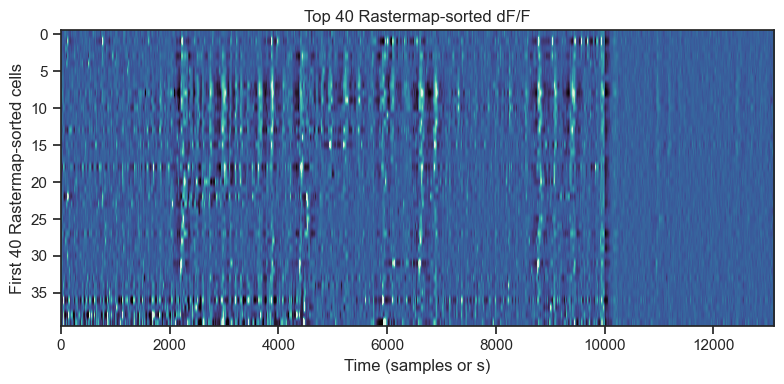

In [507]:
# 2) Reorder cells by the 1D embedding
order = np.argsort(rm.embedding[:, 0]) if rm.embedding.ndim == 2 else np.argsort(rm.embedding)
data_sorted = data_ct[order]

# --- Grab the first 40 Rastermap-sorted cells ---
first40 = data_sorted[:40, :]
first40_order = order[:40]  # indices of the original cells

print(f"Indices of first 40 Rastermap-sorted cells:\n{first40_order}")

# --- Optional: visualize only those 40 ---
import matplotlib.pyplot as plt
vmin, vmax = np.percentile(first40, [1, 99])
plt.figure(figsize=(8, 4))
plt.imshow(first40, aspect='auto', cmap='mako', vmin=vmin, vmax=vmax)
plt.xlabel('Time (samples or s)')
plt.ylabel('First 40 Rastermap-sorted cells')
plt.title('Top 40 Rastermap-sorted dF/F')
plt.tight_layout()
plt.show()


(40, 204)


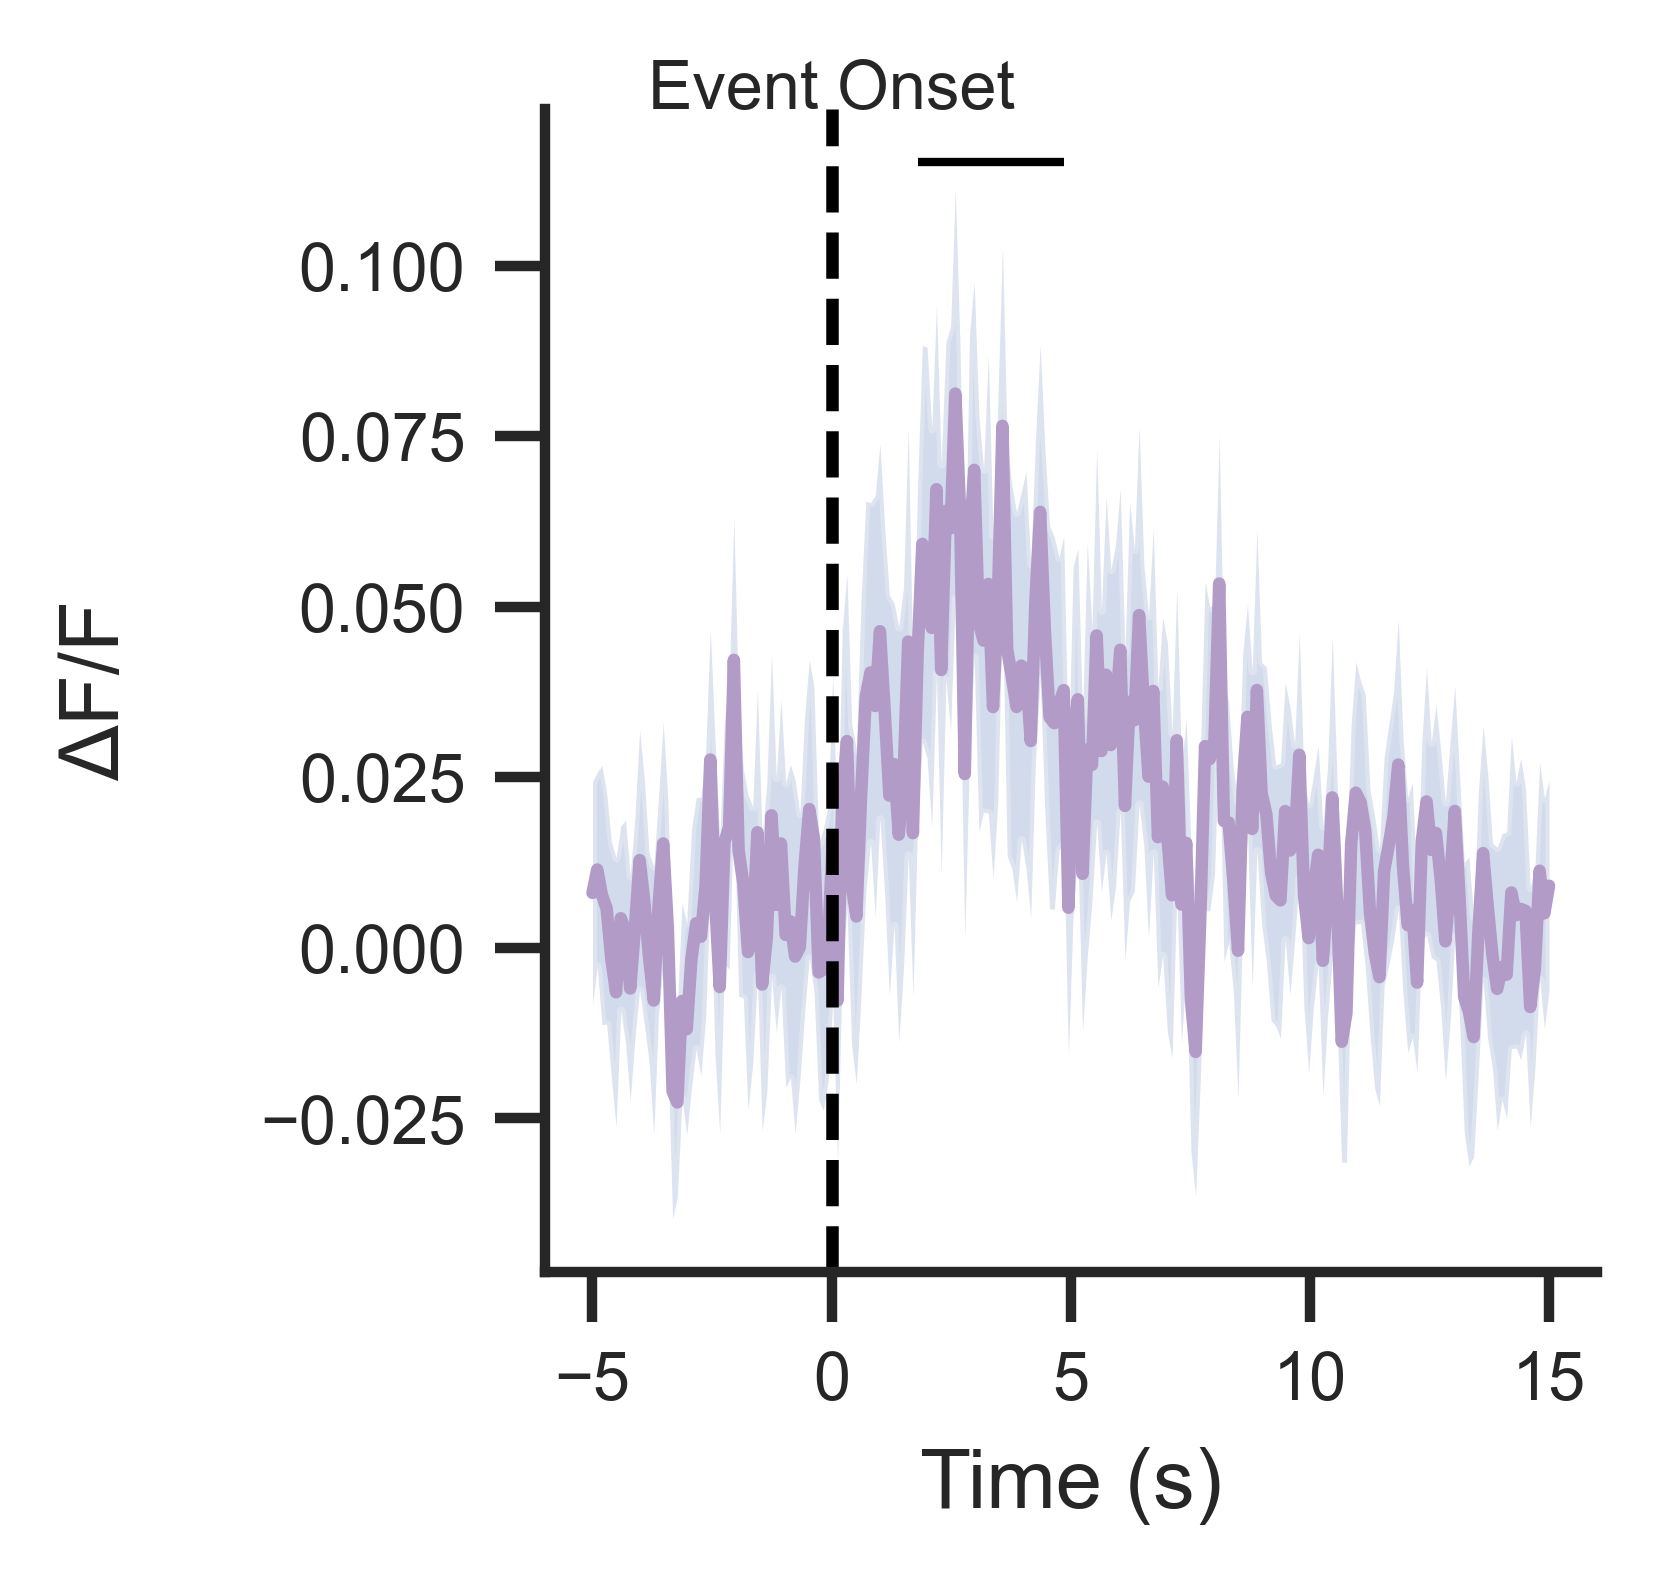

In [508]:
subset_dFF = dFF[:, first40_order] if dFF.shape[0] == len(time) else dFF[first40_order, :]
# Call the function and unpack all returned outputs
fig, ax, (t_rel, mean_trace, ci_bounds, sig_runs, across_eta_per_cell) = plot_eta_all(
    subset_dFF,
    time,
    events=shock_times,
    window_pre=5.0,
    window_post=15.0,
    ci='tci',
    sig_duration=1.0
    #save_path='/Users/suthardr/Desktop/eta_all.svg'
)

# Now you can access the per-cell data directly
print(across_eta_per_cell.shape)



IndexError: index 20 is out of bounds for axis 0 with size 20

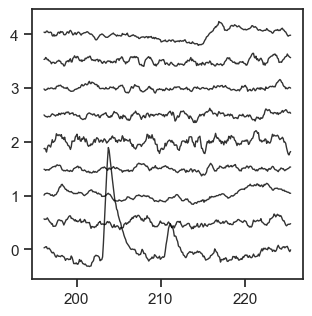

In [360]:
import numpy as np

def smooth(y, window=5):
    return np.convolve(y, np.ones(window)/window, mode='same')

offset = 0.5
fig, ax = plt.subplots(figsize=(3.5, 3.5))

cells_to_plot = [0, 1, 2, 3, 4, 5, 9, 12, 18, 20]
for j, i in enumerate(cells_to_plot):
    y = smooth(subset_dFF[i, 2000:2300], window=7)  # ← adjust window for smoothness
    ax.plot(time[2000:2300], y + j * offset, color='black', alpha=0.8, linewidth=1)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Cell #')
plt.tight_layout()
plt.show()



In [655]:
def maxsort(arr):
    """Sort rows by the argmax of each row (ties keep numpy's default stability)."""
    return arr[np.argsort(np.argmax(arr, axis=1))]

def run_post_event_heatmap(
        traces,  # (T x N) or (N x T)
        timestamps,  # (T,) seconds, strictly increasing
        events,  # flat list/1D array of event times (seconds)
        save_path_prefix=None,
        window=15,  # seconds AFTER event onset
        vmin=-4, vmax=4,
        # --- new optional args (all default off) ---
        return_data=False,            # return z, idx_keep, order_used, t_rel
        row_order=None,               # ordering (indices) computed on a REF split
        ref_idx=None,                 # cell indices (original) used to define row_order
        title=None,                   # optional panel title
        ax=None                       # optional Matplotlib Axes to draw into
):
    # --- checks ---
    events = np.asarray(events, dtype=float).ravel()
    if events.size == 0:
        raise ValueError("`events` is empty. Provide at least one event time.")
    if timestamps.ndim != 1:
        raise ValueError("`timestamps` must be 1D.")
    if np.any(np.diff(timestamps) <= 0):
        raise ValueError("`timestamps` must be strictly increasing.")
    if traces.ndim != 2:
        raise ValueError("`traces` must be 2D (T x N) or (N x T).")

    # Ensure data is (N_cells x T)
    data_for_eta = traces.T if traces.shape[0] == timestamps.shape[0] else traces
    fs = 1.0 / np.median(np.diff(timestamps))
    n_points = int(window * fs)
    if n_points < 2:
        n_points = 2  # avoid degenerate interpolation
    t_rel = np.linspace(0, window, n_points)

    def event_window(signal, e):
        t_win = e + t_rel
        # only keep windows fully inside recording
        if t_win[-1] > timestamps[-1] or t_win[0] < timestamps[0]:
            return None
        return np.interp(t_win, timestamps, signal)

    # Average ETA for each cell across all valid events
    all_cells, idx_keep = [], []
    for i, sig in enumerate(data_for_eta):
        chunks = []
        for e in events:
            out = event_window(sig, e)
            if out is not None:
                chunks.append(out)
        if len(chunks):
            all_cells.append(np.mean(chunks, axis=0))
            idx_keep.append(i)
    if len(all_cells) == 0:
        raise ValueError("No valid event windows within the recording (try a smaller `window`).")

    idx_keep = np.array(idx_keep, dtype=int)
    eta_mean = np.vstack(all_cells)  # (N_valid x n_points)
    z = stats.zscore(eta_mean, axis=1, nan_policy='omit')
    z = np.nan_to_num(z, nan=0.0)

    # Determine row order
    if (row_order is None) or (ref_idx is None):
        # default: sort by this matrix's argmax
        order_used = np.argsort(np.argmax(z, axis=1))
        z_to_plot = z[order_used, :]
    else:
        # Reuse order from reference (e.g., odd) restricted to overlap
        ref_idx = np.asarray(ref_idx)
        row_order = np.asarray(row_order)

        # which original cells are common between ref split and current split?
        common_idx, ref_pos, cur_pos = np.intersect1d(ref_idx, idx_keep, return_indices=True)

        if common_idx.size == 0:
            raise ValueError("No overlapping valid cells between reference and current splits.")

        # Map: original cell index -> row position in CURRENT z
        cur_map = {cell: pos for cell, pos in zip(common_idx, cur_pos)}
        # Take the reference order, convert to original cell ids, then map to current positions, keeping only overlaps
        ref_order_cells = ref_idx[row_order]
        mapped = [cur_map[c] for c in ref_order_cells if c in cur_map]

        order_used = np.array(mapped, dtype=int)
        z_to_plot = z[order_used, :]

    # --- Plot ---
    plt.rcParams.update({'font.size': 8, 'font.family': 'Arial'})
    sns.set(style="ticks", font="Arial")

    # create fig/ax if needed
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 4.5), dpi=600)
        created_fig = True
    else:
        fig = ax.figure

    sns.heatmap(
        z_to_plot, ax=ax, cmap='mako', vmin=vmin, vmax=vmax,
        cbar=True, cbar_kws={'label': 'Z-score'},
        xticklabels=True, yticklabels=False, rasterized=True
    )

    # X-axis in seconds
    T = z_to_plot.shape[1]
    xticks = np.linspace(0, T - 1, 5).astype(int)
    xticklabels = np.linspace(0, window, 5).astype(int)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, rotation=0)

    # Y-axis: first & last row
    n_cells = z_to_plot.shape[0]
    ax.set_yticks([0, max(n_cells - 1, 0)])
    ax.set_yticklabels(['1', str(n_cells)], rotation=0)

    # event onset at 0 s (left edge)
    ax.axvline(0, linestyle='--', color='white', linewidth=1)
    ax.set_xlabel('Time after event (s)', fontsize=10)
    ax.set_ylabel('Astrocyte #', fontsize=10)
    if title:
        ax.set_title(title, fontsize=10)
    sns.despine(ax=ax, left=True, bottom=True)
    if created_fig:
        plt.tight_layout()

    out_path = None
    if save_path_prefix and created_fig:
        out_path = f"{save_path_prefix}_event_heatmap.svg"
        fig.savefig(out_path, dpi=600, bbox_inches='tight')

    if return_data:
        return fig, ax, out_path, z, idx_keep, order_used, t_rel
    return fig, ax, out_path


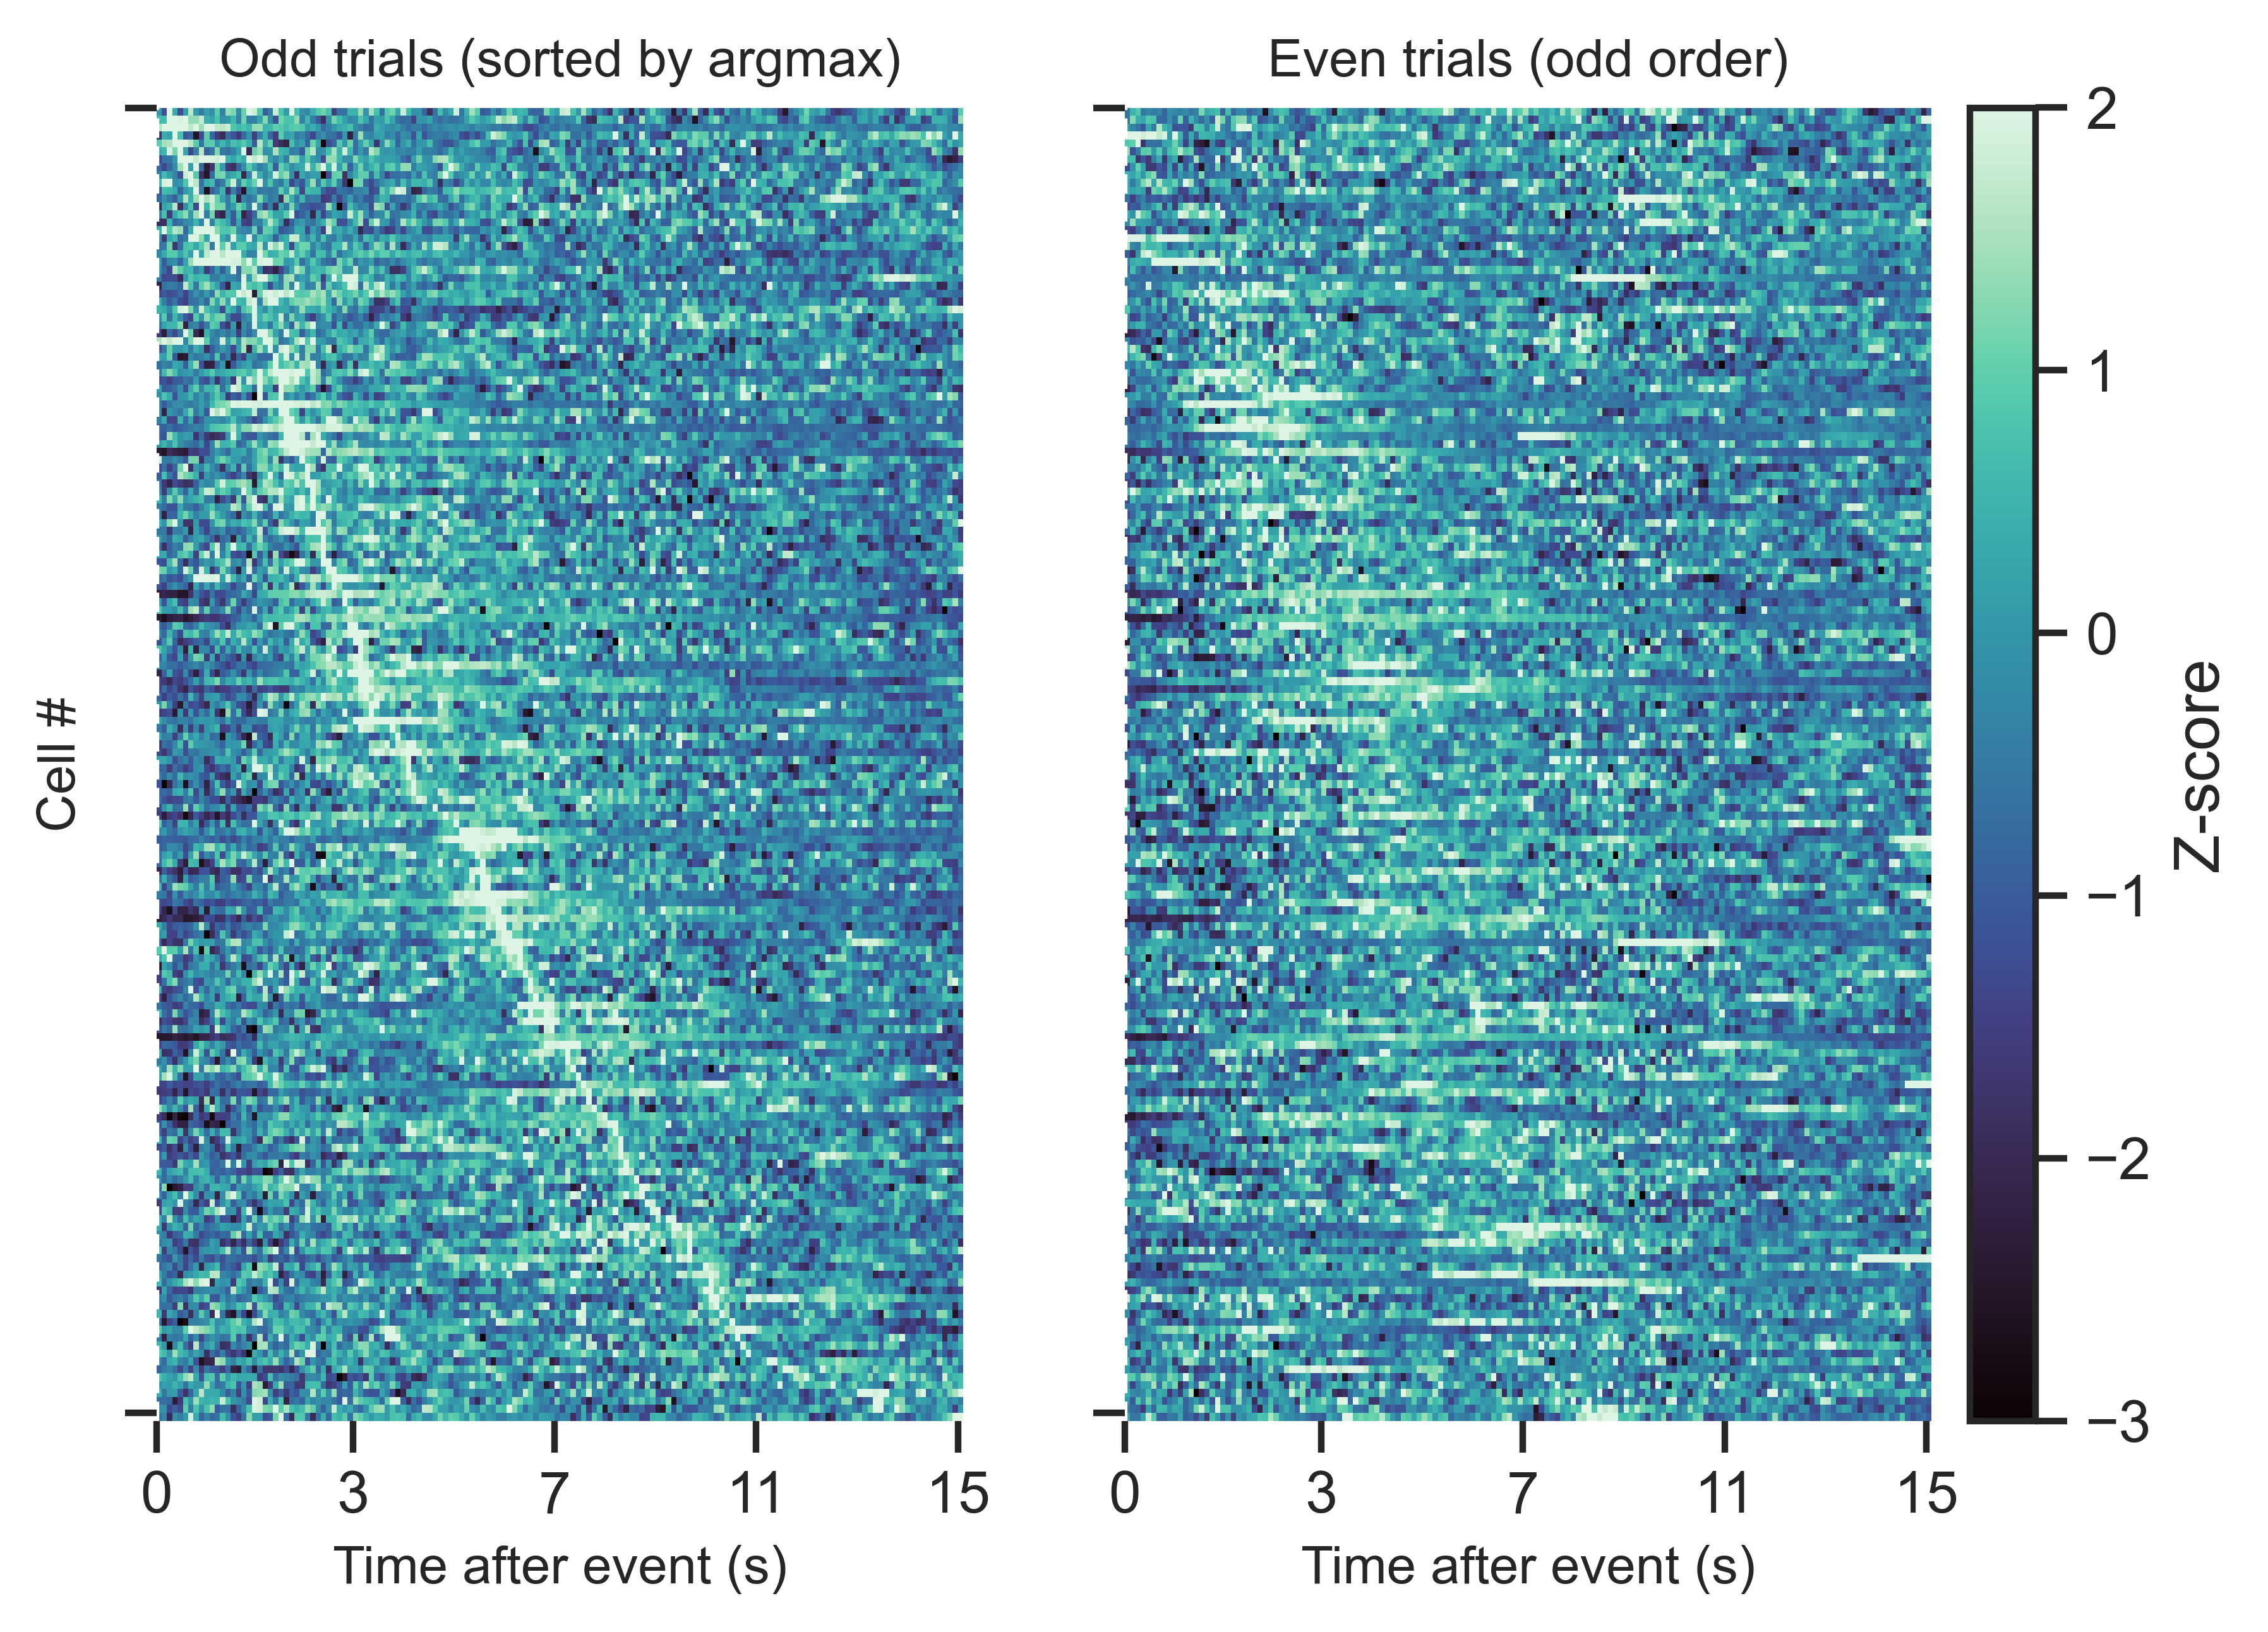

In [657]:
# --- Plot side-by-side, shared y-axis and shared colorbar ---
fig, axes = plt.subplots(1, 2, figsize=(6.5, 4.5), dpi=600, sharey=True)

# Odd: compute + plot on left
fig_odd, ax_odd, _, z_odd, idx_odd, order_odd, t_rel = run_post_event_heatmap(
    traces=dFF, timestamps=time, events=odd_times,
    window=15, vmin=-3, vmax=2,
    return_data=True,
    title="Odd trials (sorted by argmax)",
    ax=axes[0]
)

# Even: reuse odd order, plot on right
fig_even, ax_even, _ = run_post_event_heatmap(
    traces=dFF, timestamps=time, events=even_times,
    window=15, vmin=-3, vmax=2,
    row_order=order_odd, ref_idx=idx_odd,
    title="Even trials (odd order)",
    ax=axes[1]
)

# --- Adjust to share y-axis and legend ---
# Remove individual colorbars created by sns.heatmap
for ax in axes:
    ax.collections[-1].colorbar.remove()

# Create one shared colorbar across both panels
im = axes[0].collections[0]
cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.05, pad=0.02)
cbar.set_label('Z-score')

# Shared labels and tighter layout
axes[0].set_ylabel('Cell #', fontsize=10)
axes[1].set_ylabel('')
axes[1].set_yticklabels([])
axes[0].set_xlabel('Time after event (s)')
axes[1].set_xlabel('Time after event (s)')
fig.savefig("/Users/suthardr/Desktop/siria_2p_poster_figs/crossvalled/neurons_shock_crossvalled.png")
plt.show()

Spearman correlation between odd and even peak times: ρ = 0.281, p = 0.000243


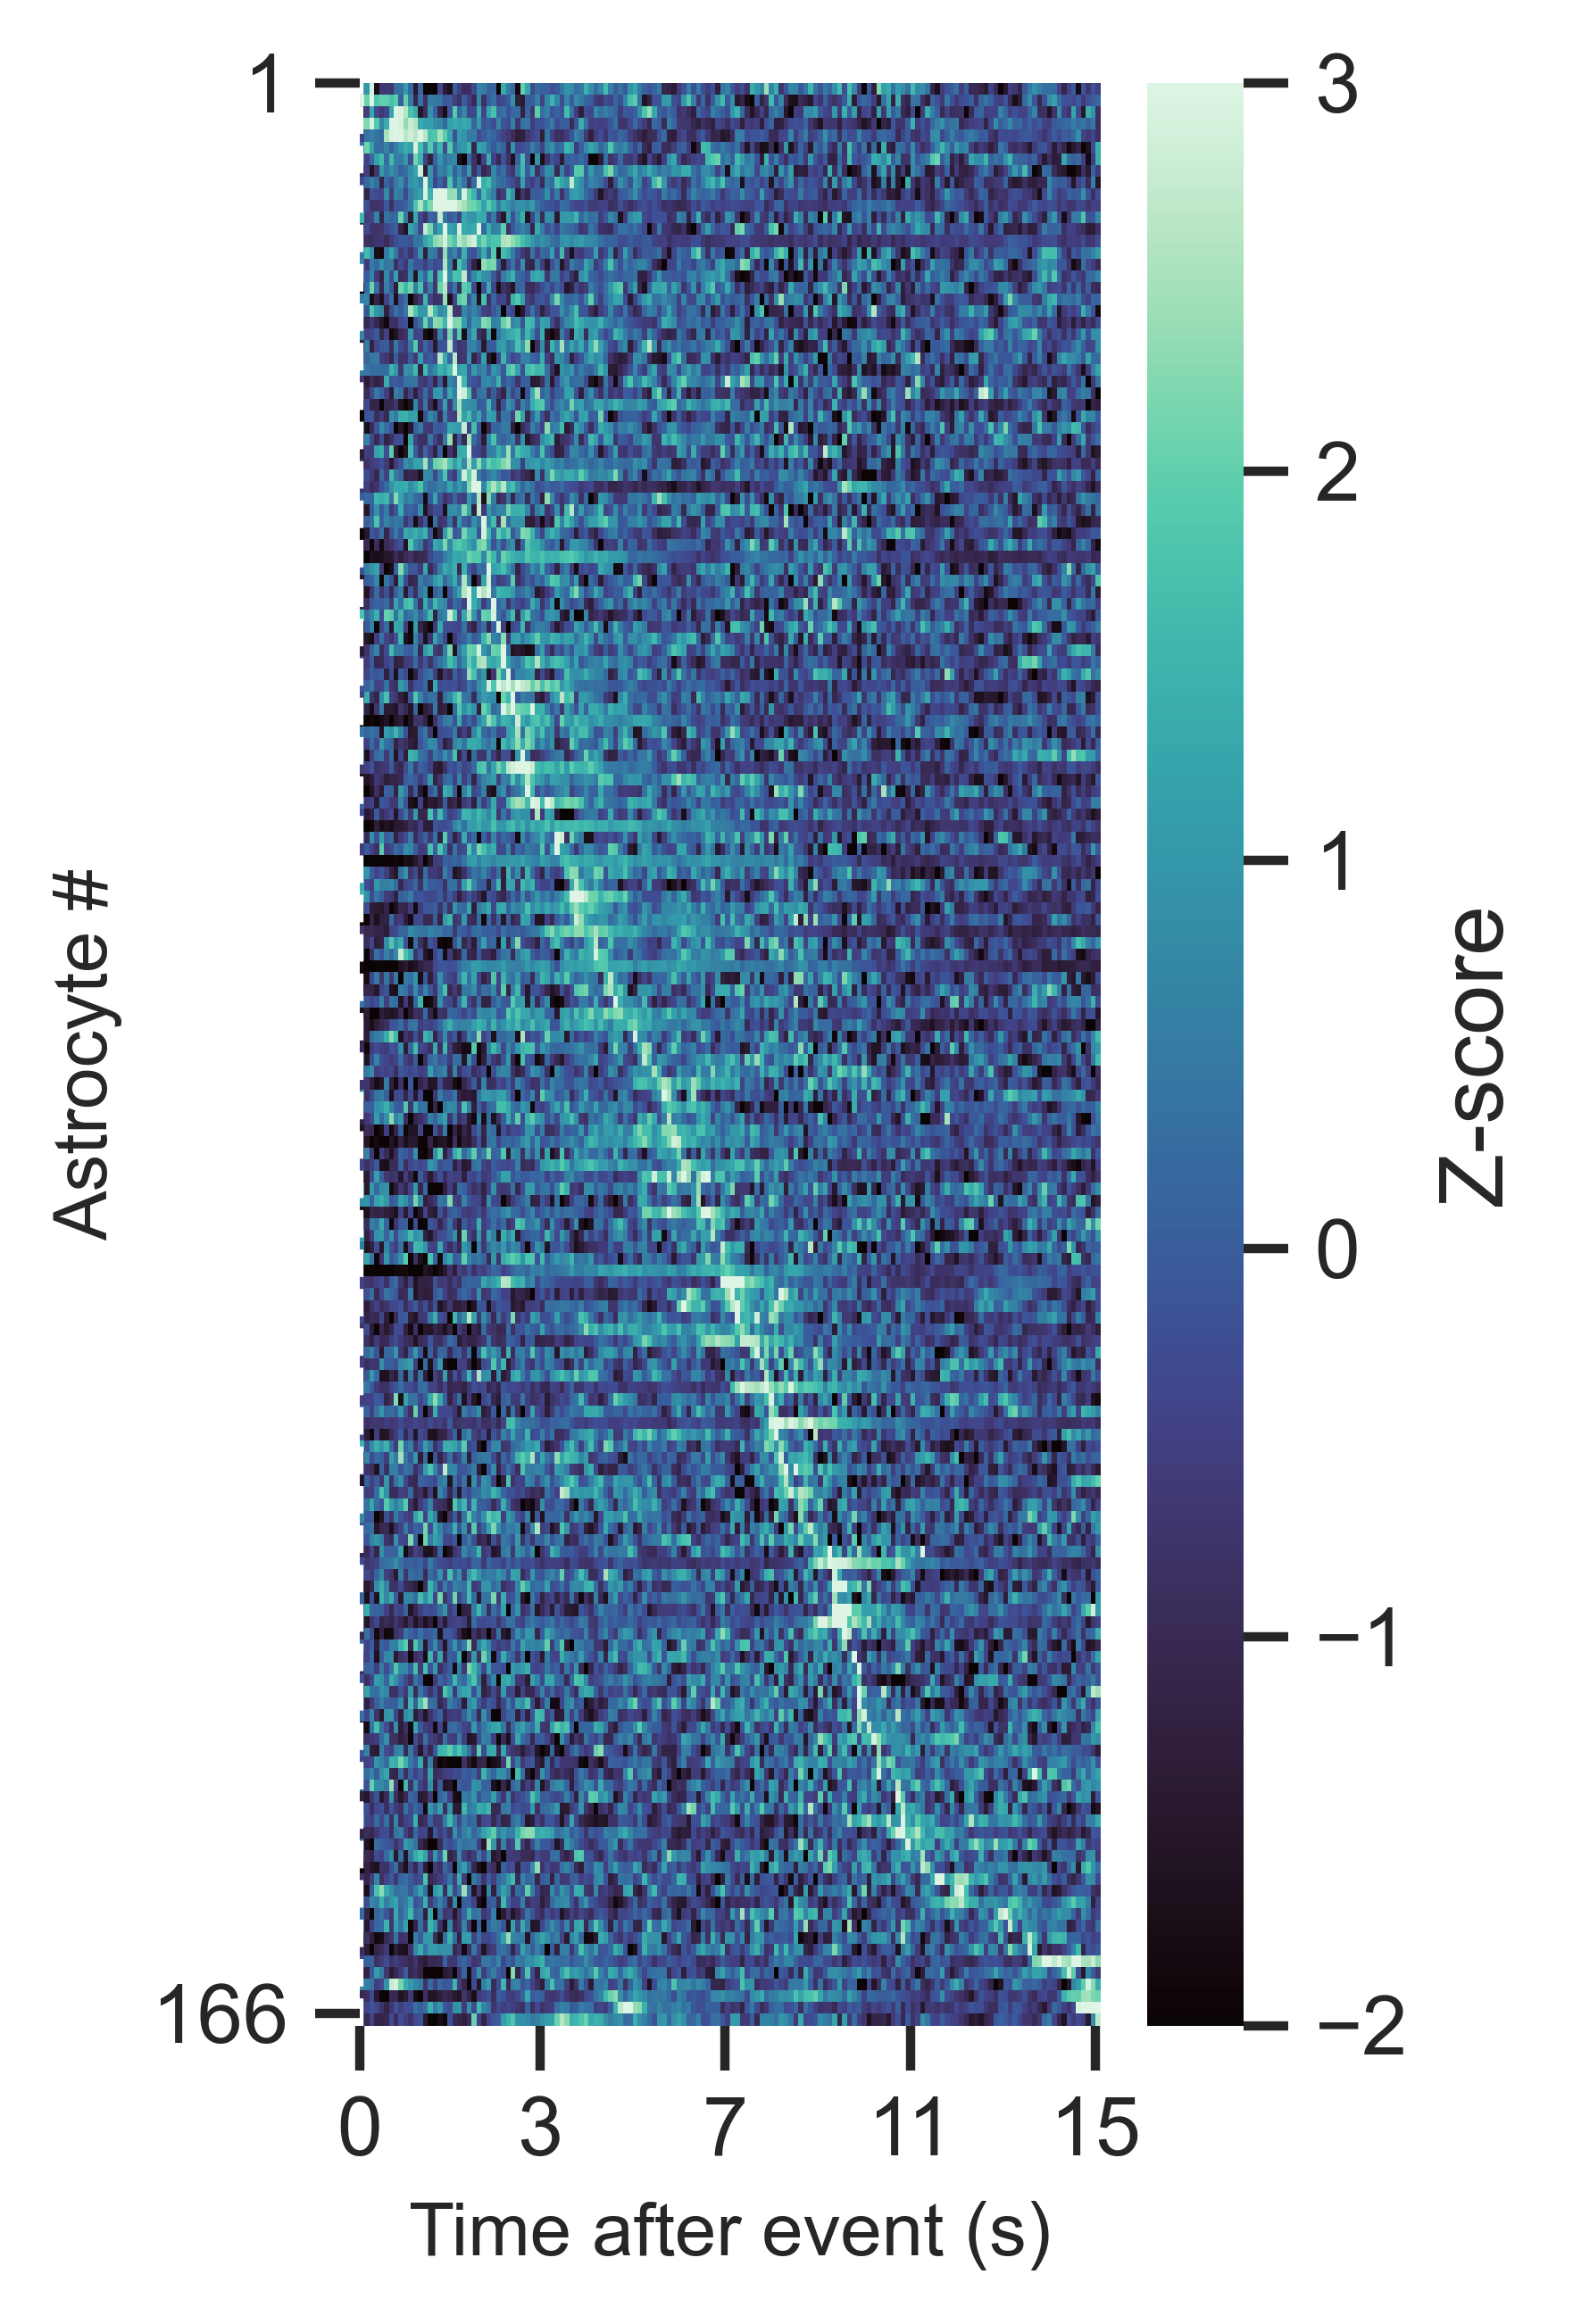

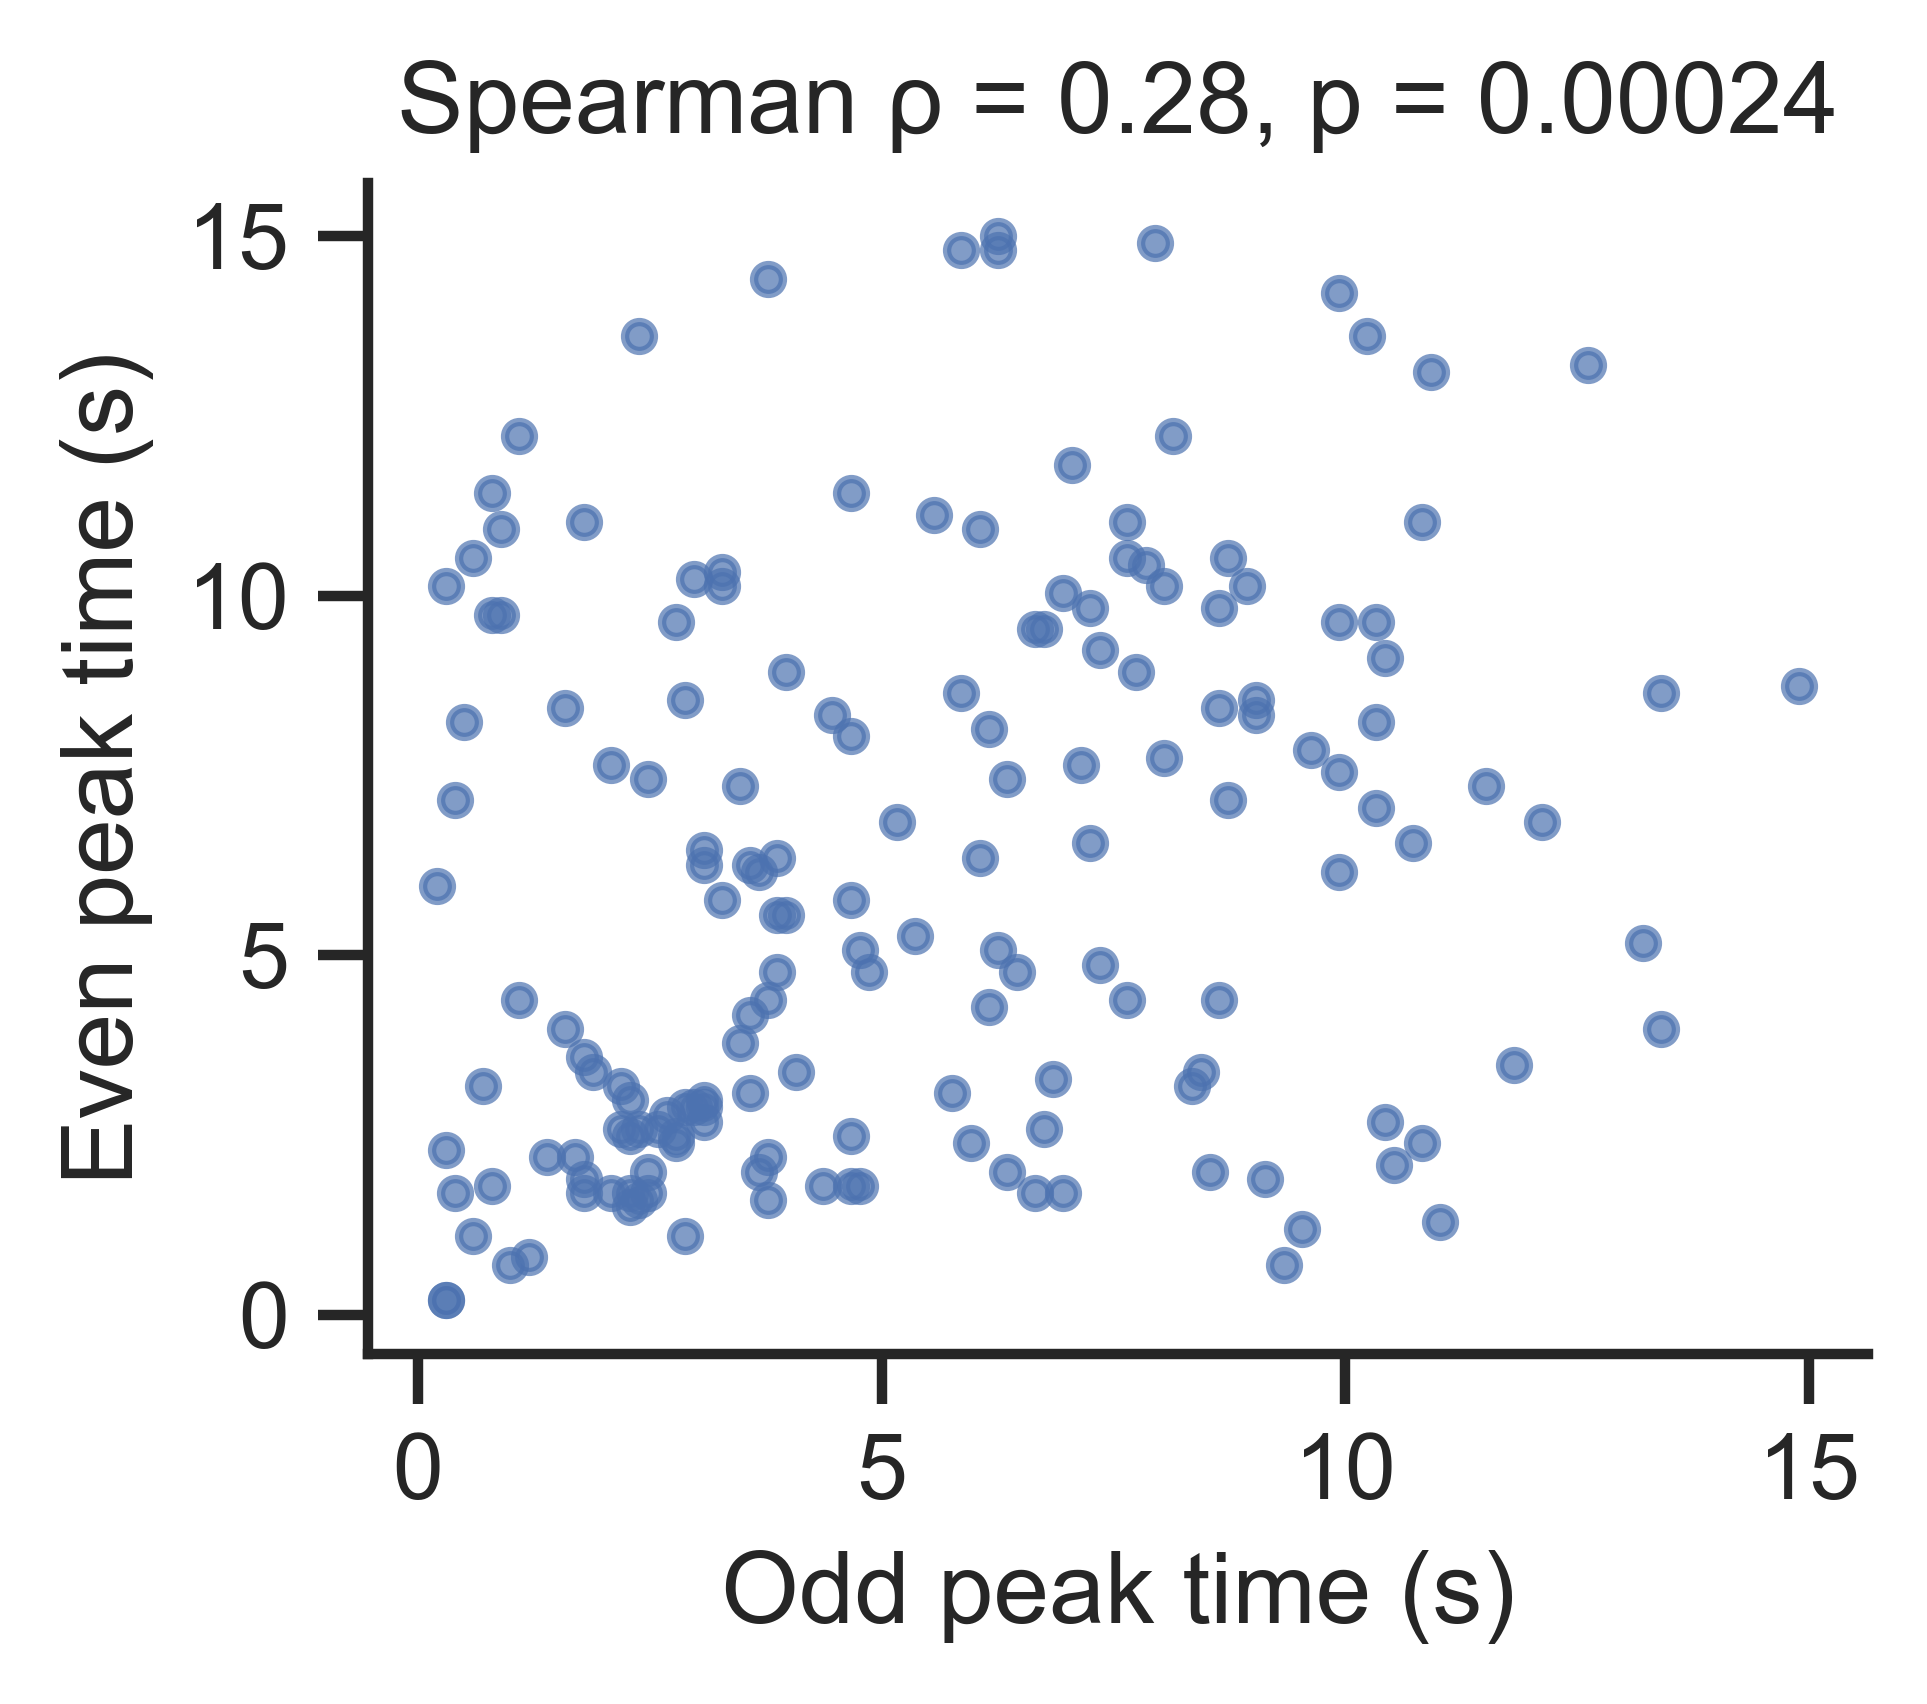

In [658]:
from scipy.stats import spearmanr

# --- Align odd and even matrices to the same cells (same ones plotted) ---
# Use data from the most recent run_post_event_heatmap calls
# z_odd, idx_odd, order_odd already came from the first call
# Let's recompute z_even to ensure we use the same overlaps:

fig_even, ax_even, _, z_even, idx_even, _, t_rel = run_post_event_heatmap(
    traces=dFF, timestamps=time, events=even_times,
    window=15, vmin=-2, vmax=3,
    return_data=True
)

# Find cells common to both conditions
common_idx, pos_odd, pos_even = np.intersect1d(idx_odd, idx_even, return_indices=True)
z_odd_common = z_odd[pos_odd, :]
z_even_common = z_even[pos_even, :]

# --- Compute argmax times (indices of peak) ---
odd_peaks_idx = np.argmax(z_odd_common, axis=1)
even_peaks_idx = np.argmax(z_even_common, axis=1)

# Convert to seconds for interpretability
odd_peaks_time = t_rel[odd_peaks_idx]
even_peaks_time = t_rel[even_peaks_idx]

# --- Spearman’s rank correlation ---
rho, pval = spearmanr(odd_peaks_time, even_peaks_time)
print(f"Spearman correlation between odd and even peak times: ρ = {rho:.3f}, p = {pval:.3g}")

# Optional quick scatter plot
plt.figure(figsize=(3.5,3), dpi=600)
plt.scatter(odd_peaks_time, even_peaks_time, s=12, alpha=0.7)
plt.xlabel("Odd peak time (s)")
plt.ylabel("Even peak time (s)")
plt.title(f"Spearman ρ = {rho:.2f}, p = {pval:.2g}")
sns.despine()
plt.tight_layout()
#plt.savefig("/Users/suthardr/Desktop/siria_2p_poster_figs/crossvalled/astros_shock_crossvalled_corr.png")
plt.show()


In [659]:
def run_cross_validated_analysis_v2(
    animal_id,
    traces,
    timestamps,
    odd_times,
    even_times,
    save_path_prefix,
    window=15.0,
    vmin=-2, vmax=3,
    do_shuffle=True,
    n_shuffles=10000,
    seed=None,
    two_sided=True
):
    """
    Reproduces the original behavior using run_post_event_heatmap:
      - Heatmaps: ODD sorted by ODD (left) ; ODD reordered by EVEN order (right)
      - Spearman: argmax(ODD_sorted_by_ODD) vs argmax(ODD_reordered_by_EVEN)
      - Optional shuffle null, RLM fit, and saved figures.
    Returns a dict with the same fields as your original function.
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy import stats
    try:
        import statsmodels.api as sm
    except Exception:
        sm = None  # handle gracefully if statsmodels isn't available

    # ---------- Helpers (same logic as original) ----------
    def shuffle_control_test(x, y, n_shuffles=1000, seed=None, two_sided=True):
        x = np.asarray(x); y = np.asarray(y)
        if x.shape[0] != y.shape[0]:
            raise ValueError(f"Length mismatch: x={x.shape[0]}, y={y.shape[0]}")
        if not np.all(np.isfinite(x)) or not np.all(np.isfinite(y)):
            raise ValueError("Non-finite values in x or y")
        rng = np.random.default_rng(seed)
        r_obs, p_obs = stats.spearmanr(x, y)
        sh = np.empty(n_shuffles, dtype=float)
        for i in range(n_shuffles):
            y_perm = rng.permutation(y)
            sh[i], _ = stats.spearmanr(x, y_perm)
        if two_sided:
            p_emp = (np.sum(np.abs(sh) >= abs(r_obs)) + 1) / (n_shuffles + 1)
        else:
            p_emp = (np.sum(sh >= r_obs) + 1) / (n_shuffles + 1) if r_obs >= 0 else (np.sum(sh <= r_obs) + 1) / (n_shuffles + 1)
        return {
            "r_obs": float(r_obs),
            "p_obs_parametric": float(p_obs),
            "shuffle_rhos": sh,
            "p_empirical": float(p_emp),
            "null_mean": float(np.mean(sh)),
            "null_std": float(np.std(sh, ddof=1)),
            "z_obs_vs_null": float((r_obs - np.mean(sh)) / (np.std(sh, ddof=1) + 1e-12)),
        }

    def plot_shuffle_null(shuffle_rhos, r_obs, figsize=(3.5, 3.5), dpi=600):
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        ax.hist(shuffle_rhos, bins=30, density=True)
        ax.axvline(r_obs, linestyle='--')
        ax.set_xlabel('Spearman ρ')
        ax.set_ylabel('Density')
        ax.set_title('Shuffle null (permute Y across cells)')
        return fig, ax

    plt.rcParams.update({'font.size': 8, 'font.family': 'Arial'})
    sns.set(style="ticks", font="Arial")

    # ---------- 1) Build ODD and EVEN z-matrices ----------
    # ODD: we’ll need z, idx_odd and the order by odd
    fig_tmp, ax_tmp, _, z_odd, idx_odd, order_odd, t_rel = run_post_event_heatmap(
        traces=traces, timestamps=timestamps, events=odd_times,
        window=window, vmin=vmin, vmax=vmax,
        return_data=True, title=None, ax=None
    )
    plt.close(fig_tmp)

    # EVEN: we only need its order; we’ll compute it then apply to ODD
    fig_tmp, ax_tmp, _, z_even, idx_even, order_even, _ = run_post_event_heatmap(
        traces=traces, timestamps=timestamps, events=even_times,
        window=window, vmin=vmin, vmax=vmax,
        return_data=True, title=None, ax=None
    )
    plt.close(fig_tmp)

    # Align cells between odd and even (original arrays were same N; here we guard)
    common_idx, pos_odd, pos_even = np.intersect1d(idx_odd, idx_even, return_indices=True)
    if common_idx.size == 0:
        raise ValueError("No overlapping valid cells between ODD and EVEN splits.")

    z_odd_common  = z_odd[pos_odd, :]
    z_even_common = z_even[pos_even, :]

    # Map EVEN order (which is defined on idx_even) onto the common cells,
    # then use that to reorder ODD (this mirrors: odd_sorted_even = odd[idxs_24])
    # Reconstruct even order in terms of original cell ids:
    ref_order_cells_even = idx_even[order_even]
    # Keep only those cells that are in the common set, preserving even order:
    common_set = set(common_idx.tolist())
    even_order_on_common_cells = [c for c in ref_order_cells_even if c in common_set]

    # Build mapping from original cell id -> row in z_odd_common
    cur_map_odd = {cell: i for cell, i in zip(common_idx, range(common_idx.size))}
    mapped_even_order_rows_for_odd = np.array([cur_map_odd[c] for c in even_order_on_common_cells], dtype=int)

    # Left panel: ODD sorted by ODD
    odd_order_on_common = np.argsort(np.argmax(z_odd_common, axis=1))
    odd_sorted_by_odd = z_odd_common[odd_order_on_common, :]

    # Right panel: ODD reordered by EVEN order
    odd_reordered_by_even = z_odd_common[mapped_even_order_rows_for_odd, :]

    # ---------- 2) Heatmaps (shared Y + shared colorbar) ----------
    fig, axes = plt.subplots(1, 2, sharey=True, figsize=(7, 5), dpi=600)

    # Left
    hm1 = sns.heatmap(
        odd_sorted_by_odd, ax=axes[0], cmap='mako', cbar=False,
        xticklabels=True, rasterized=True, yticklabels=True, vmin=vmin, vmax=vmax
    )
    T = odd_sorted_by_odd.shape[1]
    axes[0].set_xticks(np.linspace(0, T, 5))
    axes[0].set_xticklabels(np.linspace(t_rel[0], t_rel[-1], 5).astype(int), rotation=0)
    axes[0].set_yticks([0, odd_sorted_by_odd.shape[0]])
    axes[0].set_yticklabels([0, odd_sorted_by_odd.shape[0]], rotation=0)
    axes[0].set_title('Odd (sorted by Odd)', fontsize=10, pad=10)
    axes[0].set_ylabel('Astrocyte #', fontsize=10)
    axes[0].set_xlabel('Time (s)', fontsize=10)
    sns.despine(ax=axes[0], left=True, bottom=True)

    # Right (ODD data, EVEN order)
    hm2 = sns.heatmap(
        odd_reordered_by_even, ax=axes[1], cmap='mako', cbar=True,
        cbar_kws={'label': 'Z-score'}, xticklabels=True, rasterized=True, yticklabels=True, vmin=vmin, vmax=vmax
    )
    axes[1].set_xticks(np.linspace(0, odd_reordered_by_even.shape[1], 5))
    axes[1].set_xticklabels(np.linspace(t_rel[0], t_rel[-1], 5).astype(int), rotation=0)
    axes[1].set_yticks([0, odd_reordered_by_even.shape[0]])
    axes[1].set_yticklabels([0, odd_reordered_by_even.shape[0]], rotation=0)
    axes[1].set_title('Odd (reordered by Even)', fontsize=10, pad=10)
    axes[1].set_xlabel('Time (s)', fontsize=10)
    sns.despine(ax=axes[1], left=True, bottom=True)

    plt.tight_layout(pad=3)
    heatmap_fp = f"{save_path_prefix}_heatmaps.svg"
    fig.savefig(heatmap_fp, dpi=600, bbox_inches='tight')
    plt.close(fig)

    # ---------- 3) Argmax vectors (exactly like original) ----------
    # argmax of ODD sorted by ODD
    argmax_odd_sorted_by_odd = t_rel[np.argmax(odd_sorted_by_odd, axis=1)]
    # argmax of ODD reordered by EVEN
    argmax_odd_reordered_by_even = t_rel[np.argmax(odd_reordered_by_even, axis=1)]

    # ---------- 4) Spearman + optional shuffle null ----------
    rho_s, p_s = stats.spearmanr(argmax_odd_sorted_by_odd, argmax_odd_reordered_by_even)
    shuffle_fp = None
    shuffle_empirical_p = None
    shuffle_null_mean = None
    shuffle_null_std = None
    z_obs_vs_null = None

    if do_shuffle:
        if seed is None:
            seed = hash(str(animal_id)) & 0xFFFFFFFF
        shres = shuffle_control_test(
            argmax_odd_sorted_by_odd, argmax_odd_reordered_by_even,
            n_shuffles=n_shuffles, seed=seed, two_sided=two_sided
        )
        fig_shuf, ax_shuf = plot_shuffle_null(shres["shuffle_rhos"], shres["r_obs"])
        shuffle_fp = f"{save_path_prefix}_shuffle_null.svg"
        fig_shuf.savefig(shuffle_fp, dpi=600, bbox_inches='tight')
        plt.close(fig_shuf)

        shuffle_empirical_p = shres["p_empirical"]
        shuffle_null_mean = shres["null_mean"]
        shuffle_null_std = shres["null_std"]
        z_obs_vs_null = shres["z_obs_vs_null"]

    # ---------- 5) RLM and scatter (same outputs as original, robust to no statsmodels) ----------
    df = pd.DataFrame({
        'Argmax Odds sorted Odds':  argmax_odd_sorted_by_odd,
        'Argmax Odds sorted Evens': argmax_odd_reordered_by_even
    })
    x_name = 'Argmax Odds sorted Odds'
    y_name = 'Argmax Odds sorted Evens'
    _df = df[[x_name, y_name]].copy()
    _df = _df[np.isfinite(_df[x_name]) & np.isfinite(_df[y_name])]
    x = _df[x_name].to_numpy()
    y = _df[y_name].to_numpy()

    scatter_fp = None
    slope = intercept = p_value_slope = p_value_bias = np.nan
    r2_var = r2_corr = r2_pseudo_robust = np.nan

    if _df.shape[0] >= 2 and sm is not None:
        X = sm.add_constant(x)
        model = sm.RLM(y, X).fit()
        y_pred = np.asarray(model.fittedvalues)

        # R^2 variants
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2_var = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        try:
            r2_corr = float(np.corrcoef(y, y_pred)[0, 1] ** 2)
        except Exception:
            r2_corr = np.nan
        rho_rlm = model.model.M.rho
        scale = getattr(model, "scale", 1.0) or 1.0
        resid_fit_scaled = (y - y_pred) / scale
        resid_null_scaled = (y - float(np.mean(y))) / scale
        loss_fit = float(np.sum(rho_rlm(resid_fit_scaled)))
        loss_null = float(np.sum(rho_rlm(resid_null_scaled)))
        r2_pseudo_robust = 1 - (loss_fit / loss_null) if loss_null > 0 else np.nan

        beta  = np.asarray(model.params)
        pvals = np.asarray(model.pvalues)
        intercept = float(beta[0]) if beta.size > 0 else np.nan
        slope     = float(beta[1]) if beta.size > 1 else np.nan
        p_value_bias  = float(pvals[0]) if pvals.size > 0 else np.nan
        p_value_slope = float(pvals[1]) if pvals.size > 1 else np.nan

        # Plot scatter + RLM line + CI (analytic fallback)
        fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)
        sns.set(style="ticks", font="Arial")
        sns.scatterplot(data=_df, x=x_name, y=y_name, color='#231f20', ax=ax)

        x_grid = np.linspace(x.min(), x.max(), 200)
        X_grid = np.column_stack([np.ones_like(x_grid), x_grid])
        y_hat = X_grid @ np.asarray(model.params)
        ax.plot(x_grid, y_hat, color='#231f20', lw=2, label='RLM fit')

        covb = np.asarray(model.cov_params())
        se_mean = np.sqrt(np.sum(X_grid @ covb * X_grid, axis=1))
        z95 = stats.norm.ppf(0.975)
        lower = y_hat - z95 * se_mean
        upper = y_hat + z95 * se_mean

        ax.fill_between(x_grid, lower, upper, alpha=0.2, label='95% CI')
        ax.set_xlabel('Argmax Odds Sorted Odds (s)', fontsize=10, fontname="Arial")
        ax.set_ylabel('Argmax Odds Sorted Evens (s)', fontsize=10, fontname='Arial')
        ax.tick_params(labelsize=8)
        ax.set_ylim(0, max(25, float(np.nanmax([y.max(), y_hat.max(), upper.max()]) * 1.05)))
        ax.set_xlim(0, max(25, float(np.nanmax([x.max(), x_grid.max()]) * 1.05)))
        sns.despine(ax=ax)
        ax.legend(frameon=False)

        scatter_fp = f"{save_path_prefix}_scatter.svg"
        fig.savefig(scatter_fp, dpi=600, bbox_inches='tight')
        plt.close(fig)

    # ---------- 6) Return same summary keys ----------
    return {
        "animal": animal_id,
        "spearman_rho": float(rho_s),
        "spearman_p": float(p_s),
        "slope": slope,
        "intercept": intercept,
        "p_value_slope": p_value_slope,
        "p_value_bias": p_value_bias,
        "r2_var": float(r2_var),
        "r2_corr": float(r2_corr) if np.isfinite(r2_corr) else np.nan,
        "r2_pseudo_robust": float(r2_pseudo_robust) if np.isfinite(r2_pseudo_robust) else np.nan,
        "heatmap_fp": heatmap_fp,
        "scatter_fp": scatter_fp,
        "shuffle_hist_fp": shuffle_fp,
        "shuffle_empirical_p": shuffle_empirical_p,
        "shuffle_null_mean": shuffle_null_mean,
        "shuffle_null_std": shuffle_null_std,
        "shuffle_z": z_obs_vs_null,
    }


In [660]:
# --- single-mouse call ---
animal_id = "612N"    # name it whatever you like
save_dir = "/Users/suthardr/Desktop"  # or your path

res = run_cross_validated_analysis_v2(
    animal_id=animal_id,
    traces=dFF,
    timestamps=time,
    odd_times=odd_times,
    even_times=even_times,
    save_path_prefix=f"{save_dir}/FC_crossvalled_neuron_{animal_id}",
    window=15.0, vmin=-2, vmax=3,
    do_shuffle=True, n_shuffles=10000, seed=0, two_sided=True
)

print(res)


{'animal': '612N', 'spearman_rho': 0.2819526627218935, 'spearman_p': 0.00023304404161902774, 'slope': nan, 'intercept': nan, 'p_value_slope': nan, 'p_value_bias': nan, 'r2_var': nan, 'r2_corr': nan, 'r2_pseudo_robust': nan, 'heatmap_fp': '/Users/suthardr/Desktop/FC_crossvalled_neuron_612N_heatmaps.svg', 'scatter_fp': None, 'shuffle_hist_fp': '/Users/suthardr/Desktop/FC_crossvalled_neuron_612N_shuffle_null.svg', 'shuffle_empirical_p': 0.00019998000199980003, 'shuffle_null_mean': 0.0013074851415001514, 'shuffle_null_std': 0.07697739578012236, 'shuffle_z': 3.645812835476797}


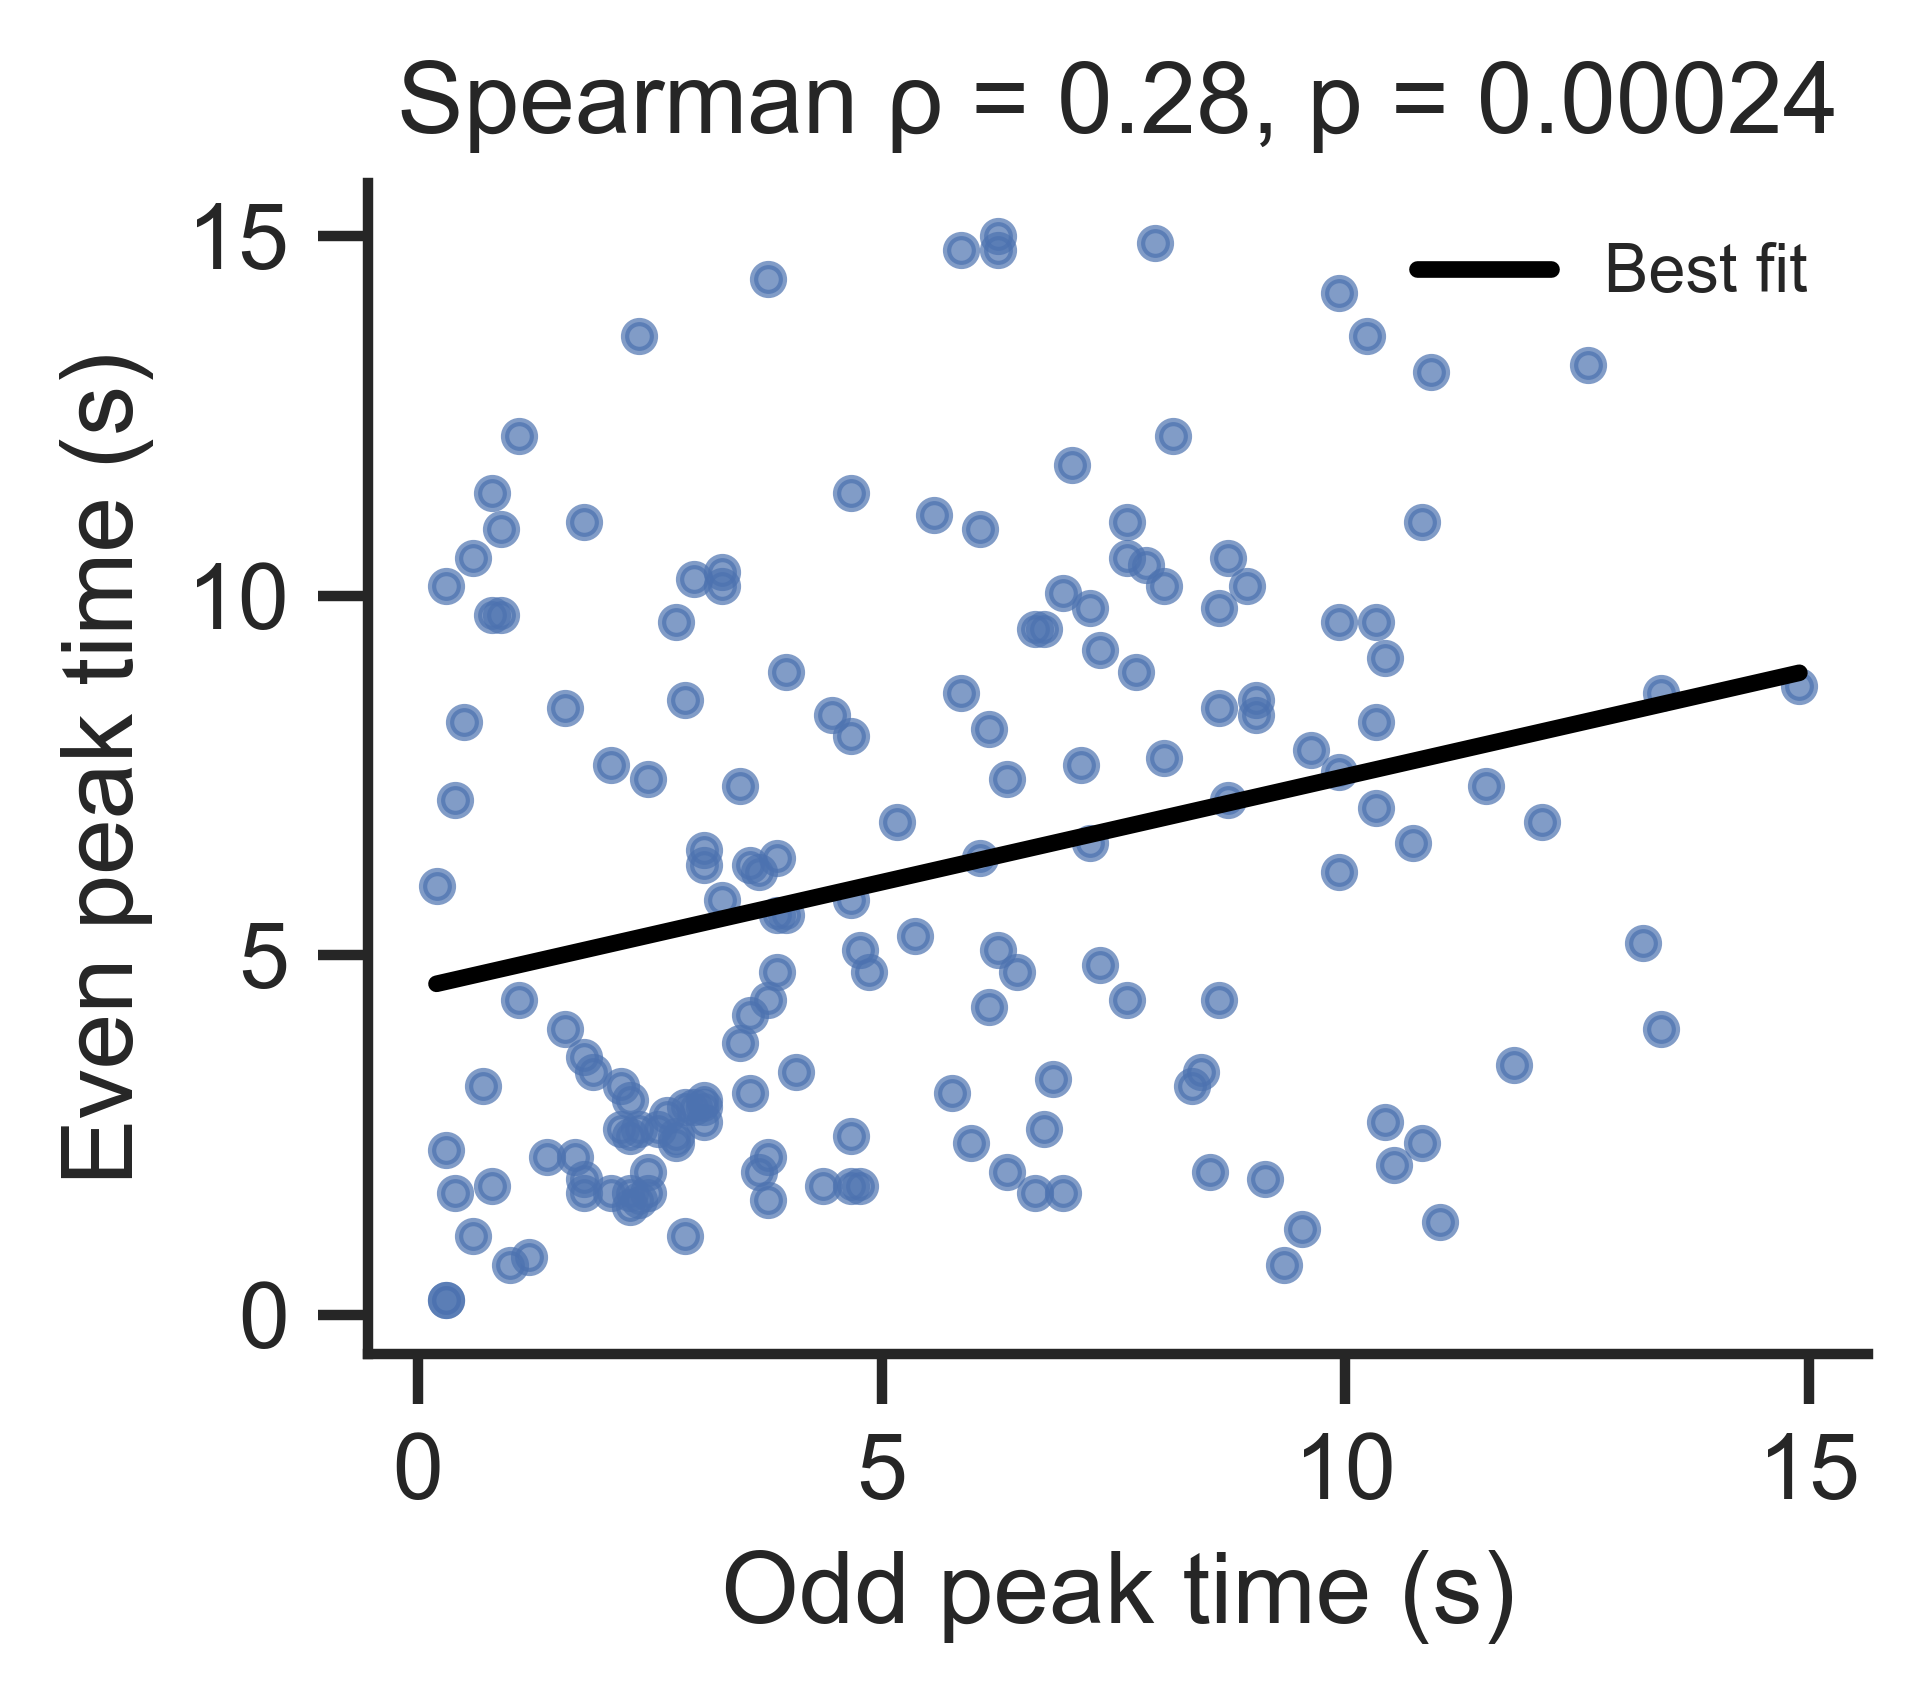

In [661]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

slope, intercept, r_val, p_val_lin, std_err = stats.linregress(odd_peaks_time, even_peaks_time)
x_line = np.linspace(min(odd_peaks_time), max(odd_peaks_time), 100)
y_line = slope * x_line + intercept

plt.figure(figsize=(3.5, 3), dpi=600)
plt.scatter(odd_peaks_time, even_peaks_time, s=12, alpha=0.7)
plt.plot(x_line, y_line, color='black', lw=2, label='Best fit')

plt.xlabel("Odd peak time (s)")
plt.ylabel("Even peak time (s)")
plt.title(f"Spearman ρ = {rho:.2f}, p = {pval:.2g}")
sns.despine()
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()

plt.savefig("/Users/suthardr/Desktop/siria_2p_poster_figs/crossvalled/neurons_shock_crossvalled_corr.svg")

plt.show()

In [637]:
slope

np.float64(0.5183093633343356)